# Geometry — part 3 of 5

This notebook was automatically split from a larger notebook.

Ambient real dimension: 64
Sampled states: 12000
Kept states: 10800
Intrinsic rank mean/median: 23.987 / 24.000
Participation ratio mean/median: 21.258 / 21.811
Rank saturation ratio mean/median: 0.886 / 0.909


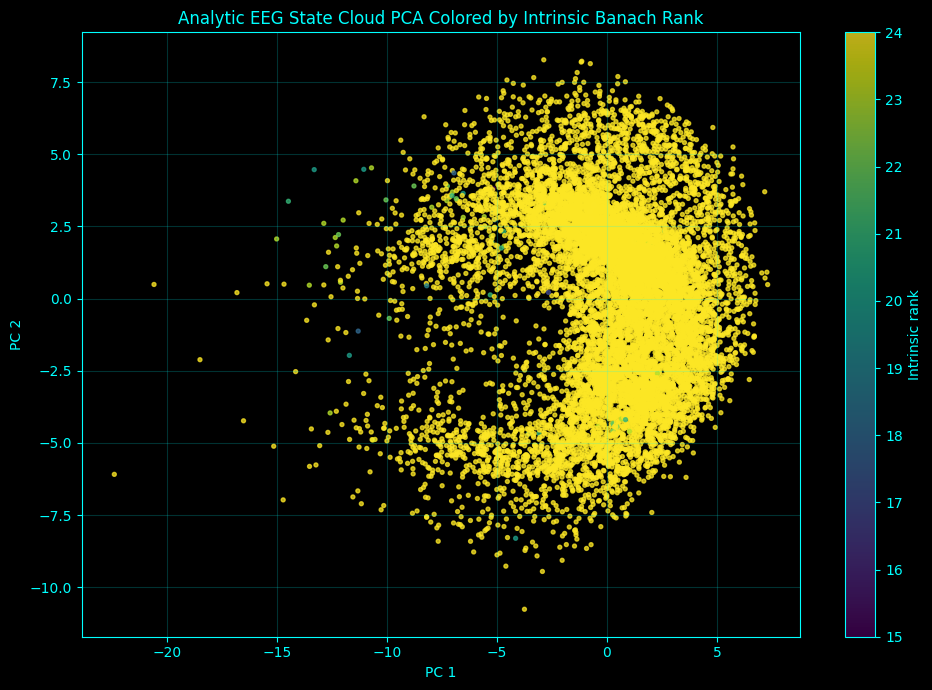

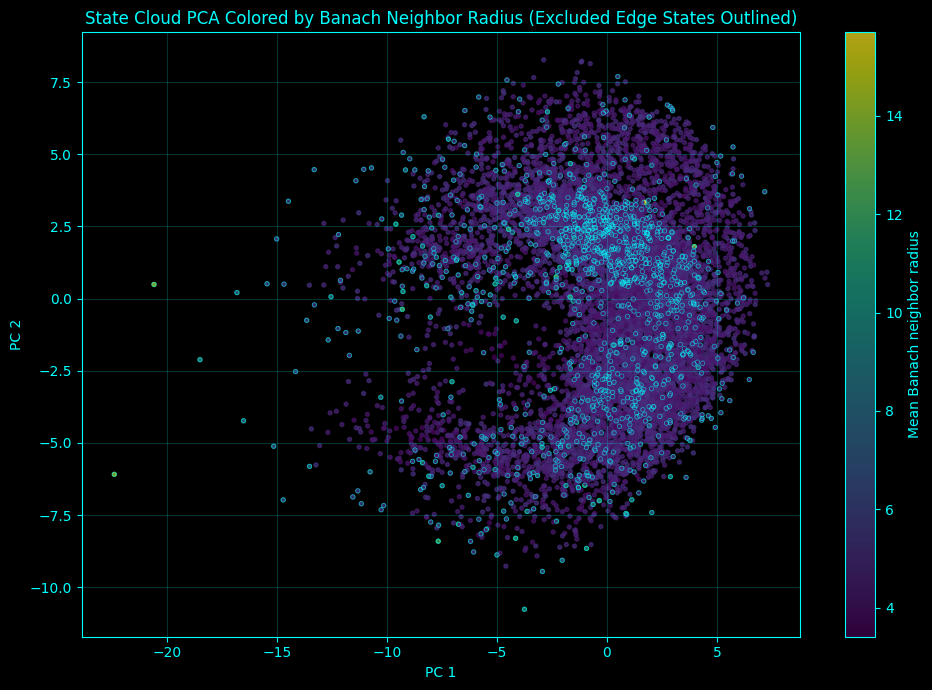

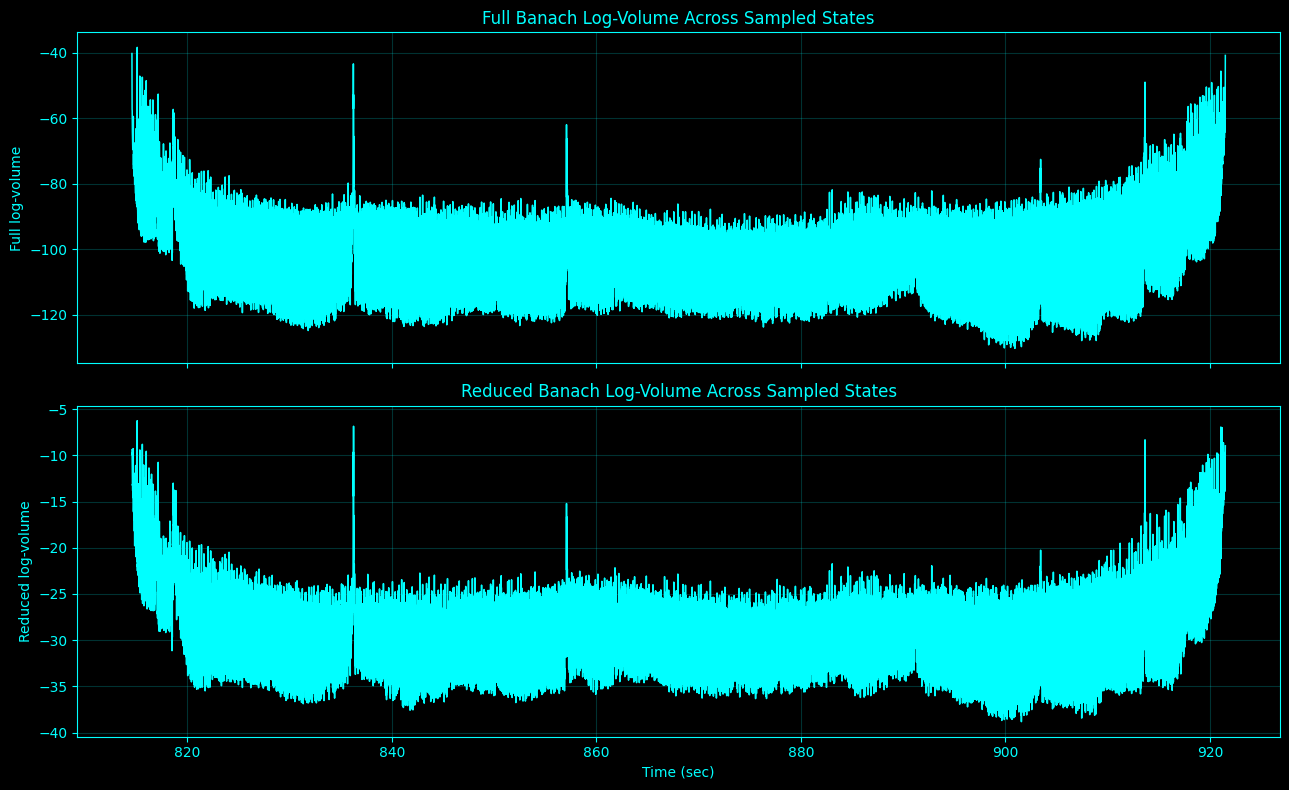

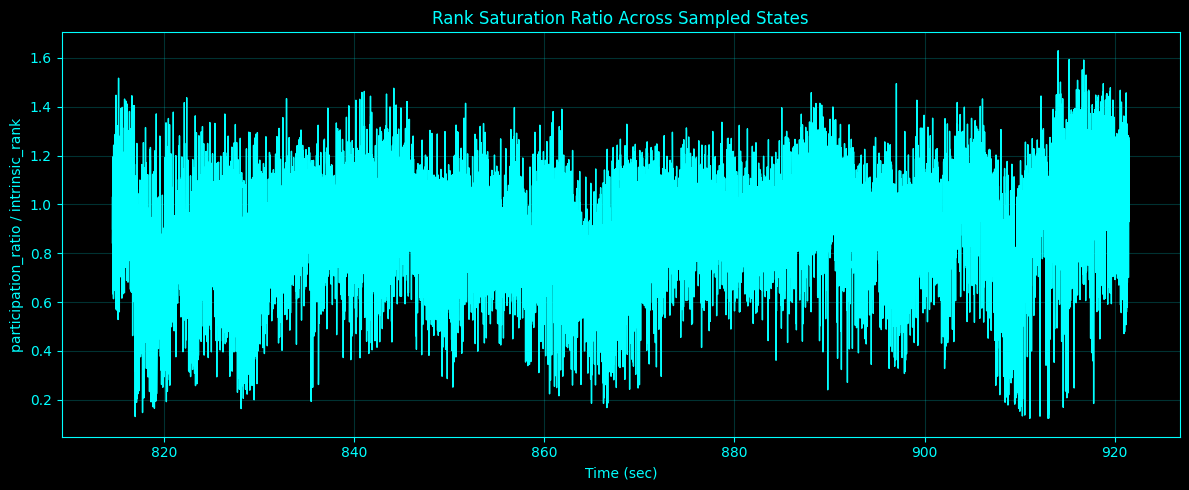

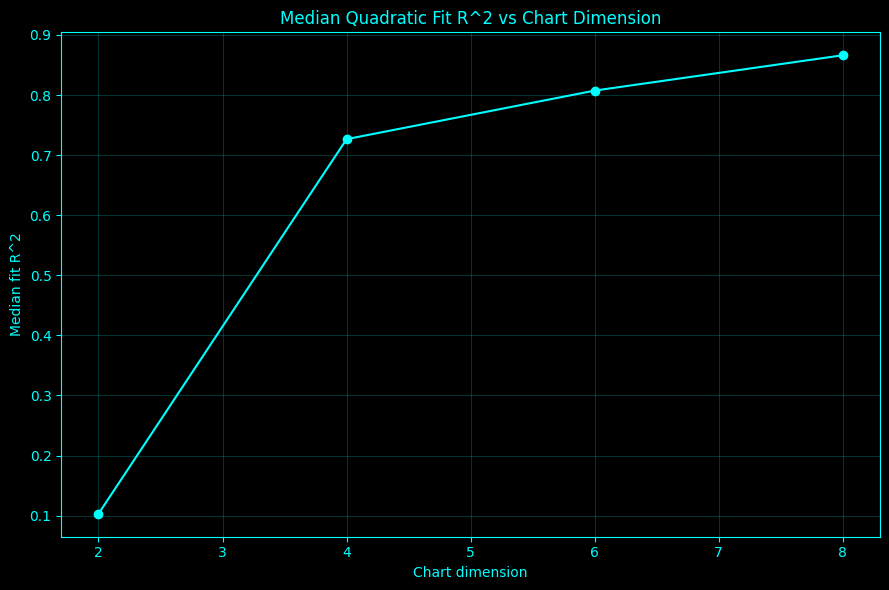

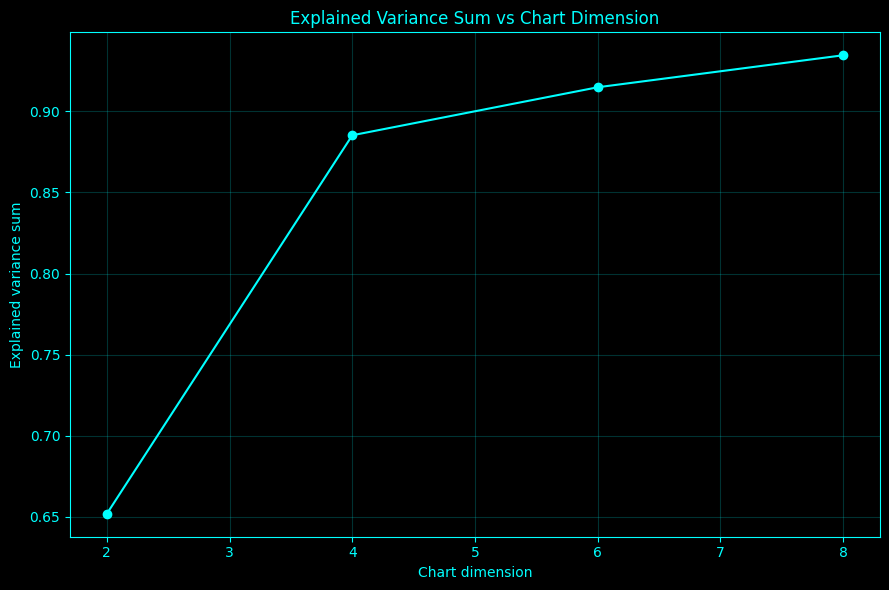

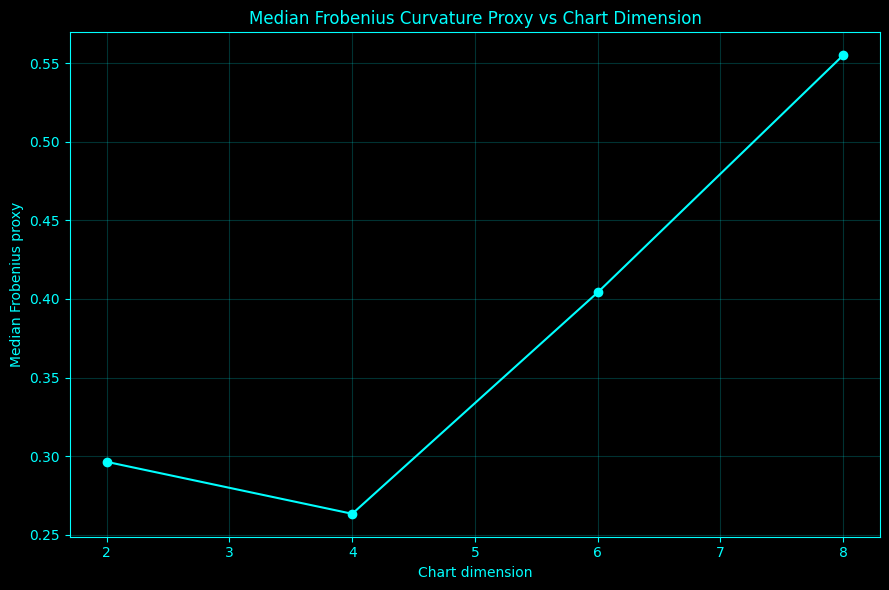

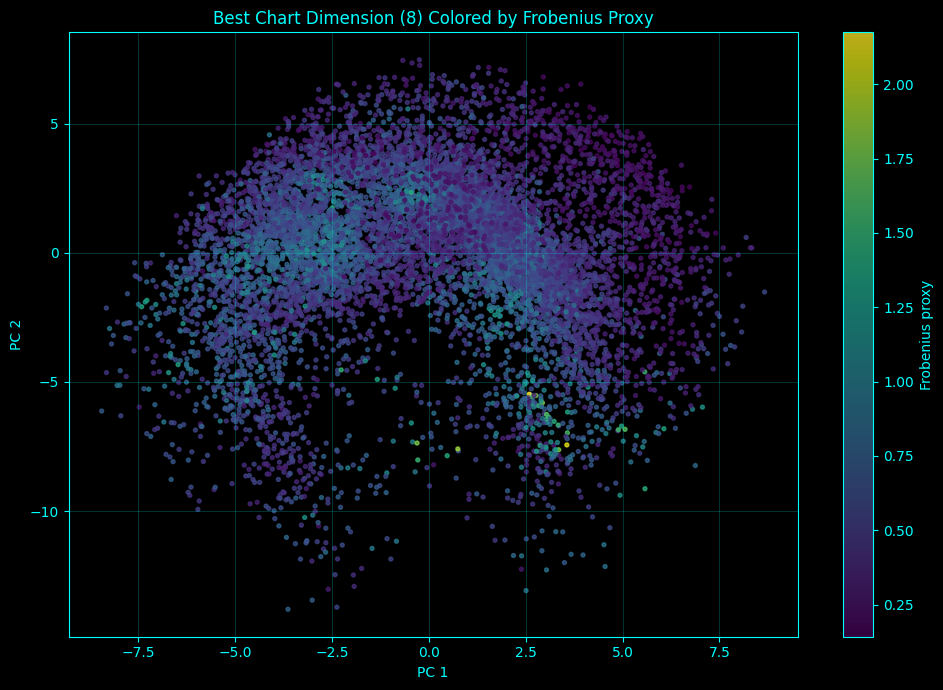

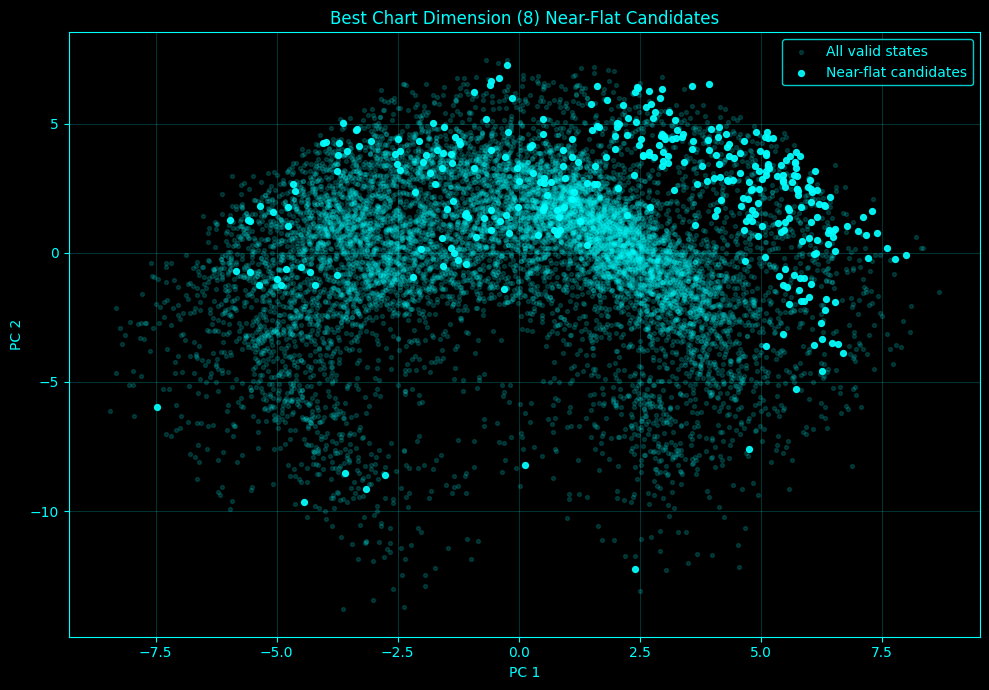


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/chart_dimension_sweep_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/best_chart_dim_8_per_state.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/next_step_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/plots

Saved plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/plots/pca_intrinsic_banach_rank.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/plots/pca_banach_neighbor_radius_density_filter.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/plots/full_vs_reduced_banach_logvol_over_time.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/banach_chart_dimension_sweep/plots/rank_saturation_ratio_over_time.png
/home/a/projects/

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "banach_chart_dimension_sweep")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

max_state_points = 12000

# Local geometry
k_metric_neighbors = 80
scale_reg = 1e-6
banach_p = 4.0
scale_method = "mad"

# IMPORTANT: uncap the intrinsic rank
intrinsic_energy_threshold = 0.90
min_intrinsic_rank = 2
max_intrinsic_rank = 24   # <- was 8; now let the data speak

# Density filtering
density_keep_quantile = 0.90

# Chart-fit sweep
chart_dims_to_test = [2, 4, 6, 8]
k_curvature_neighbors = 140
ridge_lambda = 1e-6

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def pca_d(X, d):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:d]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def normalized_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    return float(H / (np.log(len(p) + eps) + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def choose_intrinsic_rank(eigvals_desc, energy_threshold=0.90, min_rank=2, max_rank=24):
    eigvals_desc = np.asarray(eigvals_desc, dtype=float)
    total = np.sum(eigvals_desc)
    if total <= 0:
        return min_rank
    cume = np.cumsum(eigvals_desc) / total
    r = int(np.searchsorted(cume, energy_threshold) + 1)
    r = max(min_rank, r)
    r = min(max_rank, r, len(eigvals_desc))
    return r

def local_coordinate_scales(X_local, reg=1e-6, method="mad"):
    X_local = np.asarray(X_local, dtype=float)
    if method == "mad":
        ctr = np.median(X_local, axis=0, keepdims=True)
        scales = 1.4826 * np.median(np.abs(X_local - ctr), axis=0)
    elif method == "rms":
        ctr = np.mean(X_local, axis=0, keepdims=True)
        scales = np.sqrt(np.mean((X_local - ctr) ** 2, axis=0))
    else:
        raise ValueError("method must be 'mad' or 'rms'")
    return np.maximum(scales, reg)

def weighted_lp_norm(V, scales, p=4.0):
    V = np.asarray(V, dtype=float)
    scales = np.asarray(scales, dtype=float)
    if V.ndim == 1:
        V = V[None, :]
    return np.power(np.sum(np.abs(V / (scales + eps)) ** p, axis=1) + eps, 1.0 / p)

def local_banach_summary(X_local, p=4.0, reg=1e-6, method="mad",
                         energy_threshold=0.90, min_rank=2, max_rank=24):
    scales = local_coordinate_scales(X_local, reg=reg, method=method)
    scales_desc = np.sort(scales)[::-1]
    scale_energy_desc = np.sort(scales ** p)[::-1]

    intrinsic_rank = choose_intrinsic_rank(
        scale_energy_desc,
        energy_threshold=energy_threshold,
        min_rank=min_rank,
        max_rank=max_rank,
    )

    return {
        "scales": scales,
        "intrinsic_rank": intrinsic_rank,
        "full_logvol_B": float(np.sum(np.log(scales_desc + eps))),
        "reduced_logvol_B": float(np.sum(np.log(scales_desc[:intrinsic_rank] + eps))),
        "scale_entropy_B": normalized_entropy(scale_energy_desc),
        "participation_ratio_B": participation_ratio(scale_energy_desc),
    }

def local_transition_distortion(X, local_scales_array, neighbor_idx, p=4.0):
    X = np.asarray(X, dtype=float)
    n = len(X)
    out = np.full(n, np.nan, dtype=float)
    for i in range(n):
        idx = np.atleast_1d(neighbor_idx[i])
        idx = idx[idx != i]
        if len(idx) == 0:
            continue
        vals = []
        for j in idx:
            v = X[j] - X[i]
            d_i = weighted_lp_norm(v, local_scales_array[i], p=p)[0]
            d_j = weighted_lp_norm(-v, local_scales_array[j], p=p)[0]
            vals.append(np.abs(d_i - d_j) / (0.5 * (d_i + d_j) + eps))
        out[i] = float(np.mean(vals))
    return out

def build_quadratic_design(X):
    """
    Design: [1, x_i, x_i x_j (i<=j)]
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    cols = [np.ones(n)]
    for i in range(d):
        cols.append(X[:, i])
    quad_pairs = []
    for i in range(d):
        for j in range(i, d):
            cols.append(X[:, i] * X[:, j])
            quad_pairs.append((i, j))
    A = np.column_stack(cols)
    return A, quad_pairs

def coef_to_hessian(coef, d):
    H = np.zeros((d, d), dtype=float)
    q = 1 + d
    for i in range(d):
        for j in range(i, d):
            c = coef[q]
            if i == j:
                H[i, i] = 2.0 * c
            else:
                H[i, j] = c
                H[j, i] = c
            q += 1
    return H

def local_quadratic_scalar_proxy_nd(Xd, values, k=140, ridge=1e-6):
    Xd = np.asarray(Xd, dtype=float)
    values = np.asarray(values, dtype=float)
    n, d = Xd.shape

    n_params = 1 + d + d * (d + 1) // 2
    min_neighbors = max(2 * n_params, 20)

    tree = cKDTree(Xd)
    _, nbr_idx = tree.query(Xd, k=min(k + 1, n))

    fit_r2 = np.full(n, np.nan)
    frob = np.full(n, np.nan)
    lap = np.full(n, np.nan)
    detv = np.full(n, np.nan)
    eig_min = np.full(n, np.nan)
    eig_max = np.full(n, np.nan)
    local_radius = np.full(n, np.nan)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]
        idx = idx[np.isfinite(values[idx])]
        if len(idx) < min_neighbors:
            continue

        Xi = Xd[idx] - Xd[i]
        yi = values[idx]

        A, _ = build_quadratic_design(Xi)
        ATA = A.T @ A + ridge * np.eye(A.shape[1])
        ATy = A.T @ yi

        try:
            coef = np.linalg.solve(ATA, ATy)
        except np.linalg.LinAlgError:
            continue

        yhat = A @ coef
        ss_res = np.sum((yi - yhat) ** 2)
        ss_tot = np.sum((yi - np.mean(yi)) ** 2)
        fit_r2[i] = 1.0 - ss_res / (ss_tot + eps)

        H = coef_to_hessian(coef, d)
        w = np.linalg.eigvalsh(H)

        frob[i] = np.linalg.norm(H, ord="fro")
        lap[i] = np.trace(H)
        detv[i] = np.linalg.det(H)
        eig_min[i] = w[0]
        eig_max[i] = w[-1]
        local_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

    return pd.DataFrame({
        "fit_r2": fit_r2,
        "frobenius_proxy": frob,
        "laplacian_proxy": lap,
        "det_proxy": detv,
        "eig_min": eig_min,
        "eig_max": eig_max,
        "chart_neighbor_radius": local_radius,
    })

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

# -------------------------------------------------------
# LOAD EEG AND BUILD STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, 32)
EEG_segment = EEG_data[start_index:end_index, :]
analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(len(analytic_EEG), max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
T_sample = start_time + sample_idx * dt
X_real = realify_complex_states(Z_sample)

# PCA for visualization on all states
pca_xy_all, pca2_eigs_all, _ = pca_d(X_real, 2)

# -------------------------------------------------------
# BUILD LOCAL BANACH SUMMARIES
# -------------------------------------------------------
tree = cKDTree(X_real)
_, nbr_idx = tree.query(X_real, k=min(k_metric_neighbors + 1, len(X_real)))

rows = []
local_scales = []

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        continue

    V_local = X_real[idx] - X_real[i]
    s = local_banach_summary(
        V_local,
        p=banach_p,
        reg=scale_reg,
        method=scale_method,
        energy_threshold=intrinsic_energy_threshold,
        min_rank=min_intrinsic_rank,
        max_rank=max_intrinsic_rank,
    )
    local_scales.append(s["scales"])

    local_norms = weighted_lp_norm(V_local, s["scales"], p=banach_p)

    rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "intrinsic_rank": int(s["intrinsic_rank"]),
        "full_logvol_B": s["full_logvol_B"],
        "reduced_logvol_B": s["reduced_logvol_B"],
        "scale_entropy_B": s["scale_entropy_B"],
        "participation_ratio_B": s["participation_ratio_B"],
        "mean_banach_neighbor_radius": float(np.mean(local_norms)),
    })

state_df = pd.DataFrame(rows)
local_scales = np.vstack(local_scales)

state_df["transition_distortion_B"] = local_transition_distortion(
    X_real, local_scales, nbr_idx, p=banach_p
)

ambient_dim = X_real.shape[1]
state_df["full_logvol_per_dim_B"] = state_df["full_logvol_B"] / ambient_dim
state_df["reduced_logvol_per_rank_B"] = state_df["reduced_logvol_B"] / np.maximum(state_df["intrinsic_rank"], 1)
state_df["rank_saturation_ratio_B"] = state_df["participation_ratio_B"] / np.maximum(state_df["intrinsic_rank"], 1)

# Density filter on Banach radius
radius_threshold = float(np.quantile(state_df["mean_banach_neighbor_radius"], density_keep_quantile))
density_mask = state_df["mean_banach_neighbor_radius"].values <= radius_threshold
state_df["density_kept"] = density_mask.astype(int)

kept_df = state_df.loc[density_mask].copy().reset_index(drop=True)
X_kept = X_real[density_mask]
pca_xy_kept = pca_xy_all[density_mask]

print(f"Ambient real dimension: {ambient_dim}")
print(f"Sampled states: {len(state_df)}")
print(f"Kept states: {len(kept_df)}")
print(f"Intrinsic rank mean/median: {state_df['intrinsic_rank'].mean():.3f} / {state_df['intrinsic_rank'].median():.3f}")
print(f"Participation ratio mean/median: {state_df['participation_ratio_B'].mean():.3f} / {state_df['participation_ratio_B'].median():.3f}")
print(f"Rank saturation ratio mean/median: {state_df['rank_saturation_ratio_B'].mean():.3f} / {state_df['rank_saturation_ratio_B'].median():.3f}")

# -------------------------------------------------------
# CHART-DIMENSION SWEEP
# -------------------------------------------------------
sweep_rows = []
best_dim = None
best_score = -np.inf
per_dim_outputs = {}
near_flat_by_dim = {}

for d in chart_dims_to_test:
    Yd, eigs, V = pca_d(X_kept, d)

    proxy_df = local_quadratic_scalar_proxy_nd(
        Yd,
        kept_df["reduced_logvol_per_rank_B"].values,
        k=k_curvature_neighbors,
        ridge=ridge_lambda,
    )

    out_df = pd.concat(
        [
            kept_df.reset_index(drop=True),
            pd.DataFrame({f"pc{i+1}": Yd[:, i] for i in range(d)}),
            proxy_df.reset_index(drop=True),
        ],
        axis=1
    )

    valid = out_df[np.isfinite(out_df["frobenius_proxy"])].copy()
    valid["abs_laplacian_proxy"] = np.abs(valid["laplacian_proxy"])

    frob_q = np.quantile(valid["frobenius_proxy"], 0.10) if len(valid) else np.nan
    lap_q = np.quantile(valid["abs_laplacian_proxy"], 0.10) if len(valid) else np.nan
    near_flat = valid[
        (valid["frobenius_proxy"] <= frob_q) &
        (valid["abs_laplacian_proxy"] <= lap_q)
    ].copy() if len(valid) else valid.copy()

    full_cov_eigs = np.linalg.eigvalsh(np.cov(X_kept.T))
    explained_var = float(np.sum(eigs) / np.sum(np.maximum(full_cov_eigs, eps)))

    row = {
        "chart_dim": d,
        "n_valid_fit": int(len(valid)),
        "median_fit_r2": safe_median(valid["fit_r2"].values),
        "mean_fit_r2": safe_mean(valid["fit_r2"].values),
        "median_frobenius_proxy": safe_median(valid["frobenius_proxy"].values),
        "mean_frobenius_proxy": safe_mean(valid["frobenius_proxy"].values),
        "median_abs_laplacian_proxy": safe_median(valid["abs_laplacian_proxy"].values),
        "mean_abs_laplacian_proxy": safe_mean(valid["abs_laplacian_proxy"].values),
        "near_flat_fraction": float(len(near_flat) / max(len(valid), 1)),
        "explained_variance_sum": explained_var,
    }
    sweep_rows.append(row)
    per_dim_outputs[d] = out_df
    near_flat_by_dim[d] = near_flat

    if np.isfinite(row["median_fit_r2"]) and row["median_fit_r2"] > best_score:
        best_score = row["median_fit_r2"]
        best_dim = d

sweep_df = pd.DataFrame(sweep_rows).sort_values("chart_dim").reset_index(drop=True)
sweep_csv = os.path.join(out_dir, "chart_dimension_sweep_summary.csv")
sweep_df.to_csv(sweep_csv, index=False)

best_csv = os.path.join(out_dir, f"best_chart_dim_{best_dim}_per_state.csv")
per_dim_outputs[best_dim].to_csv(best_csv, index=False)

# -------------------------------------------------------
# SUMMARY TXT
# -------------------------------------------------------
summary_path = os.path.join(out_dir, "next_step_summary.txt")
with open(summary_path, "w") as f:
    f.write("Banach Next-Step Sweep: Rank-Uncapped + Dimension-Normalized + Chart-Dimension Test\n")
    f.write("===============================================================================\n\n")
    f.write(f"Ambient real dimension: {ambient_dim}\n")
    f.write(f"Sampled states: {len(state_df)}\n")
    f.write(f"Kept states: {len(kept_df)}\n")
    f.write(f"Mean intrinsic rank: {state_df['intrinsic_rank'].mean():.6f}\n")
    f.write(f"Median intrinsic rank: {state_df['intrinsic_rank'].median():.6f}\n")
    f.write(f"Mean participation ratio: {state_df['participation_ratio_B'].mean():.6f}\n")
    f.write(f"Median participation ratio: {state_df['participation_ratio_B'].median():.6f}\n")
    f.write(f"Mean rank saturation ratio: {state_df['rank_saturation_ratio_B'].mean():.6f}\n")
    f.write(f"Median rank saturation ratio: {state_df['rank_saturation_ratio_B'].median():.6f}\n")
    f.write(f"Best chart dimension by median fit R^2: {best_dim}\n\n")
    f.write(sweep_df.to_string(index=False))
    f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) PCA chart colored by intrinsic rank
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy_all[:, 0],
    pca_xy_all[:, 1],
    c=state_df["intrinsic_rank"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Intrinsic Banach Rank")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Intrinsic rank")

plot1_path = os.path.join(plots_dir, "pca_intrinsic_banach_rank.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA chart colored by Banach neighbor radius with excluded states outlined
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy_all[:, 0],
    pca_xy_all[:, 1],
    c=state_df["mean_banach_neighbor_radius"].values,
    s=8,
    alpha=0.70
)

excluded = ~density_mask
if np.any(excluded):
    ax.scatter(
        pca_xy_all[excluded, 0],
        pca_xy_all[excluded, 1],
        s=10,
        facecolors="none",
        edgecolors=ACCENT,
        alpha=0.65,
        linewidths=0.5
    )

ax.set_title("State Cloud PCA Colored by Banach Neighbor Radius (Excluded Edge States Outlined)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Mean Banach neighbor radius")

plot2_path = os.path.join(plots_dir, "pca_banach_neighbor_radius_density_filter.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Full vs reduced log-volume across sampled states
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(state_df["time_sec"].values, state_df["full_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Full Banach Log-Volume Across Sampled States")
ax1.set_ylabel("Full log-volume")

ax2.plot(state_df["time_sec"].values, state_df["reduced_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax2.set_title("Reduced Banach Log-Volume Across Sampled States")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Reduced log-volume")

plot3_path = os.path.join(plots_dir, "full_vs_reduced_banach_logvol_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Rank saturation ratio over time
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    state_df["time_sec"].values,
    state_df["rank_saturation_ratio_B"].values,
    color=ACCENT,
    linewidth=1.0
)
ax.set_title("Rank Saturation Ratio Across Sampled States")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("participation_ratio / intrinsic_rank")

plot4_path = os.path.join(plots_dir, "rank_saturation_ratio_over_time.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Median fit R^2 vs chart dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    sweep_df["chart_dim"],
    sweep_df["median_fit_r2"],
    marker="o",
    linewidth=1.5,
    color=ACCENT
)
ax.set_title("Median Quadratic Fit R^2 vs Chart Dimension")
ax.set_xlabel("Chart dimension")
ax.set_ylabel("Median fit R^2")

plot5_path = os.path.join(plots_dir, "median_fit_r2_vs_chart_dim.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Explained variance vs chart dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    sweep_df["chart_dim"],
    sweep_df["explained_variance_sum"],
    marker="o",
    linewidth=1.5,
    color=ACCENT
)
ax.set_title("Explained Variance Sum vs Chart Dimension")
ax.set_xlabel("Chart dimension")
ax.set_ylabel("Explained variance sum")

plot6_path = os.path.join(plots_dir, "explained_variance_vs_chart_dim.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Median Frobenius proxy vs chart dimension
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    sweep_df["chart_dim"],
    sweep_df["median_frobenius_proxy"],
    marker="o",
    linewidth=1.5,
    color=ACCENT
)
ax.set_title("Median Frobenius Curvature Proxy vs Chart Dimension")
ax.set_xlabel("Chart dimension")
ax.set_ylabel("Median Frobenius proxy")

plot7_path = os.path.join(plots_dir, "median_frobenius_vs_chart_dim.png")
plt.tight_layout()
plt.savefig(plot7_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 8) Best-dimension PC1/PC2 chart colored by Frobenius proxy
best_df = per_dim_outputs[best_dim].copy()
best_valid = best_df[np.isfinite(best_df["frobenius_proxy"])].copy()

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    best_valid["pc1"].values,
    best_valid["pc2"].values,
    c=best_valid["frobenius_proxy"].values,
    s=8,
    alpha=0.75
)
ax.set_title(f"Best Chart Dimension ({best_dim}) Colored by Frobenius Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Frobenius proxy")

plot8_path = os.path.join(plots_dir, f"best_dim_{best_dim}_frobenius_proxy_pca.png")
plt.tight_layout()
plt.savefig(plot8_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 9) Best-dimension near-flat candidates highlighted
best_near_flat = near_flat_by_dim[best_dim].copy()

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    best_valid["pc1"].values,
    best_valid["pc2"].values,
    s=8,
    alpha=0.16,
    color=ACCENT,
    label="All valid states"
)

if len(best_near_flat) > 0:
    ax.scatter(
        best_near_flat["pc1"].values,
        best_near_flat["pc2"].values,
        s=18,
        alpha=0.90,
        color=ACCENT,
        label="Near-flat candidates"
    )

ax.set_title(f"Best Chart Dimension ({best_dim}) Near-Flat Candidates")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()

plot9_path = os.path.join(plots_dir, f"best_dim_{best_dim}_near_flat_candidates.png")
plt.tight_layout()
plt.savefig(plot9_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved:")
print(sweep_csv)
print(best_csv)
print(summary_path)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
print(plot5_path)
print(plot6_path)
print(plot7_path)
print(plot8_path)
print(plot9_path)

print("\nSweep summary:")
print(sweep_df.to_string(index=False))

if best_score < 0.25:
    print("\nInterpretation: the 2D bottleneck was not the only issue.")
    print("Quadratic curvature on PCA charts is still weak; switch next to diffusion/graph geometry.")
elif best_score < 0.40:
    print("\nInterpretation: higher-dimensional charts help somewhat.")
    print("Keep the Banach model, but move from global PCA charts to local PCA charts next.")
else:
    print("\nInterpretation: higher-dimensional charts materially improve fit.")
    print("Proceed with local-chart Banach curvature and bootstrap stability testing.")

Ambient real dimension: 64
Sampled states: 12000
Kept states: 10800
Intrinsic rank mean/median: 30.384 / 31.000
Participation ratio mean/median: 21.274 / 21.819
Rank saturation ratio mean/median: 0.695 / 0.716
Valid local fits: 10800
Candidate bootstrap targets: 1461


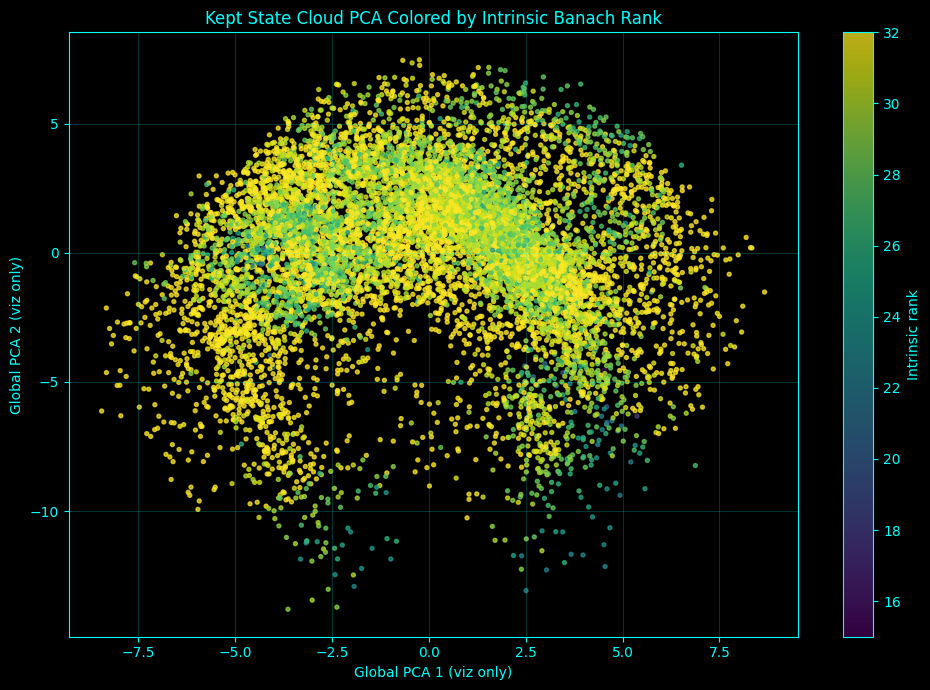

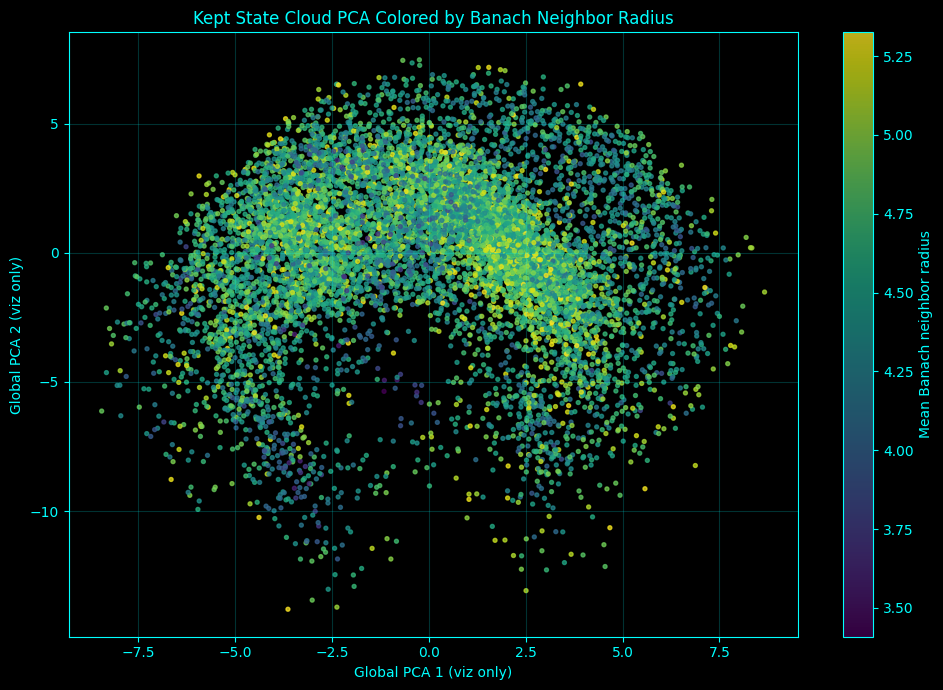

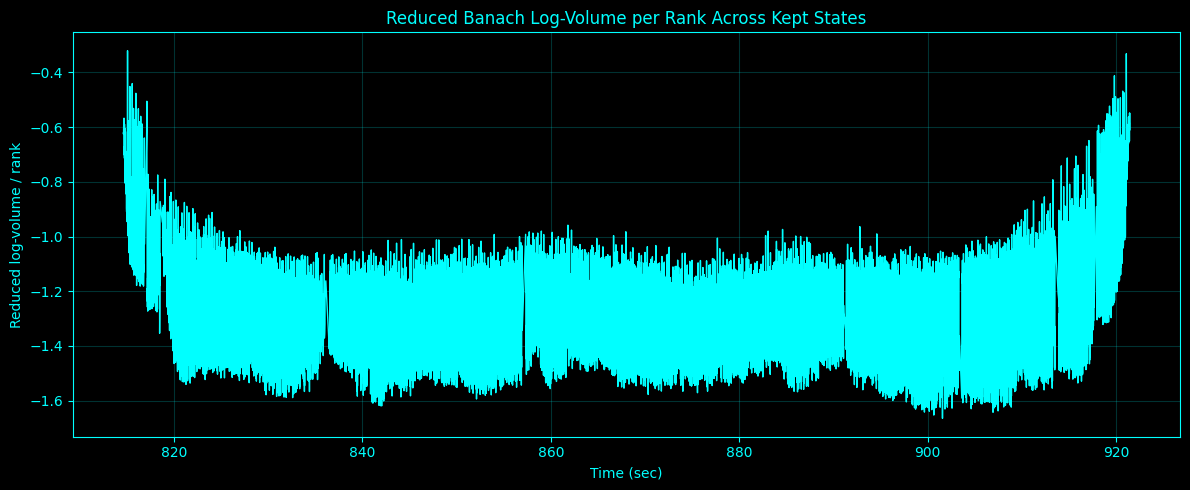

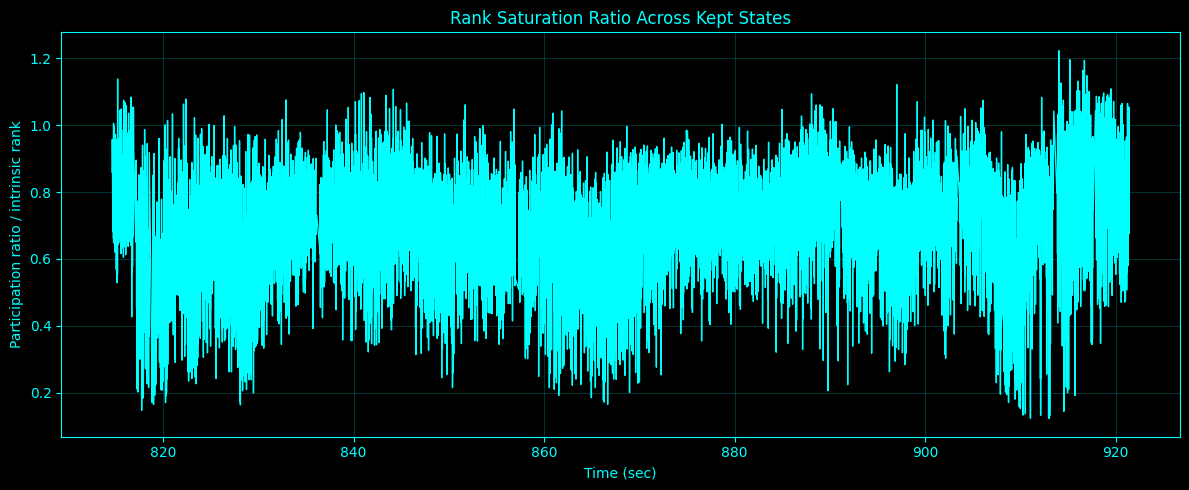

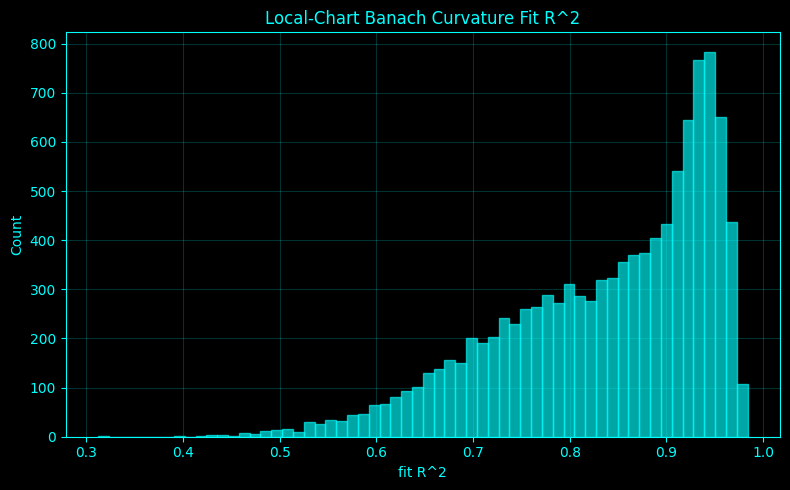

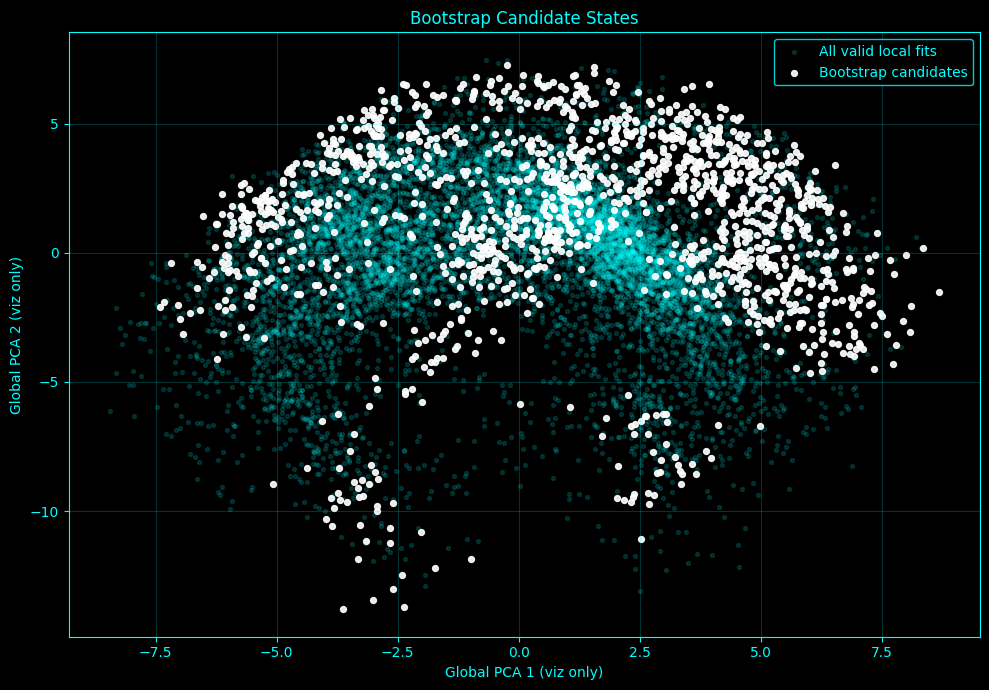

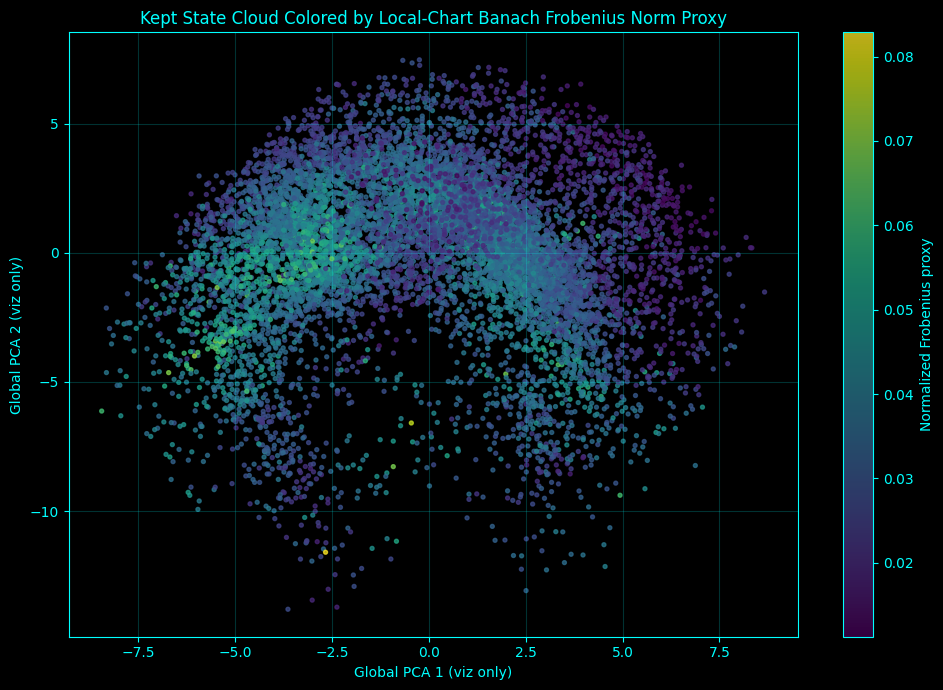

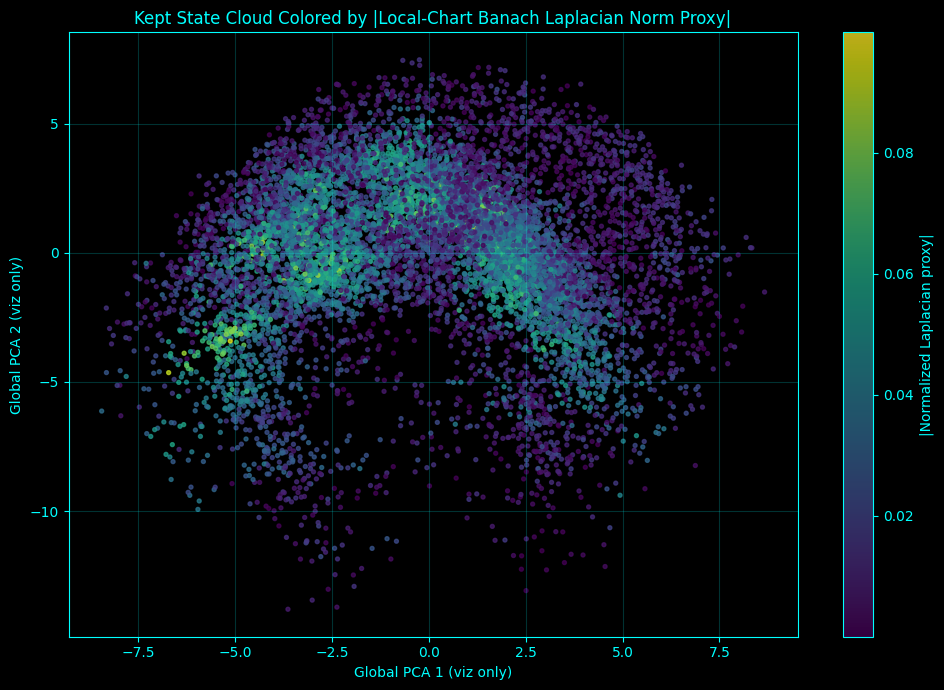

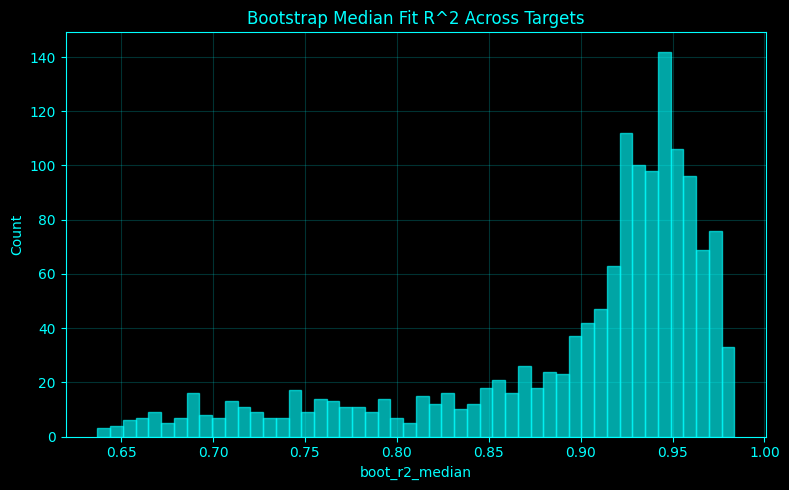

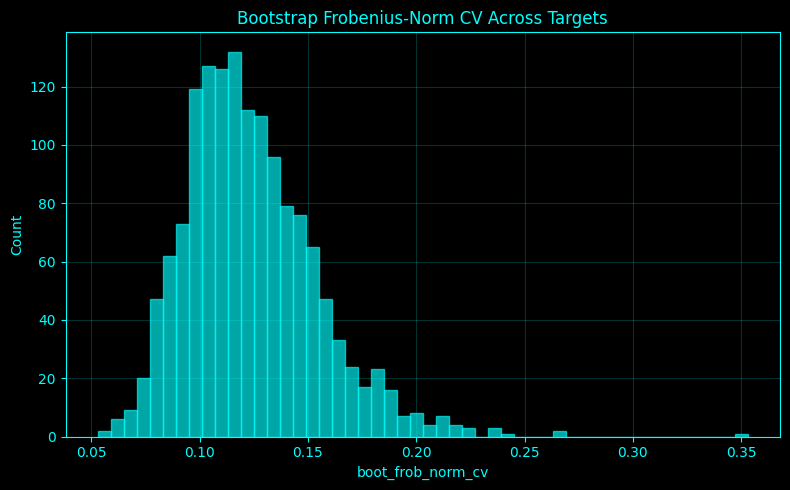

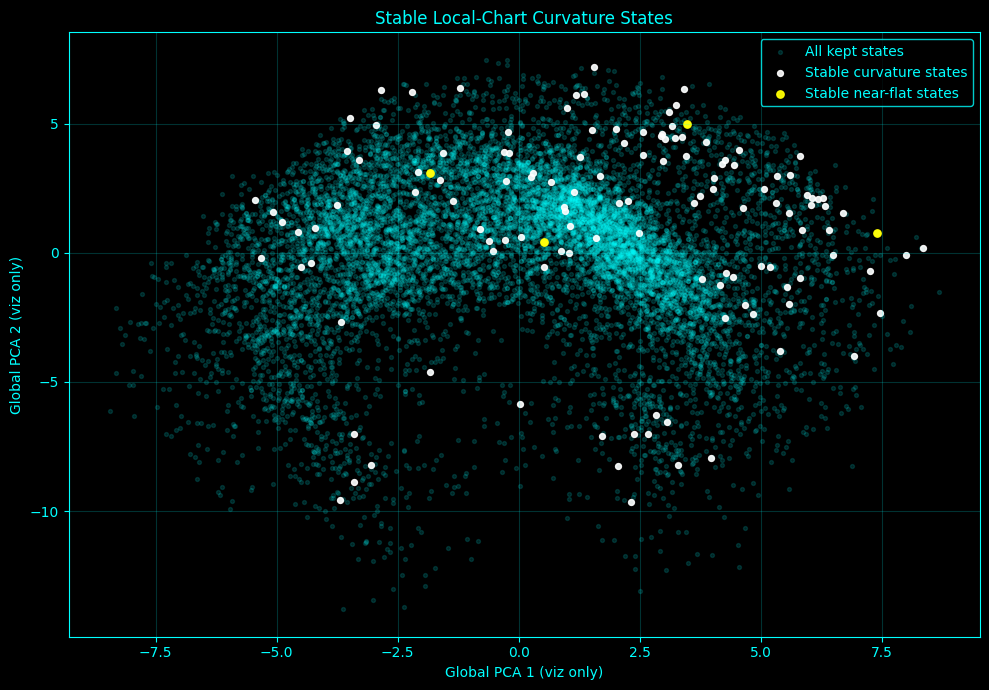

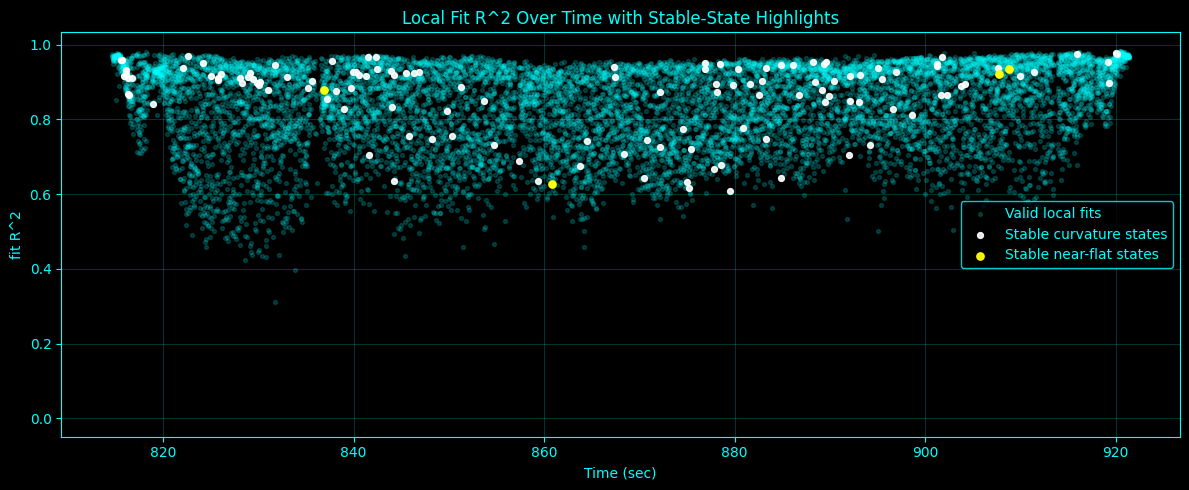


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/banach_state_summary_v2.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/local_chart_curvature_all_states.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/local_chart_bootstrap_targets.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/stable_local_curvature_states.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/stable_near_flat_local_curvature_states.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/local_banach_curvature_bootstrap_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/plots

Saved plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/local_banach_curvature_bootstrap_v1/plots/

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

max_state_points = 12000
rng_seed = 42
rng = np.random.default_rng(rng_seed)

# Local Banach geometry
k_metric_neighbors = 80
scale_reg = 1e-6
banach_p = 4.0
scale_method = "mad"

# Increase cap again; your rank is still brushing 24
intrinsic_energy_threshold = 0.90
min_intrinsic_rank = 2
max_intrinsic_rank = 32

# Density filtering
density_keep_quantile = 0.90

# Local chart curvature
local_chart_dim = 8
k_local_chart_neighbors = 160
ridge_lambda = 1e-5

# Bootstrap stability
bootstrap_mode = "candidate_only"   # "candidate_only" or "all"
bootstrap_iters = 25
bootstrap_subsample_frac = 0.80

# Candidate shortlist thresholds
candidate_fit_r2_threshold = 0.60
candidate_frob_quantile = 0.25
candidate_abs_lap_quantile = 0.25

# Stable-candidate thresholds
stable_boot_r2_threshold = 0.60
stable_frob_cv_threshold = 0.25
stable_lap_sign_stability_threshold = 0.80
stable_signature_stability_threshold = 0.80

ACCENT = "cyan"
BG = "black"
eps = 1e-12
sign_eps = 1e-6
eig_eps = 1e-6

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def pca_d(X, d):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:d]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def normalized_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def choose_intrinsic_rank(eigvals_desc, energy_threshold=0.90, min_rank=2, max_rank=32):
    eigvals_desc = np.asarray(eigvals_desc, dtype=float)
    total = np.sum(eigvals_desc)
    if total <= 0:
        return min_rank
    cume = np.cumsum(eigvals_desc) / total
    r = int(np.searchsorted(cume, energy_threshold) + 1)
    r = max(min_rank, r)
    r = min(max_rank, r, len(eigvals_desc))
    return r

def local_coordinate_scales(X_local, reg=1e-6, method="mad"):
    X_local = np.asarray(X_local, dtype=float)

    if X_local.ndim != 2:
        raise ValueError(f"Expected 2D local offsets, got shape {X_local.shape}")
    if X_local.shape[0] == 0:
        raise ValueError("Empty local neighborhood")

    if method == "mad":
        ctr = np.median(X_local, axis=0, keepdims=True)
        scales = 1.4826 * np.median(np.abs(X_local - ctr), axis=0)
    elif method == "rms":
        ctr = np.mean(X_local, axis=0, keepdims=True)
        scales = np.sqrt(np.mean((X_local - ctr) ** 2, axis=0))
    else:
        raise ValueError("method must be 'mad' or 'rms'")

    return np.maximum(scales, reg)

def weighted_lp_norm(V, scales, p=4.0):
    V = np.asarray(V, dtype=float)
    scales = np.asarray(scales, dtype=float)
    if V.ndim == 1:
        V = V[None, :]
    return np.power(np.sum(np.abs(V / (scales + eps)) ** p, axis=1) + eps, 1.0 / p)

def local_banach_summary(
    X_local,
    p=4.0,
    reg=1e-6,
    method="mad",
    energy_threshold=0.90,
    min_rank=2,
    max_rank=32,
):
    scales = local_coordinate_scales(X_local, reg=reg, method=method)
    scales_desc = np.sort(scales)[::-1]
    scale_energy_desc = np.sort(scales ** p)[::-1]

    intrinsic_rank = choose_intrinsic_rank(
        scale_energy_desc,
        energy_threshold=energy_threshold,
        min_rank=min_rank,
        max_rank=max_rank,
    )

    full_logvol = float(np.sum(np.log(scales_desc + eps)))
    reduced_logvol = float(np.sum(np.log(scales_desc[:intrinsic_rank] + eps)))

    return {
        "scales": scales,
        "intrinsic_rank": intrinsic_rank,
        "full_logvol_B": full_logvol,
        "reduced_logvol_B": reduced_logvol,
        "scale_entropy_B": normalized_entropy(scale_energy_desc),
        "participation_ratio_B": participation_ratio(scale_energy_desc),
    }

def local_transition_distortion(X, local_scales_array, neighbor_idx, p=4.0):
    X = np.asarray(X, dtype=float)
    n = len(X)
    out = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(neighbor_idx[i])
        idx = idx[idx != i]
        if len(idx) == 0:
            continue

        vals = []
        for j in idx:
            v = X[j] - X[i]
            d_i = weighted_lp_norm(v, local_scales_array[i], p=p)[0]
            d_j = weighted_lp_norm(-v, local_scales_array[j], p=p)[0]
            vals.append(np.abs(d_i - d_j) / (0.5 * (d_i + d_j) + eps))

        out[i] = float(np.mean(vals))

    return out

def build_quadratic_design(X):
    """
    Design matrix:
        [1, x_1,...,x_d, x_i*x_j for i<=j]
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape

    cols = [np.ones(n)]
    for i in range(d):
        cols.append(X[:, i])

    for i in range(d):
        for j in range(i, d):
            cols.append(X[:, i] * X[:, j])

    return np.column_stack(cols)

def coef_to_hessian(coef, d):
    H = np.zeros((d, d), dtype=float)
    q = 1 + d
    for i in range(d):
        for j in range(i, d):
            c = coef[q]
            if i == j:
                H[i, i] = 2.0 * c
            else:
                H[i, j] = c
                H[j, i] = c
            q += 1
    return H

def min_neighbors_for_chart_dim(d):
    n_params = 1 + d + d * (d + 1) // 2
    return max(2 * n_params, 30)

def hessian_signature_counts(H, eig_eps=1e-6):
    w = np.linalg.eigvalsh(H)
    n_pos = int(np.sum(w > eig_eps))
    n_neg = int(np.sum(w < -eig_eps))
    n_zero = int(len(w) - n_pos - n_neg)
    return n_pos, n_neg, n_zero, w

def fit_local_quadratic_in_local_pca(X_offsets, y, chart_dim=8, ridge=1e-5):
    """
    X_offsets: (n_neighbors, ambient_dim) local offsets around center state
    y: scalar values on those neighbors
    """
    X_offsets = np.asarray(X_offsets, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(y)
    X_offsets = X_offsets[good]
    y = y[good]

    if len(X_offsets) == 0:
        return None

    d = min(chart_dim, X_offsets.shape[1], len(X_offsets) - 1)
    if d < 2:
        return None

    min_neighbors = min_neighbors_for_chart_dim(d)
    if len(X_offsets) < min_neighbors:
        return None

    # local PCA basis
    Xc = X_offsets - np.mean(X_offsets, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)

    try:
        w_cov, V = np.linalg.eigh(C)
    except np.linalg.LinAlgError:
        return None

    idx = np.argsort(w_cov)[::-1][:d]
    basis = V[:, idx]

    # use coordinates relative to the center state (not relative to neighborhood mean)
    Y = X_offsets @ basis

    A = build_quadratic_design(Y)
    ATA = A.T @ A + ridge * np.eye(A.shape[1], dtype=float)
    ATy = A.T @ y

    try:
        coef = np.linalg.solve(ATA, ATy)
    except np.linalg.LinAlgError:
        return None

    yhat = A @ coef
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    fit_r2 = 1.0 - ss_res / (ss_tot + eps)

    H = coef_to_hessian(coef, d)
    n_pos, n_neg, n_zero, eigvals = hessian_signature_counts(H, eig_eps=eig_eps)

    frob = float(np.linalg.norm(H, ord="fro"))
    lap = float(np.trace(H))
    detv = float(np.linalg.det(H))
    frob_norm = float(frob / np.sqrt(d * (d + 1) / 2.0))
    lap_norm = float(lap / d)

    return {
        "chart_dim_used": int(d),
        "fit_r2": float(fit_r2),
        "frobenius_proxy": frob,
        "laplacian_proxy": lap,
        "det_proxy": detv,
        "frobenius_norm_proxy": frob_norm,
        "laplacian_norm_proxy": lap_norm,
        "eig_min": float(eigvals[0]),
        "eig_max": float(eigvals[-1]),
        "n_pos_eigs": int(n_pos),
        "n_neg_eigs": int(n_neg),
        "n_zero_eigs": int(n_zero),
        "mean_chart_radius": float(np.mean(np.linalg.norm(Y, axis=1))),
    }

def modal_fraction(values):
    values = list(values)
    if len(values) == 0:
        return np.nan
    counts = pd.Series(values).value_counts(dropna=False)
    return float(counts.iloc[0] / len(values))

def sign_stability(signs):
    signs = np.asarray(signs, dtype=int)
    if len(signs) == 0:
        return np.nan
    return float(max(
        np.mean(signs > 0),
        np.mean(signs < 0),
        np.mean(signs == 0),
    ))

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

# -------------------------------------------------------
# LOAD EEG AND BUILD ANALYTIC STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(n_samples, max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
T_sample = time_sec[sample_idx]
X_real = realify_complex_states(Z_sample)

ambient_dim = X_real.shape[1]
print(f"Ambient real dimension: {ambient_dim}")

# -------------------------------------------------------
# BUILD LOCAL BANACH SUMMARY FIELD
# -------------------------------------------------------
tree_ambient = cKDTree(X_real)
_, nbr_idx = tree_ambient.query(X_real, k=min(k_metric_neighbors + 1, len(X_real)))

state_rows = []
local_scales_list = []

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        idx = np.atleast_1d(nbr_idx[i])

    V_local = X_real[idx] - X_real[i]

    summary = local_banach_summary(
        V_local,
        p=banach_p,
        reg=scale_reg,
        method=scale_method,
        energy_threshold=intrinsic_energy_threshold,
        min_rank=min_intrinsic_rank,
        max_rank=max_intrinsic_rank,
    )

    scales = summary["scales"]
    local_scales_list.append(scales)

    local_norms = weighted_lp_norm(V_local, scales, p=banach_p)

    state_rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "intrinsic_rank": int(summary["intrinsic_rank"]),
        "full_logvol_B": summary["full_logvol_B"],
        "reduced_logvol_B": summary["reduced_logvol_B"],
        "scale_entropy_B": summary["scale_entropy_B"],
        "participation_ratio_B": summary["participation_ratio_B"],
        "mean_banach_neighbor_radius": float(np.mean(local_norms)),
    })

state_df = pd.DataFrame(state_rows)
local_scales_array = np.vstack(local_scales_list)

state_df["transition_distortion_B"] = local_transition_distortion(
    X_real,
    local_scales_array,
    nbr_idx,
    p=banach_p,
)

state_df["full_logvol_per_dim_B"] = state_df["full_logvol_B"] / ambient_dim
state_df["reduced_logvol_per_rank_B"] = state_df["reduced_logvol_B"] / np.maximum(state_df["intrinsic_rank"], 1)
state_df["rank_saturation_ratio_B"] = state_df["participation_ratio_B"] / np.maximum(state_df["intrinsic_rank"], 1)

# -------------------------------------------------------
# DENSITY FILTER
# -------------------------------------------------------
radius_threshold = float(np.quantile(state_df["mean_banach_neighbor_radius"].values, density_keep_quantile))
density_mask = state_df["mean_banach_neighbor_radius"].values <= radius_threshold
state_df["density_kept"] = density_mask.astype(int)

kept_df = state_df.loc[density_mask].copy().reset_index(drop=True)
X_kept = X_real[density_mask]

print(f"Sampled states: {len(state_df)}")
print(f"Kept states: {len(kept_df)}")
print(f"Intrinsic rank mean/median: {kept_df['intrinsic_rank'].mean():.3f} / {kept_df['intrinsic_rank'].median():.3f}")
print(f"Participation ratio mean/median: {kept_df['participation_ratio_B'].mean():.3f} / {kept_df['participation_ratio_B'].median():.3f}")
print(f"Rank saturation ratio mean/median: {kept_df['rank_saturation_ratio_B'].mean():.3f} / {kept_df['rank_saturation_ratio_B'].median():.3f}")

# -------------------------------------------------------
# GLOBAL PCA-2 FOR VISUALIZATION ONLY
# -------------------------------------------------------
viz_xy, viz_eigs, _ = pca_d(X_kept, 2)

# -------------------------------------------------------
# LOCAL-CHART CURVATURE FIT ON ALL KEPT STATES
# -------------------------------------------------------
tree_kept = cKDTree(X_kept)
_, local_nbr_idx = tree_kept.query(X_kept, k=min(k_local_chart_neighbors + 1, len(X_kept)))

all_local_rows = []

for i in range(len(X_kept)):
    idx = np.atleast_1d(local_nbr_idx[i])
    idx = idx[idx != i]

    y_neighbors = kept_df["reduced_logvol_per_rank_B"].values[idx]
    X_offsets = X_kept[idx] - X_kept[i]

    fit = fit_local_quadratic_in_local_pca(
        X_offsets,
        y_neighbors,
        chart_dim=local_chart_dim,
        ridge=ridge_lambda,
    )

    row = {
        "kept_index": int(i),
        "state_index_original": int(kept_df.loc[i, "state_index_original"]),
        "state_index_subsampled": int(kept_df.loc[i, "state_index_subsampled"]),
        "time_sec": float(kept_df.loc[i, "time_sec"]),
        "intrinsic_rank": int(kept_df.loc[i, "intrinsic_rank"]),
        "reduced_logvol_per_rank_B": float(kept_df.loc[i, "reduced_logvol_per_rank_B"]),
        "mean_banach_neighbor_radius": float(kept_df.loc[i, "mean_banach_neighbor_radius"]),
        "transition_distortion_B": float(kept_df.loc[i, "transition_distortion_B"]),
        "viz_x": float(viz_xy[i, 0]),
        "viz_y": float(viz_xy[i, 1]),
    }

    if fit is None:
        row.update({
            "chart_dim_used": np.nan,
            "fit_r2": np.nan,
            "frobenius_proxy": np.nan,
            "laplacian_proxy": np.nan,
            "det_proxy": np.nan,
            "frobenius_norm_proxy": np.nan,
            "laplacian_norm_proxy": np.nan,
            "eig_min": np.nan,
            "eig_max": np.nan,
            "n_pos_eigs": np.nan,
            "n_neg_eigs": np.nan,
            "n_zero_eigs": np.nan,
            "mean_chart_radius": np.nan,
        })
    else:
        row.update(fit)

    all_local_rows.append(row)

all_local_df = pd.DataFrame(all_local_rows)
valid_local_df = all_local_df[np.isfinite(all_local_df["frobenius_norm_proxy"])].copy()
valid_local_df["abs_laplacian_norm_proxy"] = np.abs(valid_local_df["laplacian_norm_proxy"])

# -------------------------------------------------------
# SHORTLIST CANDIDATES FOR BOOTSTRAP
# -------------------------------------------------------
if len(valid_local_df) == 0:
    raise RuntimeError("No valid local fits. Increase neighborhood size or reduce chart dimension.")

frob_cut = float(np.quantile(valid_local_df["frobenius_norm_proxy"], candidate_frob_quantile))
lap_cut = float(np.quantile(valid_local_df["abs_laplacian_norm_proxy"], candidate_abs_lap_quantile))

candidate_mask = (
    (valid_local_df["fit_r2"] >= candidate_fit_r2_threshold) &
    (valid_local_df["frobenius_norm_proxy"] <= frob_cut) &
    (valid_local_df["abs_laplacian_norm_proxy"] <= lap_cut)
)

candidate_df = valid_local_df.loc[candidate_mask].copy()

if bootstrap_mode == "all":
    bootstrap_targets = valid_local_df["kept_index"].astype(int).tolist()
else:
    bootstrap_targets = candidate_df["kept_index"].astype(int).tolist()

print(f"Valid local fits: {len(valid_local_df)}")
print(f"Candidate bootstrap targets: {len(bootstrap_targets)}")

# -------------------------------------------------------
# BOOTSTRAP STABILITY ON TARGET SET
# -------------------------------------------------------
bootstrap_rows = []

for kept_i in bootstrap_targets:
    nbr = np.atleast_1d(local_nbr_idx[kept_i])
    nbr = nbr[nbr != kept_i]

    full_row = all_local_df.loc[all_local_df["kept_index"] == kept_i].iloc[0]

    y_full = kept_df["reduced_logvol_per_rank_B"].values[nbr]
    X_full = X_kept[nbr] - X_kept[kept_i]

    d_used = int(full_row["chart_dim_used"]) if np.isfinite(full_row["chart_dim_used"]) else local_chart_dim
    min_needed = min_neighbors_for_chart_dim(d_used)
    if len(nbr) < min_needed:
        continue

    m = max(min_needed, int(np.floor(bootstrap_subsample_frac * len(nbr))))
    m = min(m, len(nbr))

    boot_r2 = []
    boot_frob_norm = []
    boot_lap_norm = []
    boot_n_pos = []

    for _ in range(bootstrap_iters):
        boot_idx_local = rng.choice(len(nbr), size=m, replace=False)
        idx_b = nbr[boot_idx_local]

        X_b = X_kept[idx_b] - X_kept[kept_i]
        y_b = kept_df["reduced_logvol_per_rank_B"].values[idx_b]

        fit_b = fit_local_quadratic_in_local_pca(
            X_b,
            y_b,
            chart_dim=local_chart_dim,
            ridge=ridge_lambda,
        )

        if fit_b is None:
            continue

        boot_r2.append(fit_b["fit_r2"])
        boot_frob_norm.append(fit_b["frobenius_norm_proxy"])
        boot_lap_norm.append(fit_b["laplacian_norm_proxy"])
        boot_n_pos.append(fit_b["n_pos_eigs"])

    if len(boot_r2) == 0:
        continue

    lap_signs = []
    for x in boot_lap_norm:
        if x > sign_eps:
            lap_signs.append(1)
        elif x < -sign_eps:
            lap_signs.append(-1)
        else:
            lap_signs.append(0)

    bootstrap_rows.append({
        "kept_index": int(kept_i),
        "boot_n_success": int(len(boot_r2)),
        "boot_r2_mean": safe_mean(boot_r2),
        "boot_r2_median": safe_median(boot_r2),
        "boot_r2_std": safe_std(boot_r2),
        "boot_frob_norm_mean": safe_mean(boot_frob_norm),
        "boot_frob_norm_median": safe_median(boot_frob_norm),
        "boot_frob_norm_std": safe_std(boot_frob_norm),
        "boot_frob_norm_cv": float(safe_std(boot_frob_norm) / (safe_mean(boot_frob_norm) + eps)),
        "boot_lap_norm_mean": safe_mean(boot_lap_norm),
        "boot_lap_norm_median": safe_median(boot_lap_norm),
        "boot_lap_norm_std": safe_std(boot_lap_norm),
        "boot_lap_sign_stability": sign_stability(lap_signs),
        "boot_signature_stability": modal_fraction(boot_n_pos),
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)

local_with_boot_df = all_local_df.merge(
    bootstrap_df,
    on="kept_index",
    how="left"
)

local_with_boot_df["stable_curvature_estimate"] = (
    (local_with_boot_df["boot_r2_median"] >= stable_boot_r2_threshold) &
    (local_with_boot_df["boot_frob_norm_cv"] <= stable_frob_cv_threshold) &
    (local_with_boot_df["boot_lap_sign_stability"] >= stable_lap_sign_stability_threshold) &
    (local_with_boot_df["boot_signature_stability"] >= stable_signature_stability_threshold)
).astype(int)

stable_df = local_with_boot_df[local_with_boot_df["stable_curvature_estimate"] == 1].copy()
stable_df["abs_laplacian_norm_proxy"] = np.abs(stable_df["laplacian_norm_proxy"])

# Stable near-flat shortlist
if len(stable_df) > 0:
    stable_frob_q10 = float(np.quantile(stable_df["frobenius_norm_proxy"], 0.10))
    stable_lap_q10 = float(np.quantile(stable_df["abs_laplacian_norm_proxy"], 0.10))
    stable_near_flat_df = stable_df[
        (stable_df["frobenius_norm_proxy"] <= stable_frob_q10) &
        (stable_df["abs_laplacian_norm_proxy"] <= stable_lap_q10)
    ].copy()
else:
    stable_near_flat_df = stable_df.copy()

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
state_csv = os.path.join(out_dir, "banach_state_summary_v2.csv")
all_local_csv = os.path.join(out_dir, "local_chart_curvature_all_states.csv")
bootstrap_csv = os.path.join(out_dir, "local_chart_bootstrap_targets.csv")
stable_csv = os.path.join(out_dir, "stable_local_curvature_states.csv")
stable_flat_csv = os.path.join(out_dir, "stable_near_flat_local_curvature_states.csv")
summary_txt = os.path.join(out_dir, "local_banach_curvature_bootstrap_summary.txt")

state_df.to_csv(state_csv, index=False)
local_with_boot_df.to_csv(all_local_csv, index=False)
bootstrap_df.to_csv(bootstrap_csv, index=False)
stable_df.to_csv(stable_csv, index=False)
stable_near_flat_df.to_csv(stable_flat_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Local-Chart Banach Curvature + Bootstrap Stability Summary\n")
    f.write("=========================================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Ambient real dimension: {ambient_dim}\n")
    f.write(f"Sampled states: {len(state_df)}\n")
    f.write(f"Kept states: {len(kept_df)}\n")
    f.write(f"Banach p: {banach_p}\n")
    f.write(f"Scale method: {scale_method}\n")
    f.write(f"Intrinsic energy threshold: {intrinsic_energy_threshold}\n")
    f.write(f"Intrinsic rank cap: {max_intrinsic_rank}\n")
    f.write(f"Local chart dim: {local_chart_dim}\n")
    f.write(f"k_local_chart_neighbors: {k_local_chart_neighbors}\n")
    f.write(f"Bootstrap mode: {bootstrap_mode}\n")
    f.write(f"Bootstrap iters: {bootstrap_iters}\n")
    f.write(f"Bootstrap subsample frac: {bootstrap_subsample_frac}\n\n")

    f.write("Banach field summary:\n")
    f.write(f"  mean intrinsic rank = {safe_mean(kept_df['intrinsic_rank'].values):.6f}\n")
    f.write(f"  median intrinsic rank = {safe_median(kept_df['intrinsic_rank'].values):.6f}\n")
    f.write(f"  mean participation ratio = {safe_mean(kept_df['participation_ratio_B'].values):.6f}\n")
    f.write(f"  median participation ratio = {safe_median(kept_df['participation_ratio_B'].values):.6f}\n")
    f.write(f"  mean rank saturation ratio = {safe_mean(kept_df['rank_saturation_ratio_B'].values):.6f}\n")
    f.write(f"  median rank saturation ratio = {safe_median(kept_df['rank_saturation_ratio_B'].values):.6f}\n\n")

    f.write("Local-chart fit summary:\n")
    f.write(f"  valid local fits = {len(valid_local_df)}\n")
    f.write(f"  median fit_r2 = {safe_median(valid_local_df['fit_r2'].values):.6f}\n")
    f.write(f"  mean fit_r2 = {safe_mean(valid_local_df['fit_r2'].values):.6f}\n")
    f.write(f"  median frobenius_norm_proxy = {safe_median(valid_local_df['frobenius_norm_proxy'].values):.6f}\n")
    f.write(f"  mean frobenius_norm_proxy = {safe_mean(valid_local_df['frobenius_norm_proxy'].values):.6f}\n")
    f.write(f"  median abs_laplacian_norm_proxy = {safe_median(np.abs(valid_local_df['laplacian_norm_proxy'].values)):.6f}\n")
    f.write(f"  mean abs_laplacian_norm_proxy = {safe_mean(np.abs(valid_local_df['laplacian_norm_proxy'].values)):.6f}\n\n")

    f.write("Bootstrap stability summary:\n")
    f.write(f"  bootstrap targets = {len(bootstrap_targets)}\n")
    f.write(f"  bootstrap rows returned = {len(bootstrap_df)}\n")
    if len(bootstrap_df) > 0:
        f.write(f"  median boot_r2_median = {safe_median(bootstrap_df['boot_r2_median'].values):.6f}\n")
        f.write(f"  median boot_frob_norm_cv = {safe_median(bootstrap_df['boot_frob_norm_cv'].values):.6f}\n")
        f.write(f"  median boot_lap_sign_stability = {safe_median(bootstrap_df['boot_lap_sign_stability'].values):.6f}\n")
        f.write(f"  median boot_signature_stability = {safe_median(bootstrap_df['boot_signature_stability'].values):.6f}\n")
    f.write("\n")

    f.write("Stable curvature states:\n")
    f.write(f"  stable state count = {len(stable_df)}\n")
    f.write(f"  stable state fraction = {len(stable_df) / max(len(local_with_boot_df), 1):.6f}\n")
    f.write(f"  stable near-flat count = {len(stable_near_flat_df)}\n")
    f.write(f"  stable near-flat fraction = {len(stable_near_flat_df) / max(len(stable_df), 1):.6f}\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Global PCA chart colored by intrinsic rank
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    viz_xy[:, 0],
    viz_xy[:, 1],
    c=kept_df["intrinsic_rank"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Kept State Cloud PCA Colored by Intrinsic Banach Rank")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Intrinsic rank")

plot1_path = os.path.join(plots_dir, "kept_pca_intrinsic_rank.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Global PCA chart colored by Banach neighbor radius
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    viz_xy[:, 0],
    viz_xy[:, 1],
    c=kept_df["mean_banach_neighbor_radius"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Kept State Cloud PCA Colored by Banach Neighbor Radius")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Mean Banach neighbor radius")

plot2_path = os.path.join(plots_dir, "kept_pca_banach_neighbor_radius.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Reduced log-volume per rank over time
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    kept_df["time_sec"].values,
    kept_df["reduced_logvol_per_rank_B"].values,
    color=ACCENT,
    linewidth=1.0
)
ax.set_title("Reduced Banach Log-Volume per Rank Across Kept States")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Reduced log-volume / rank")

plot3_path = os.path.join(plots_dir, "reduced_logvol_per_rank_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Rank saturation ratio over time
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    kept_df["time_sec"].values,
    kept_df["rank_saturation_ratio_B"].values,
    color=ACCENT,
    linewidth=1.0
)
ax.set_title("Rank Saturation Ratio Across Kept States")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Participation ratio / intrinsic rank")

plot4_path = os.path.join(plots_dir, "rank_saturation_ratio_kept_over_time.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Local fit R2 distribution
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

ax.hist(
    valid_local_df["fit_r2"].values,
    bins=60,
    alpha=0.65,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Local-Chart Banach Curvature Fit R^2")
ax.set_xlabel("fit R^2")
ax.set_ylabel("Count")

plot5_path = os.path.join(plots_dir, "local_fit_r2_hist.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Bootstrap candidate overlay on PCA
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    valid_local_df["viz_x"].values,
    valid_local_df["viz_y"].values,
    s=8,
    alpha=0.15,
    color=ACCENT,
    label="All valid local fits"
)

if len(candidate_df) > 0:
    ax.scatter(
        candidate_df["viz_x"].values,
        candidate_df["viz_y"].values,
        s=18,
        alpha=0.90,
        color="white",
        label="Bootstrap candidates"
    )

ax.set_title("Bootstrap Candidate States")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")
ax.legend()

plot6_path = os.path.join(plots_dir, "bootstrap_candidate_states.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) PCA visualization colored by normalized curvature
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    valid_local_df["viz_x"].values,
    valid_local_df["viz_y"].values,
    c=valid_local_df["frobenius_norm_proxy"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Kept State Cloud Colored by Local-Chart Banach Frobenius Norm Proxy")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Normalized Frobenius proxy")

plot7_path = os.path.join(plots_dir, "local_frobenius_norm_proxy_pca_viz.png")
plt.tight_layout()
plt.savefig(plot7_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 8) PCA visualization colored by normalized absolute Laplacian proxy
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    valid_local_df["viz_x"].values,
    valid_local_df["viz_y"].values,
    c=np.abs(valid_local_df["laplacian_norm_proxy"].values),
    s=8,
    alpha=0.75
)
ax.set_title("Kept State Cloud Colored by |Local-Chart Banach Laplacian Norm Proxy|")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "|Normalized Laplacian proxy|")

plot8_path = os.path.join(plots_dir, "local_abs_laplacian_norm_proxy_pca_viz.png")
plt.tight_layout()
plt.savefig(plot8_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 9) Bootstrap median fit R2 histogram
if len(bootstrap_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    ax.hist(
        bootstrap_df["boot_r2_median"].values,
        bins=50,
        alpha=0.65,
        color=ACCENT,
        edgecolor=ACCENT
    )
    ax.set_title("Bootstrap Median Fit R^2 Across Targets")
    ax.set_xlabel("boot_r2_median")
    ax.set_ylabel("Count")

    plot9_path = os.path.join(plots_dir, "bootstrap_median_r2_hist.png")
    plt.tight_layout()
    plt.savefig(plot9_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot9_path = None

# 10) Bootstrap Frobenius CV histogram
if len(bootstrap_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    ax.hist(
        bootstrap_df["boot_frob_norm_cv"].values,
        bins=50,
        alpha=0.65,
        color=ACCENT,
        edgecolor=ACCENT
    )
    ax.set_title("Bootstrap Frobenius-Norm CV Across Targets")
    ax.set_xlabel("boot_frob_norm_cv")
    ax.set_ylabel("Count")

    plot10_path = os.path.join(plots_dir, "bootstrap_frob_norm_cv_hist.png")
    plt.tight_layout()
    plt.savefig(plot10_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot10_path = None

# 11) Stable states overlay
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    local_with_boot_df["viz_x"].values,
    local_with_boot_df["viz_y"].values,
    s=8,
    alpha=0.14,
    color=ACCENT,
    label="All kept states"
)

if len(stable_df) > 0:
    ax.scatter(
        stable_df["viz_x"].values,
        stable_df["viz_y"].values,
        s=18,
        alpha=0.90,
        color="white",
        label="Stable curvature states"
    )

if len(stable_near_flat_df) > 0:
    ax.scatter(
        stable_near_flat_df["viz_x"].values,
        stable_near_flat_df["viz_y"].values,
        s=28,
        alpha=0.95,
        color="yellow",
        label="Stable near-flat states"
    )

ax.set_title("Stable Local-Chart Curvature States")
ax.set_xlabel("Global PCA 1 (viz only)")
ax.set_ylabel("Global PCA 2 (viz only)")
ax.legend()

plot11_path = os.path.join(plots_dir, "stable_local_curvature_states.png")
plt.tight_layout()
plt.savefig(plot11_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 12) Stable states over time
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    kept_df["time_sec"].values,
    np.zeros(len(kept_df)),
    alpha=0.0
)

if len(valid_local_df) > 0:
    ax.scatter(
        valid_local_df["time_sec"].values,
        valid_local_df["fit_r2"].values,
        s=8,
        alpha=0.18,
        color=ACCENT,
        label="Valid local fits"
    )

if len(stable_df) > 0:
    ax.scatter(
        stable_df["time_sec"].values,
        stable_df["fit_r2"].values,
        s=18,
        alpha=0.90,
        color="white",
        label="Stable curvature states"
    )

if len(stable_near_flat_df) > 0:
    ax.scatter(
        stable_near_flat_df["time_sec"].values,
        stable_near_flat_df["fit_r2"].values,
        s=28,
        alpha=0.95,
        color="yellow",
        label="Stable near-flat states"
    )

ax.set_title("Local Fit R^2 Over Time with Stable-State Highlights")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("fit R^2")
ax.legend()

plot12_path = os.path.join(plots_dir, "stable_states_fit_r2_over_time.png")
plt.tight_layout()
plt.savefig(plot12_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nSaved:")
print(state_csv)
print(all_local_csv)
print(bootstrap_csv)
print(stable_csv)
print(stable_flat_csv)
print(summary_txt)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
print(plot5_path)
print(plot6_path)
print(plot7_path)
print(plot8_path)
if plot9_path is not None:
    print(plot9_path)
if plot10_path is not None:
    print(plot10_path)
print(plot11_path)
print(plot12_path)

print("\nQuick summary:")
print(f"Valid local fits: {len(valid_local_df)}")
print(f"Median local fit R^2: {safe_median(valid_local_df['fit_r2'].values):.4f}")
print(f"Median normalized Frobenius proxy: {safe_median(valid_local_df['frobenius_norm_proxy'].values):.4f}")
print(f"Median normalized abs Laplacian proxy: {safe_median(np.abs(valid_local_df['laplacian_norm_proxy'].values)):.4f}")
print(f"Bootstrap targets: {len(bootstrap_targets)}")
print(f"Stable curvature states: {len(stable_df)}")
print(f"Stable near-flat states: {len(stable_near_flat_df)}")

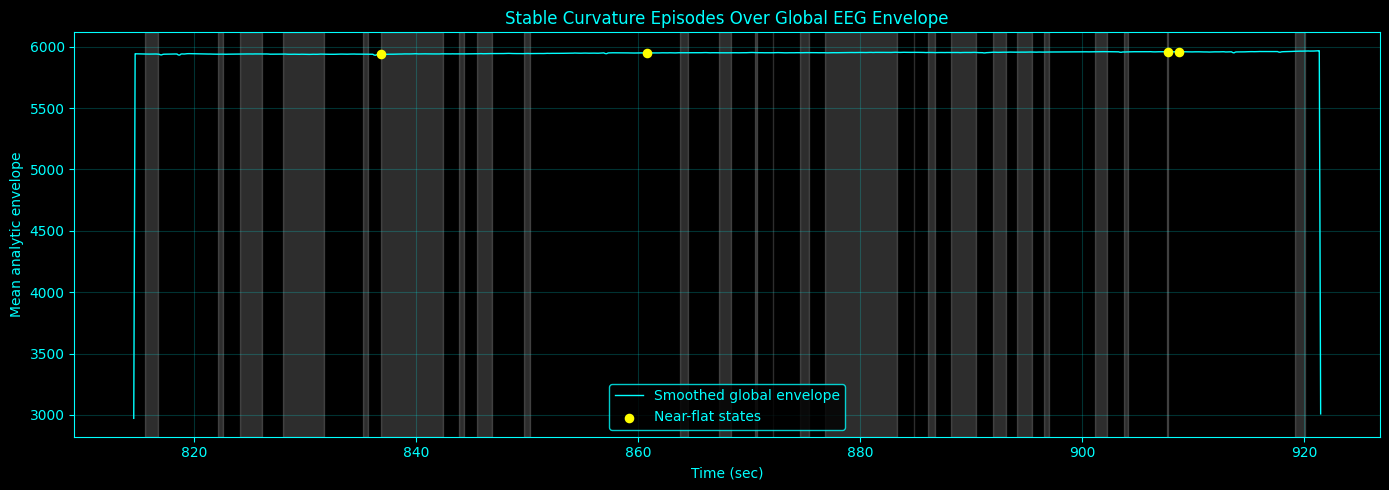

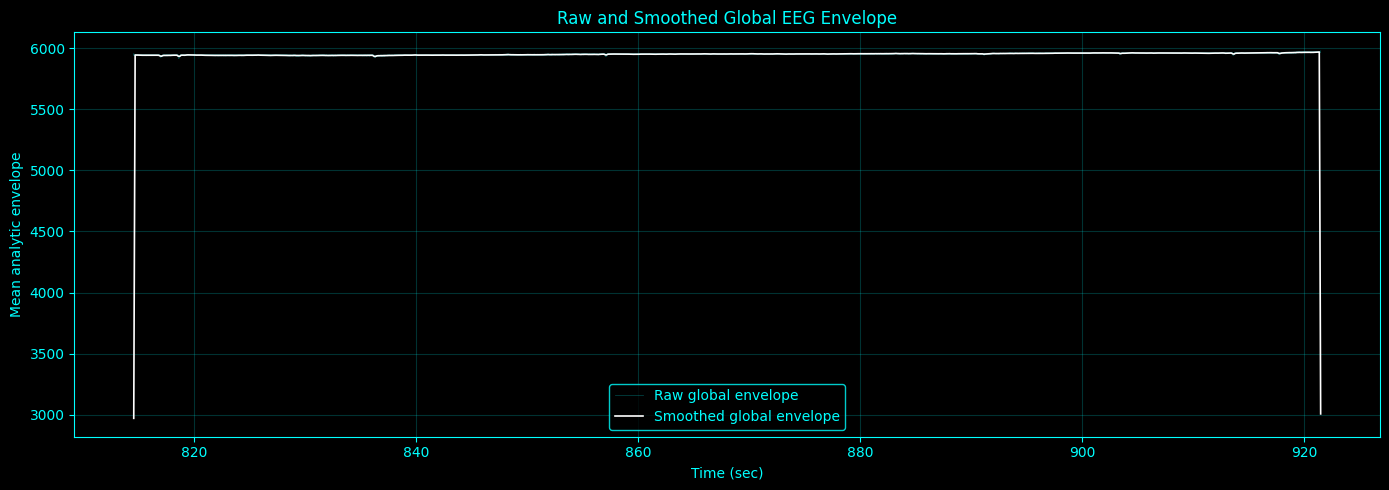

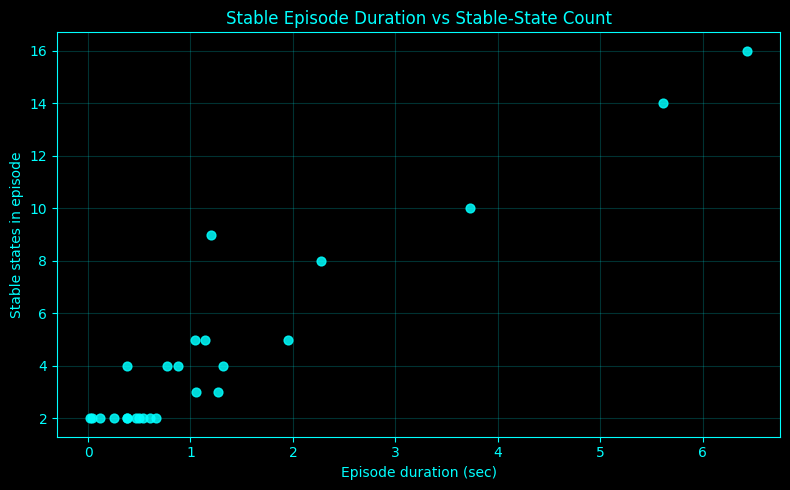

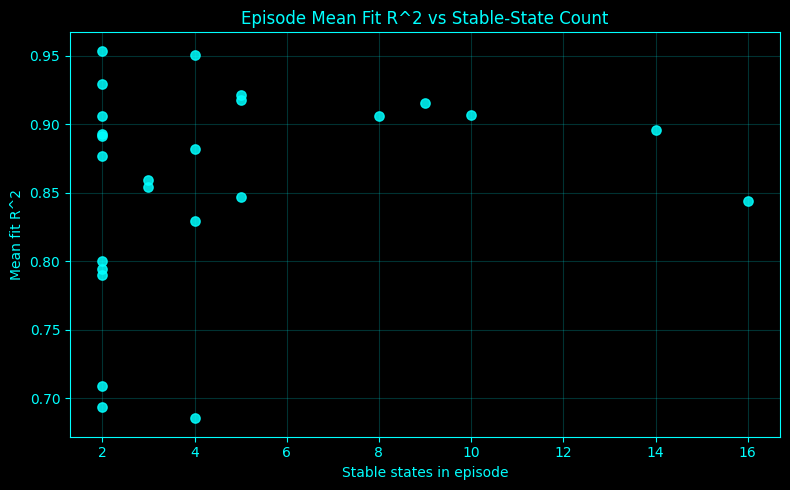

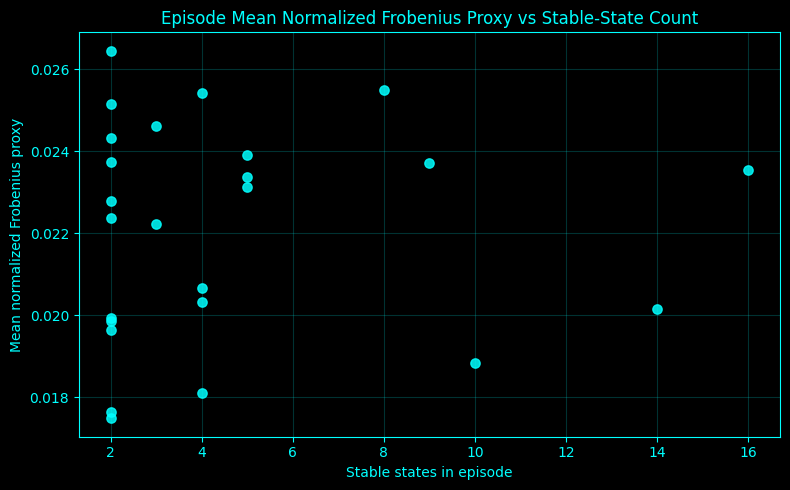

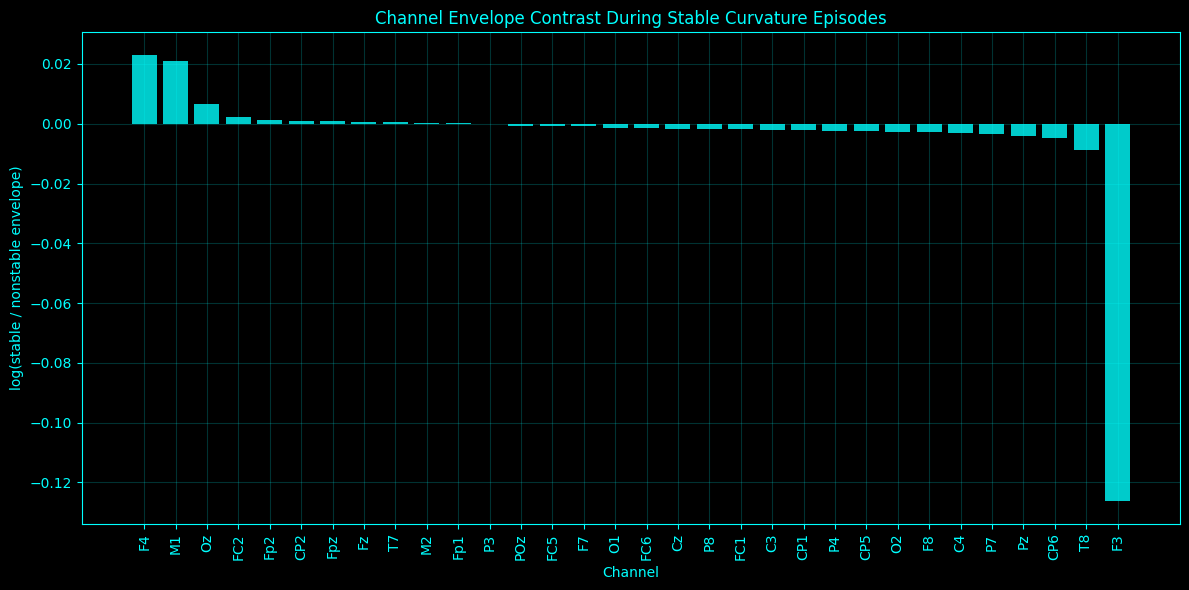

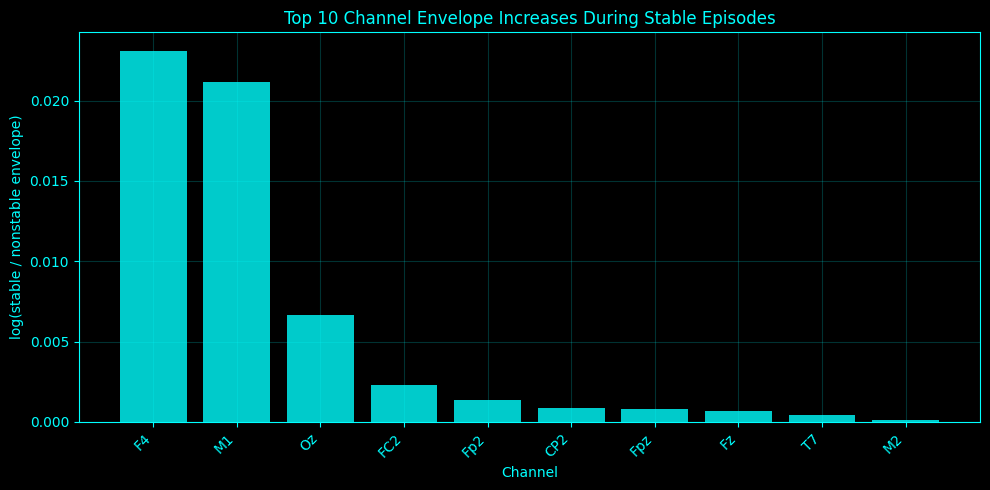

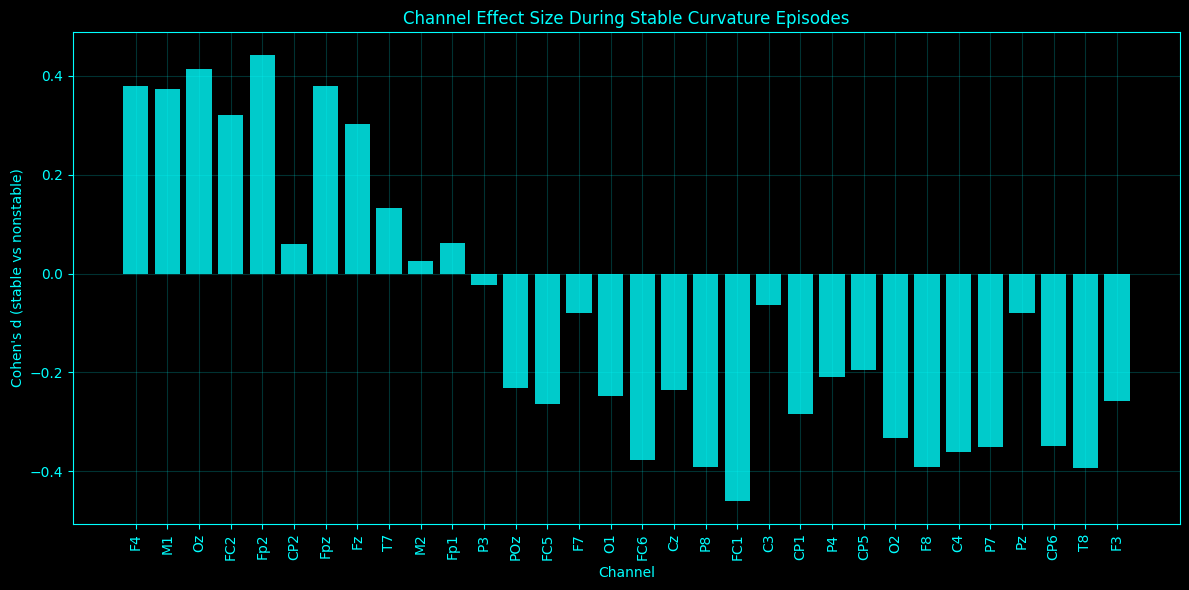

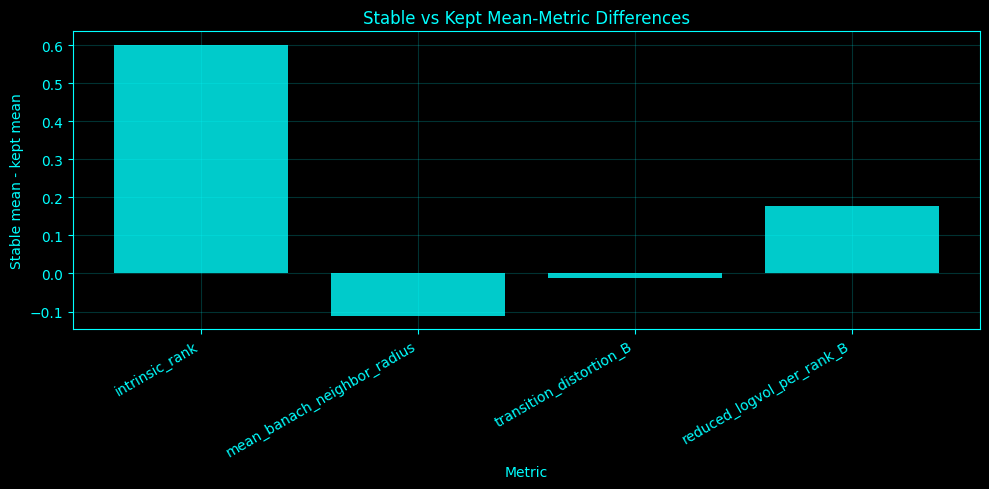

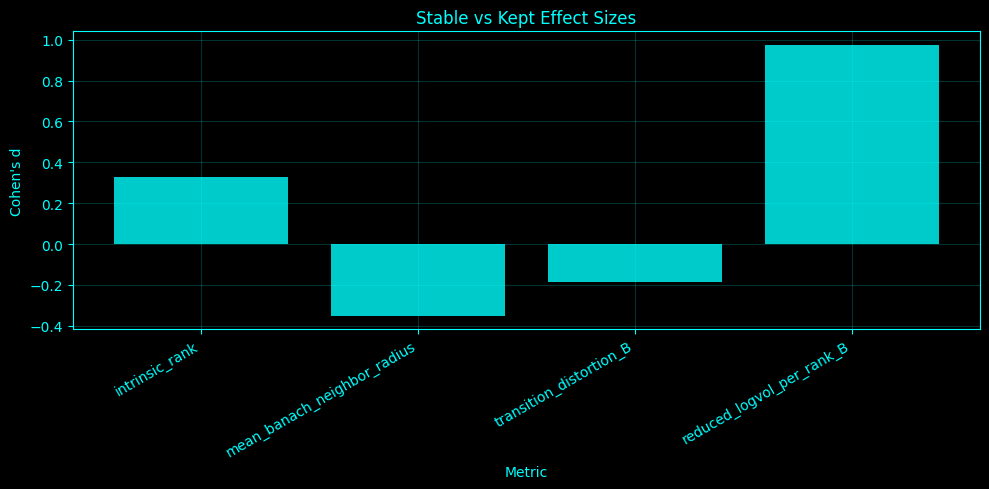

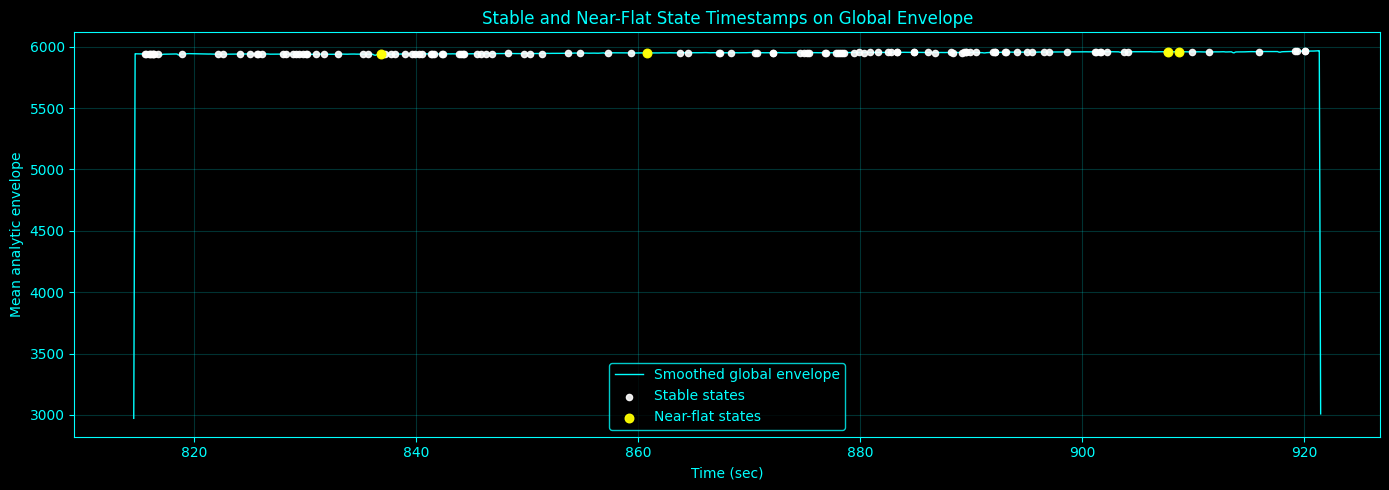

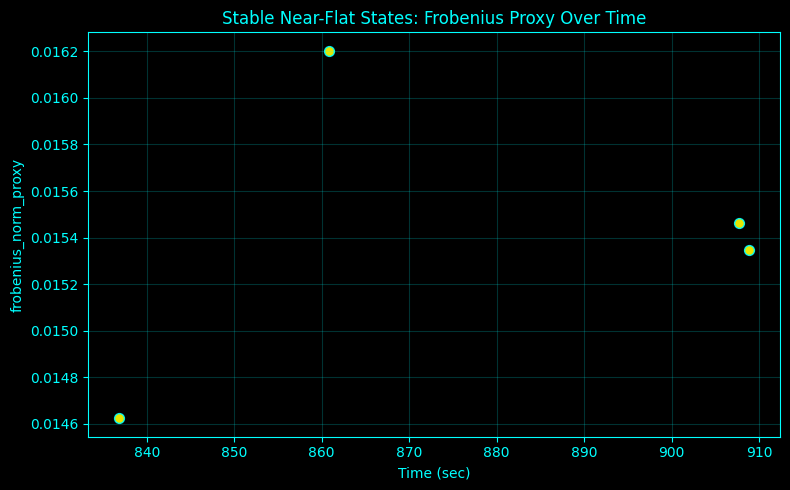


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/stable_curvature_episodes.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/stable_vs_nonstable_channel_envelope_contrast.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/stable_vs_kept_state_metric_contrast.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/stable_near_flat_state_table.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/stable_curvature_temporal_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/plots

Saved plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvature_temporal_episodes_v1/plots/stable_episodes_on_global_envelope.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_curvat

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
state_csv = os.path.join(geom_dir, "banach_state_summary_v2.csv")
stable_csv = os.path.join(geom_dir, "stable_local_curvature_states.csv")
near_flat_csv = os.path.join(geom_dir, "stable_near_flat_local_curvature_states.csv")

out_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Temporal episode controls
episode_gap_sec = 1.0
episode_min_states = 2

# EEG feature controls
env_smooth_sec = 0.250
eps = 1e-12

ACCENT = "cyan"
BG = "black"

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def cohen_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) < 2 or len(b) < 2:
        return np.nan

    va = np.var(a, ddof=1)
    vb = np.var(b, ddof=1)
    pooled = np.sqrt(((len(a) - 1) * va + (len(b) - 1) * vb) / max(len(a) + len(b) - 2, 1))

    return float((np.mean(a) - np.mean(b)) / (pooled + eps))

def build_time_clusters(times, gap_sec=1.0):
    times = np.sort(np.asarray(times, dtype=float))
    if len(times) == 0:
        return []

    clusters = []
    start = times[0]
    prev = times[0]
    count = 1

    for t in times[1:]:
        if (t - prev) <= gap_sec:
            count += 1
            prev = t
        else:
            clusters.append((start, prev, count))
            start = t
            prev = t
            count = 1

    clusters.append((start, prev, count))
    return clusters

def dominant_signature(df):
    if len(df) == 0:
        return "NA"
    sig = df[["n_pos_eigs", "n_neg_eigs", "n_zero_eigs"]].copy()
    sig["key"] = sig.apply(lambda r: f"({int(r['n_pos_eigs'])},{int(r['n_neg_eigs'])},{int(r['n_zero_eigs'])})", axis=1)
    return sig["key"].value_counts().index[0]

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
state_df = pd.read_csv(state_csv)
stable_df = pd.read_csv(stable_csv)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv)
else:
    near_flat_df = stable_df.iloc[0:0].copy()

kept_df = state_df.loc[state_df["density_kept"] == 1].copy().reset_index(drop=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
global_env = np.mean(envelope, axis=1)

smooth_w = int(env_smooth_sec * sampling_rate)
global_env_smooth = moving_average(global_env, smooth_w)

# -------------------------------------------------------
# STABLE STATE EPISODES
# -------------------------------------------------------
stable_times = np.sort(stable_df["time_sec"].values)
clusters = build_time_clusters(stable_times, gap_sec=episode_gap_sec)

episode_rows = []

for episode_id, (t0, t1, n_states) in enumerate(clusters, start=1):
    if n_states < episode_min_states:
        continue

    sub = stable_df[(stable_df["time_sec"] >= t0 - 1e-9) & (stable_df["time_sec"] <= t1 + 1e-9)].copy()
    sub_nf = near_flat_df[(near_flat_df["time_sec"] >= t0 - 1e-9) & (near_flat_df["time_sec"] <= t1 + 1e-9)].copy()

    sample_mask = (time_sec >= t0) & (time_sec <= t1)
    if np.any(sample_mask):
        mean_env_episode = float(np.mean(global_env[sample_mask]))
        peak_env_episode = float(np.max(global_env[sample_mask]))
    else:
        mean_env_episode = np.nan
        peak_env_episode = np.nan

    episode_rows.append({
        "episode_id": episode_id,
        "start_time_sec": float(t0),
        "end_time_sec": float(t1),
        "duration_sec": float(t1 - t0),
        "n_stable_states": int(n_states),
        "n_near_flat_states": int(len(sub_nf)),
        "mean_fit_r2": float(np.mean(sub["fit_r2"])) if len(sub) else np.nan,
        "mean_frobenius_norm_proxy": float(np.mean(sub["frobenius_norm_proxy"])) if len(sub) else np.nan,
        "mean_abs_laplacian_norm_proxy": float(np.mean(np.abs(sub["laplacian_norm_proxy"]))) if len(sub) else np.nan,
        "mean_boot_r2_median": float(np.mean(sub["boot_r2_median"])) if len(sub) else np.nan,
        "mean_boot_frob_norm_cv": float(np.mean(sub["boot_frob_norm_cv"])) if len(sub) else np.nan,
        "mean_transition_distortion_B": float(np.mean(sub["transition_distortion_B"])) if len(sub) else np.nan,
        "mean_neighbor_radius": float(np.mean(sub["mean_banach_neighbor_radius"])) if len(sub) else np.nan,
        "dominant_signature": dominant_signature(sub),
        "mean_global_envelope": mean_env_episode,
        "peak_global_envelope": peak_env_episode,
    })

episodes_df = pd.DataFrame(episode_rows).sort_values(
    ["n_stable_states", "duration_sec"], ascending=[False, False]
).reset_index(drop=True)

# -------------------------------------------------------
# SAMPLE-LEVEL MASKS
# -------------------------------------------------------
stable_sample_mask = np.zeros(n_samples, dtype=bool)
for _, row in episodes_df.iterrows():
    stable_sample_mask |= (
        (time_sec >= row["start_time_sec"]) &
        (time_sec <= row["end_time_sec"])
    )

near_flat_sample_mask = np.zeros(n_samples, dtype=bool)
if len(near_flat_df) > 0:
    half_window = 0.150
    for t in near_flat_df["time_sec"].values:
        near_flat_sample_mask |= (
            (time_sec >= t - half_window) &
            (time_sec <= t + half_window)
        )

nonstable_sample_mask = ~stable_sample_mask

# -------------------------------------------------------
# CHANNEL CONTRASTS: STABLE VS NONSTABLE
# -------------------------------------------------------
channel_rows = []

for ch in range(n_channels):
    env_ch = envelope[:, ch]

    stable_vals = env_ch[stable_sample_mask]
    nonstable_vals = env_ch[nonstable_sample_mask]

    stable_mean = float(np.mean(stable_vals)) if len(stable_vals) else np.nan
    nonstable_mean = float(np.mean(nonstable_vals)) if len(nonstable_vals) else np.nan

    channel_rows.append({
        "channel": eeg_channel_names[ch],
        "stable_mean_envelope": stable_mean,
        "nonstable_mean_envelope": nonstable_mean,
        "log_ratio_stable_vs_nonstable": float(np.log((stable_mean + eps) / (nonstable_mean + eps))),
        "cohen_d_stable_vs_nonstable": cohen_d(stable_vals, nonstable_vals),
        "stable_std_envelope": float(np.std(stable_vals)) if len(stable_vals) else np.nan,
        "nonstable_std_envelope": float(np.std(nonstable_vals)) if len(nonstable_vals) else np.nan,
        "n_stable_samples": int(len(stable_vals)),
        "n_nonstable_samples": int(len(nonstable_vals)),
    })

channel_df = pd.DataFrame(channel_rows).sort_values(
    "log_ratio_stable_vs_nonstable", ascending=False
).reset_index(drop=True)

# -------------------------------------------------------
# STATE-LEVEL CONTRASTS: STABLE VS KEPT
# -------------------------------------------------------
stable_vs_kept_rows = []
compare_cols = [
    "intrinsic_rank",
    "mean_banach_neighbor_radius",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
]

for col in compare_cols:
    a = stable_df[col].values
    b = kept_df[col].values

    stable_vs_kept_rows.append({
        "metric": col,
        "stable_mean": float(np.mean(a)),
        "kept_mean": float(np.mean(b)),
        "stable_median": float(np.median(a)),
        "kept_median": float(np.median(b)),
        "difference_mean": float(np.mean(a) - np.mean(b)),
        "cohen_d_stable_vs_kept": cohen_d(a, b),
    })

stable_vs_kept_df = pd.DataFrame(stable_vs_kept_rows)

# -------------------------------------------------------
# NEAR-FLAT TABLE
# -------------------------------------------------------
if len(near_flat_df) > 0:
    near_flat_table = near_flat_df[[
        "state_index_original",
        "time_sec",
        "intrinsic_rank",
        "fit_r2",
        "frobenius_norm_proxy",
        "laplacian_norm_proxy",
        "boot_r2_median",
        "boot_frob_norm_cv",
        "boot_lap_sign_stability",
        "boot_signature_stability",
        "n_pos_eigs",
        "n_neg_eigs",
        "n_zero_eigs",
    ]].sort_values(["frobenius_norm_proxy", "time_sec"]).reset_index(drop=True)
else:
    near_flat_table = pd.DataFrame()

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
episodes_csv = os.path.join(out_dir, "stable_curvature_episodes.csv")
channel_csv = os.path.join(out_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")
state_compare_csv = os.path.join(out_dir, "stable_vs_kept_state_metric_contrast.csv")
near_flat_table_csv = os.path.join(out_dir, "stable_near_flat_state_table.csv")
summary_txt = os.path.join(out_dir, "stable_curvature_temporal_summary.txt")

episodes_df.to_csv(episodes_csv, index=False)
channel_df.to_csv(channel_csv, index=False)
stable_vs_kept_df.to_csv(state_compare_csv, index=False)
near_flat_table.to_csv(near_flat_table_csv, index=False)

# -------------------------------------------------------
# SUMMARY TXT
# -------------------------------------------------------
with open(summary_txt, "w") as f:
    f.write("Stable Curvature Temporal Episode Summary\n")
    f.write("=======================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Geometry dir: {geom_dir}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Episode gap sec: {episode_gap_sec}\n")
    f.write(f"Episode min states: {episode_min_states}\n\n")

    f.write("Counts:\n")
    f.write(f"  kept states = {len(kept_df)}\n")
    f.write(f"  stable states = {len(stable_df)}\n")
    f.write(f"  stable near-flat states = {len(near_flat_df)}\n")
    f.write(f"  stable episodes = {len(episodes_df)}\n")
    f.write(f"  stable sample fraction = {np.mean(stable_sample_mask):.6f}\n\n")

    if len(episodes_df) > 0:
        f.write("Largest stable episodes:\n")
        f.write(episodes_df.head(10).to_string(index=False))
        f.write("\n\n")

    f.write("Stable vs kept state metrics:\n")
    f.write(stable_vs_kept_df.to_string(index=False))
    f.write("\n\n")

    f.write("Top channel envelope increases during stable episodes:\n")
    f.write(channel_df.head(10).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_table) > 0:
        f.write("Stable near-flat states:\n")
        f.write(near_flat_table.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Global envelope with stable episodes shaded
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.plot(time_sec, global_env_smooth, linewidth=1.0, color=ACCENT, label="Smoothed global envelope")

for _, row in episodes_df.iterrows():
    ax.axvspan(row["start_time_sec"], row["end_time_sec"], alpha=0.18, color="white")

if len(near_flat_df) > 0:
    ax.scatter(
        near_flat_df["time_sec"].values,
        np.interp(near_flat_df["time_sec"].values, time_sec, global_env_smooth),
        s=35,
        color="yellow",
        label="Near-flat states",
        zorder=5
    )

ax.set_title("Stable Curvature Episodes Over Global EEG Envelope")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Mean analytic envelope")
ax.legend()

plot1_path = os.path.join(plots_dir, "stable_episodes_on_global_envelope.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Raw and smoothed global envelope over time
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.plot(time_sec, global_env, linewidth=0.6, alpha=0.25, color=ACCENT, label="Raw global envelope")
ax.plot(time_sec, global_env_smooth, linewidth=1.2, color="white", label="Smoothed global envelope")

ax.set_title("Raw and Smoothed Global EEG Envelope")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Mean analytic envelope")
ax.legend()

plot2_path = os.path.join(plots_dir, "raw_and_smoothed_global_envelope.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Episode size vs duration
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

if len(episodes_df) > 0:
    ax.scatter(
        episodes_df["duration_sec"].values,
        episodes_df["n_stable_states"].values,
        s=40,
        alpha=0.85,
        color=ACCENT
    )

ax.set_title("Stable Episode Duration vs Stable-State Count")
ax.set_xlabel("Episode duration (sec)")
ax.set_ylabel("Stable states in episode")

plot3_path = os.path.join(plots_dir, "stable_episode_duration_vs_count.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Episode mean fit R2 vs episode size
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

if len(episodes_df) > 0:
    ax.scatter(
        episodes_df["n_stable_states"].values,
        episodes_df["mean_fit_r2"].values,
        s=45,
        alpha=0.85,
        color=ACCENT
    )

ax.set_title("Episode Mean Fit R^2 vs Stable-State Count")
ax.set_xlabel("Stable states in episode")
ax.set_ylabel("Mean fit R^2")

plot4_path = os.path.join(plots_dir, "episode_mean_fit_r2_vs_count.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Episode mean curvature vs episode size
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

if len(episodes_df) > 0:
    ax.scatter(
        episodes_df["n_stable_states"].values,
        episodes_df["mean_frobenius_norm_proxy"].values,
        s=45,
        alpha=0.85,
        color=ACCENT
    )

ax.set_title("Episode Mean Normalized Frobenius Proxy vs Stable-State Count")
ax.set_xlabel("Stable states in episode")
ax.set_ylabel("Mean normalized Frobenius proxy")

plot5_path = os.path.join(plots_dir, "episode_mean_frobenius_vs_count.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Channel contrast bar plot
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(len(channel_df)),
    channel_df["log_ratio_stable_vs_nonstable"].values,
    color=ACCENT,
    alpha=0.8
)
ax.set_xticks(np.arange(len(channel_df)))
ax.set_xticklabels(channel_df["channel"].values, rotation=90)
ax.set_title("Channel Envelope Contrast During Stable Curvature Episodes")
ax.set_xlabel("Channel")
ax.set_ylabel("log(stable / nonstable envelope)")

plot6_path = os.path.join(plots_dir, "channel_envelope_contrast_stable_vs_nonstable.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top 10 channel contrasts only
top_channel_df = channel_df.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(len(top_channel_df)),
    top_channel_df["log_ratio_stable_vs_nonstable"].values,
    color=ACCENT,
    alpha=0.8
)
ax.set_xticks(np.arange(len(top_channel_df)))
ax.set_xticklabels(top_channel_df["channel"].values, rotation=45, ha="right")
ax.set_title("Top 10 Channel Envelope Increases During Stable Episodes")
ax.set_xlabel("Channel")
ax.set_ylabel("log(stable / nonstable envelope)")

plot7_path = os.path.join(plots_dir, "top10_channel_envelope_contrast.png")
plt.tight_layout()
plt.savefig(plot7_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 8) Cohen's d by channel
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(len(channel_df)),
    channel_df["cohen_d_stable_vs_nonstable"].values,
    color=ACCENT,
    alpha=0.8
)
ax.set_xticks(np.arange(len(channel_df)))
ax.set_xticklabels(channel_df["channel"].values, rotation=90)
ax.set_title("Channel Effect Size During Stable Curvature Episodes")
ax.set_xlabel("Channel")
ax.set_ylabel("Cohen's d (stable vs nonstable)")

plot8_path = os.path.join(plots_dir, "channel_effect_size_stable_vs_nonstable.png")
plt.tight_layout()
plt.savefig(plot8_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 9) Stable vs kept metric contrast
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(len(stable_vs_kept_df)),
    stable_vs_kept_df["difference_mean"].values,
    color=ACCENT,
    alpha=0.8
)
ax.set_xticks(np.arange(len(stable_vs_kept_df)))
ax.set_xticklabels(stable_vs_kept_df["metric"].values, rotation=30, ha="right")
ax.set_title("Stable vs Kept Mean-Metric Differences")
ax.set_xlabel("Metric")
ax.set_ylabel("Stable mean - kept mean")

plot9_path = os.path.join(plots_dir, "stable_vs_kept_mean_metric_differences.png")
plt.tight_layout()
plt.savefig(plot9_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 10) Stable vs kept effect sizes
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(len(stable_vs_kept_df)),
    stable_vs_kept_df["cohen_d_stable_vs_kept"].values,
    color=ACCENT,
    alpha=0.8
)
ax.set_xticks(np.arange(len(stable_vs_kept_df)))
ax.set_xticklabels(stable_vs_kept_df["metric"].values, rotation=30, ha="right")
ax.set_title("Stable vs Kept Effect Sizes")
ax.set_xlabel("Metric")
ax.set_ylabel("Cohen's d")

plot10_path = os.path.join(plots_dir, "stable_vs_kept_effect_sizes.png")
plt.tight_layout()
plt.savefig(plot10_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 11) Stable-state timestamps on global envelope
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.plot(time_sec, global_env_smooth, linewidth=1.0, color=ACCENT, label="Smoothed global envelope")

if len(stable_df) > 0:
    ax.scatter(
        stable_df["time_sec"].values,
        np.interp(stable_df["time_sec"].values, time_sec, global_env_smooth),
        s=20,
        color="white",
        alpha=0.9,
        label="Stable states",
        zorder=4
    )

if len(near_flat_df) > 0:
    ax.scatter(
        near_flat_df["time_sec"].values,
        np.interp(near_flat_df["time_sec"].values, time_sec, global_env_smooth),
        s=38,
        color="yellow",
        alpha=0.95,
        label="Near-flat states",
        zorder=5
    )

ax.set_title("Stable and Near-Flat State Timestamps on Global Envelope")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Mean analytic envelope")
ax.legend()

plot11_path = os.path.join(plots_dir, "stable_and_nearflat_timestamps_on_envelope.png")
plt.tight_layout()
plt.savefig(plot11_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 12) Near-flat state curvature values, if present
if len(near_flat_table) > 0:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        near_flat_table["time_sec"].values,
        near_flat_table["frobenius_norm_proxy"].values,
        s=50,
        alpha=0.9,
        color="yellow",
        edgecolors=ACCENT
    )
    ax.set_title("Stable Near-Flat States: Frobenius Proxy Over Time")
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("frobenius_norm_proxy")

    plot12_path = os.path.join(plots_dir, "nearflat_frobenius_over_time.png")
    plt.tight_layout()
    plt.savefig(plot12_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot12_path = None

print("\nSaved:")
print(episodes_csv)
print(channel_csv)
print(state_compare_csv)
print(near_flat_table_csv)
print(summary_txt)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
print(plot5_path)
print(plot6_path)
print(plot7_path)
print(plot8_path)
print(plot9_path)
print(plot10_path)
print(plot11_path)
if plot12_path is not None:
    print(plot12_path)

print("\nQuick summary:")
print(f"Stable states: {len(stable_df)}")
print(f"Stable near-flat states: {len(near_flat_df)}")
print(f"Stable episodes: {len(episodes_df)}")
if len(episodes_df) > 0:
    print("\nTop 10 episodes:")
    print(episodes_df.head(10).to_string(index=False))
print("\nTop 10 channels by stable/nonstable envelope log-ratio:")
print(channel_df.head(10).to_string(index=False))

Top channels for aligned corridor profiles: ['Fp2', 'Oz', 'F4', 'Fpz', 'M1', 'FC2']


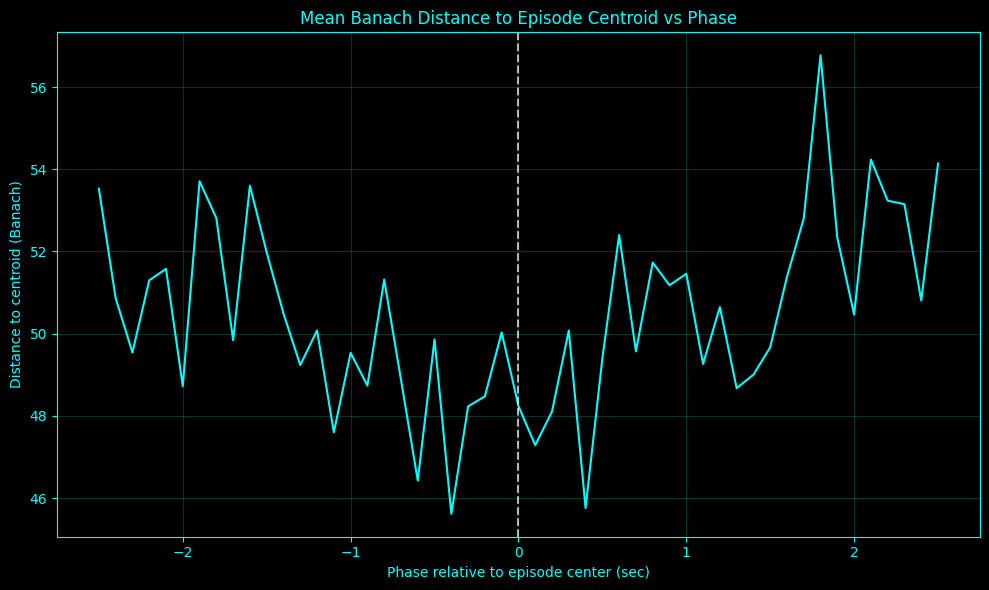

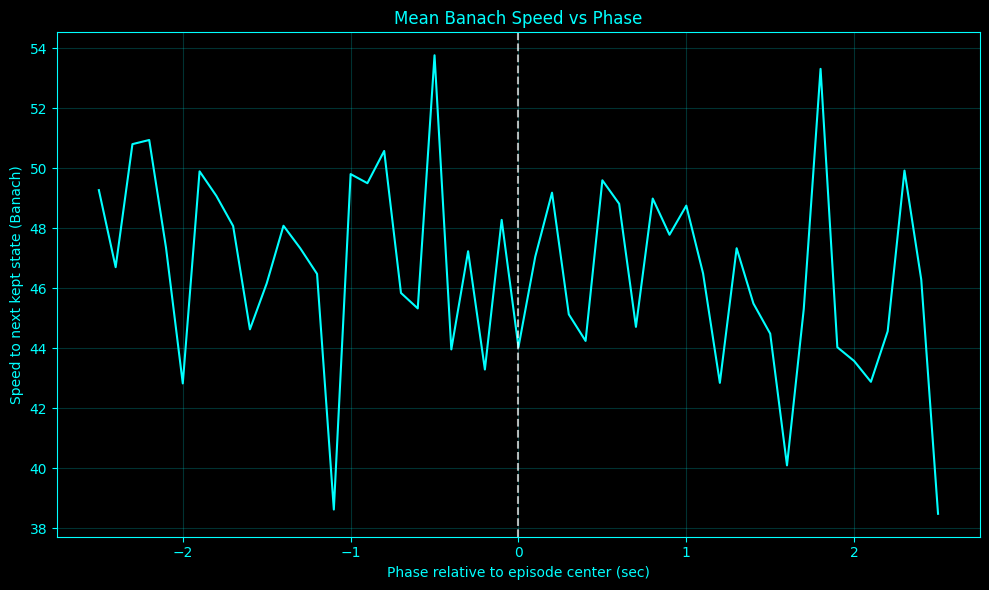

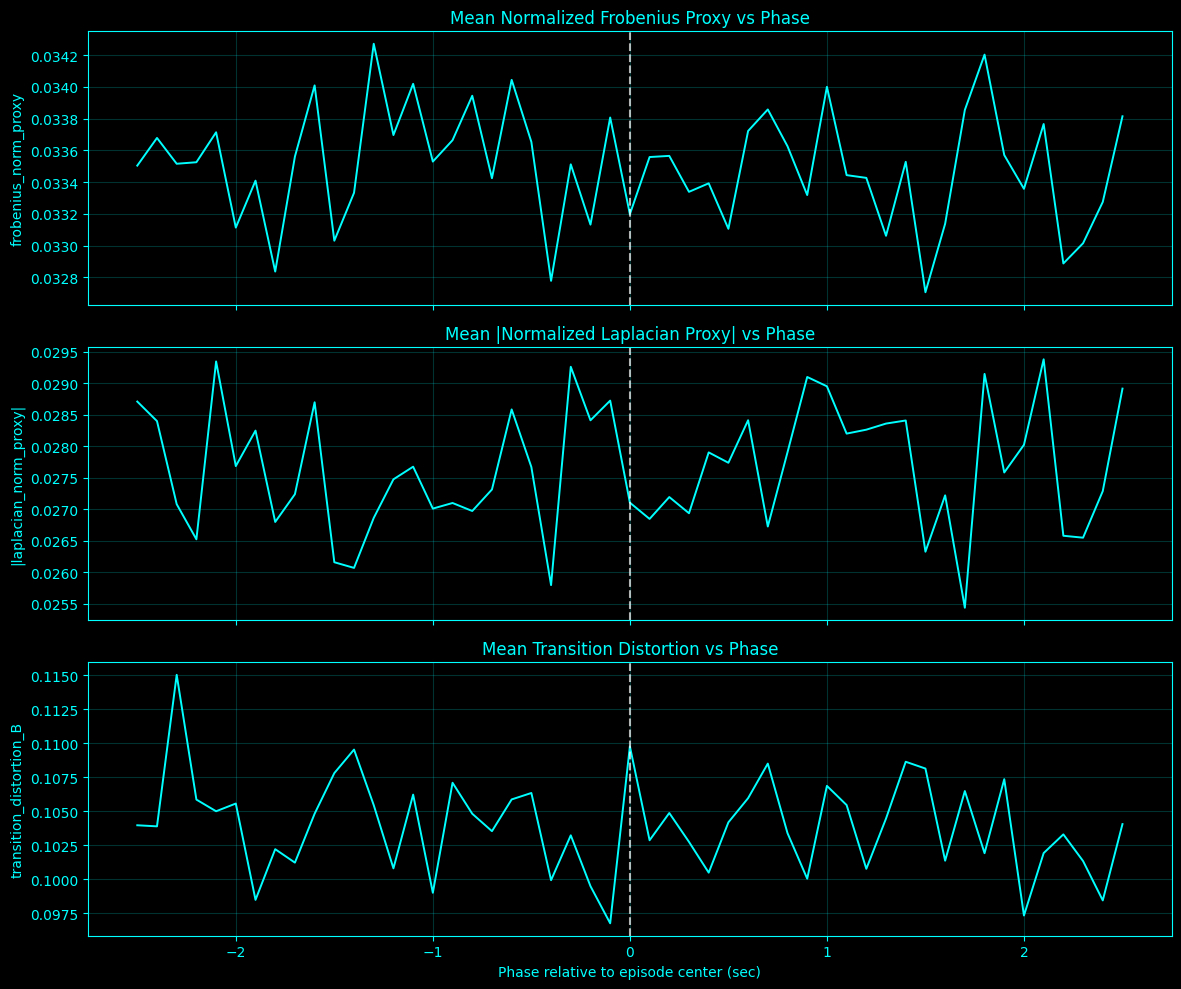

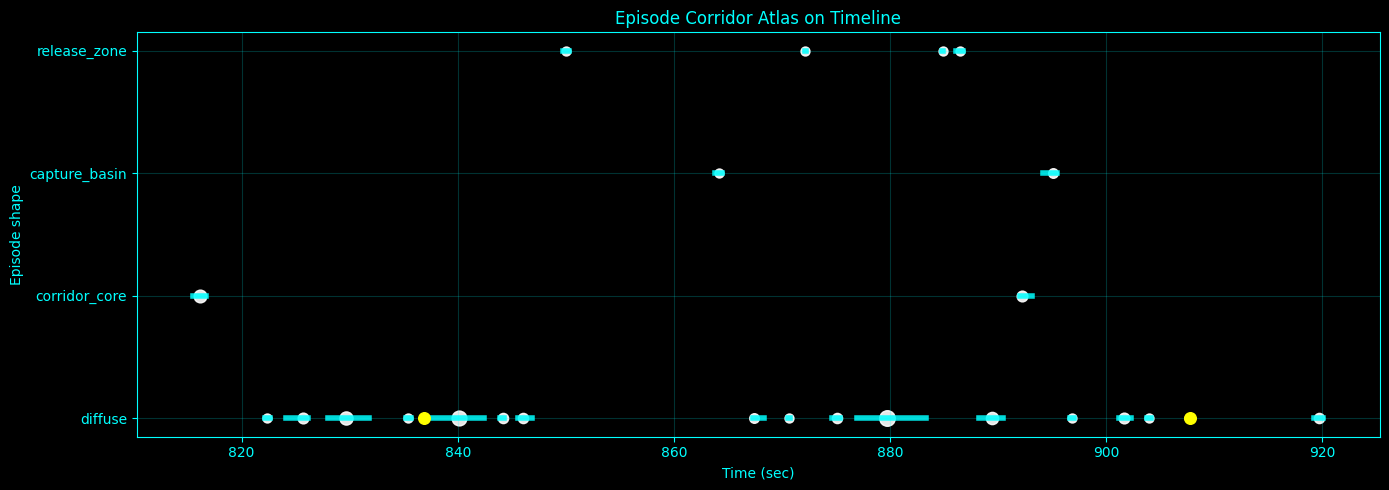

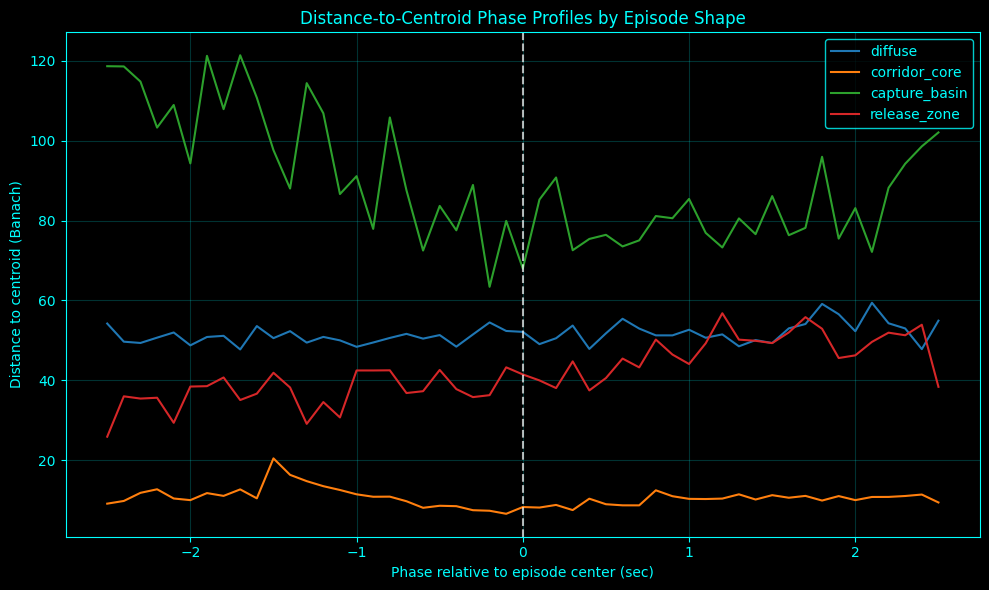

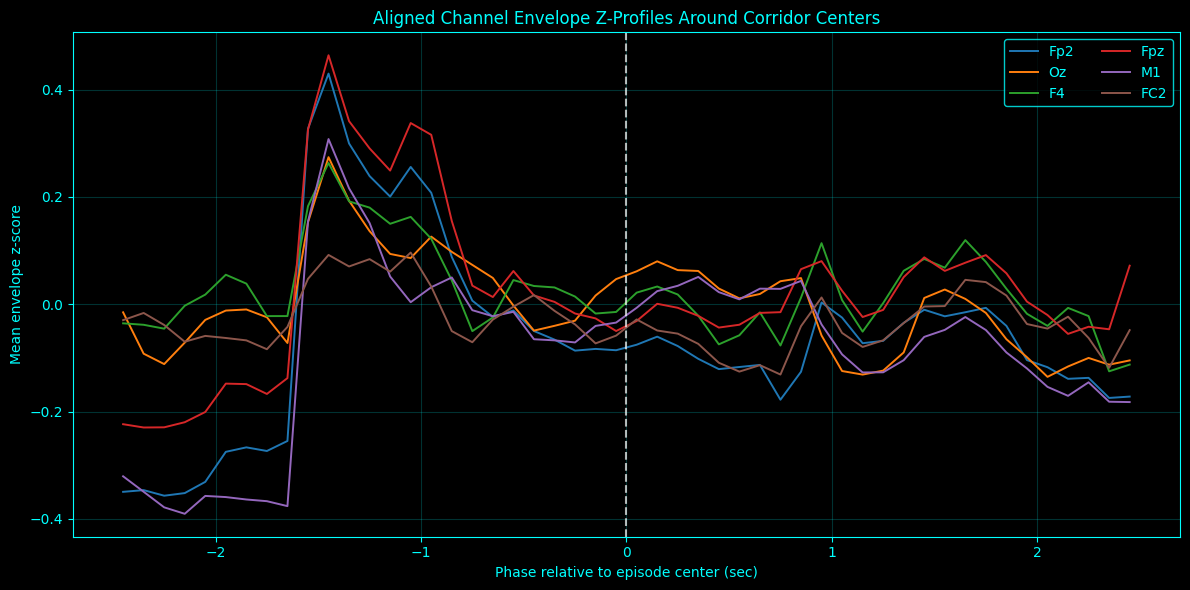


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/episode_centered_corridor_states.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/episode_corridor_atlas.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/corridor_phase_profile.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/corridor_phase_profile_by_shape.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/corridor_channel_phase_profile.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/near_flat_episode_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/episode_corridor_atlas_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/stable_episode_corridor_atlas_v1/plots

Saved plots:
/home/a/projects/Complete

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")

state_csv = os.path.join(geom_dir, "banach_state_summary_v2.csv")
all_local_csv = os.path.join(geom_dir, "local_chart_curvature_all_states.csv")
stable_csv = os.path.join(geom_dir, "stable_local_curvature_states.csv")
near_flat_csv = os.path.join(geom_dir, "stable_near_flat_local_curvature_states.csv")

episodes_csv = os.path.join(temporal_dir, "stable_curvature_episodes.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

out_dir = os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

max_state_points = 12000
banach_p = 4.0
scale_reg = 1e-6

# Episode-centered alignment
phase_window_sec = 2.5
phase_bin_sec = 0.10

# For envelope alignment
top_k_channels = 6
channel_smooth_sec = 0.150

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def local_coordinate_scales(X_local, reg=1e-6, method="mad"):
    X_local = np.asarray(X_local, dtype=float)
    if method == "mad":
        ctr = np.median(X_local, axis=0, keepdims=True)
        scales = 1.4826 * np.median(np.abs(X_local - ctr), axis=0)
    else:
        ctr = np.mean(X_local, axis=0, keepdims=True)
        scales = np.sqrt(np.mean((X_local - ctr) ** 2, axis=0))
    return np.maximum(scales, reg)

def weighted_lp_norm(V, scales, p=4.0):
    V = np.asarray(V, dtype=float)
    scales = np.asarray(scales, dtype=float)
    if V.ndim == 1:
        V = V[None, :]
    return np.power(np.sum(np.abs(V / (scales + eps)) ** p, axis=1) + eps, 1.0 / p)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def phase_bin_values(phases, values, bin_edges):
    out = []
    inds = np.digitize(phases, bin_edges) - 1
    for i in range(len(bin_edges) - 1):
        m = inds == i
        out.append(safe_mean(values[m]))
    return np.array(out)

def band_mean(df, col, lo, hi):
    x = df[(df["phase_sec"] >= lo) & (df["phase_sec"] <= hi)][col].values
    return safe_mean(x)

def classify_episode_shape(ep_df):
    pre_dist = band_mean(ep_df, "dist_to_centroid_B", -1.5, -0.5)
    ctr_dist = band_mean(ep_df, "dist_to_centroid_B", -0.25, 0.25)
    post_dist = band_mean(ep_df, "dist_to_centroid_B", 0.5, 1.5)

    pre_speed = band_mean(ep_df, "speed_to_next_B", -1.5, -0.5)
    ctr_speed = band_mean(ep_df, "speed_to_next_B", -0.25, 0.25)
    post_speed = band_mean(ep_df, "speed_to_next_B", 0.5, 1.5)

    # basic exploratory morphology labels
    if np.isfinite(pre_dist) and np.isfinite(ctr_dist) and np.isfinite(post_dist):
        enters = ctr_dist < 0.90 * pre_dist
        exits = ctr_dist < 0.90 * post_dist
        slow_center = (
            np.isfinite(ctr_speed) and np.isfinite(pre_speed) and np.isfinite(post_speed) and
            ctr_speed < 0.95 * pre_speed and ctr_speed < 0.95 * post_speed
        )

        if enters and exits and slow_center:
            return "transit_throat"
        if enters and post_dist <= 1.10 * ctr_dist:
            return "capture_basin"
        if post_dist > 1.10 * ctr_dist and pre_dist <= 1.10 * ctr_dist:
            return "release_zone"
        if enters and exits:
            return "corridor_core"

    return "diffuse"

# -------------------------------------------------------
# LOAD GEOMETRY OUTPUTS
# -------------------------------------------------------
state_df = pd.read_csv(state_csv)
all_local_df = pd.read_csv(all_local_csv).sort_values("kept_index").reset_index(drop=True)
stable_df = pd.read_csv(stable_csv).sort_values("time_sec").reset_index(drop=True)

if os.path.exists(near_flat_csv):
    near_flat_df = pd.read_csv(near_flat_csv).sort_values("time_sec").reset_index(drop=True)
else:
    near_flat_df = stable_df.iloc[0:0].copy()

episodes_df = pd.read_csv(episodes_csv).sort_values("start_time_sec").reset_index(drop=True)
channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
    "cohen_d_stable_vs_nonstable", ascending=False
).reset_index(drop=True)

kept_df = state_df.loc[state_df["density_kept"] == 1].copy().reset_index(drop=True)

if len(kept_df) != len(all_local_df):
    raise ValueError("kept_df and all_local_df length mismatch; check prior outputs.")

# -------------------------------------------------------
# REBUILD AMBIENT STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(len(analytic_EEG), max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
X_real = realify_complex_states(Z_sample)

density_mask = state_df["density_kept"].values.astype(bool)
X_kept = X_real[density_mask]

if len(X_kept) != len(all_local_df):
    raise ValueError("X_kept and all_local_df length mismatch; check reconstruction.")

time_full = start_time + np.arange(len(EEG_segment)) * dt

# analytic envelope for channel alignment
envelope = np.abs(analytic_EEG)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)
env_smooth_w = int(channel_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([moving_average(env_z[:, ch], env_smooth_w) for ch in range(env_z.shape[1])])

# choose top exploratory channels from prior temporal contrast
top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]

print(f"Top channels for aligned corridor profiles: {top_channels}")

# -------------------------------------------------------
# GLOBAL SPEED IN AMBIENT STATE ORDER
# -------------------------------------------------------
# speed measured in the kept-state temporal order; last state gets NaN
speed_euclid = np.full(len(X_kept), np.nan)
for i in range(len(X_kept) - 1):
    speed_euclid[i] = float(np.linalg.norm(X_kept[i + 1] - X_kept[i]))
all_local_df["speed_euclid_next"] = speed_euclid

# -------------------------------------------------------
# BUILD EPISODE-CENTERED CORRIDOR TABLE
# -------------------------------------------------------
phase_edges = np.arange(-phase_window_sec, phase_window_sec + phase_bin_sec, phase_bin_sec)
phase_centers = 0.5 * (phase_edges[:-1] + phase_edges[1:])

corridor_rows = []
episode_rows = []
channel_phase_rows = []

for _, ep in episodes_df.iterrows():
    episode_id = int(ep["episode_id"])
    t0 = float(ep["start_time_sec"])
    t1 = float(ep["end_time_sec"])

    stable_sub = stable_df[(stable_df["time_sec"] >= t0 - 1e-9) & (stable_df["time_sec"] <= t1 + 1e-9)].copy()
    if len(stable_sub) == 0:
        continue

    center_time = float(np.median(stable_sub["time_sec"].values))
    stable_idx = stable_sub["kept_index"].astype(int).values
    stable_points = X_kept[stable_idx]

    centroid = np.mean(stable_points, axis=0)
    scales = local_coordinate_scales(stable_points - centroid, reg=scale_reg, method="mad")

    # kept-state window around episode center
    window_mask = (
        (all_local_df["time_sec"].values >= center_time - phase_window_sec) &
        (all_local_df["time_sec"].values <= center_time + phase_window_sec)
    )
    win_df = all_local_df.loc[window_mask].copy().reset_index(drop=True)

    # compute Banach distance/speed relative to episode centroid + scales
    dist_vals = []
    speed_vals = []

    for _, row in win_df.iterrows():
        idx = int(row["kept_index"])
        dist = weighted_lp_norm(X_kept[idx] - centroid, scales, p=banach_p)[0]
        dist_vals.append(float(dist))

        if idx < len(X_kept) - 1:
            speedB = weighted_lp_norm(X_kept[idx + 1] - X_kept[idx], scales, p=banach_p)[0]
        else:
            speedB = np.nan
        speed_vals.append(float(speedB))

    win_df["episode_id"] = episode_id
    win_df["episode_center_time_sec"] = center_time
    win_df["phase_sec"] = win_df["time_sec"] - center_time
    win_df["dist_to_centroid_B"] = dist_vals
    win_df["speed_to_next_B"] = speed_vals
    win_df["is_near_flat_episode"] = int(np.any(
        (near_flat_df["time_sec"].values >= t0 - 1e-9) &
        (near_flat_df["time_sec"].values <= t1 + 1e-9)
    ))

    ep_class = classify_episode_shape(win_df)
    win_df["episode_shape"] = ep_class
    corridor_rows.append(win_df)

    # episode summary
    episode_rows.append({
        "episode_id": episode_id,
        "start_time_sec": t0,
        "end_time_sec": t1,
        "center_time_sec": center_time,
        "duration_sec": float(t1 - t0),
        "n_stable_states": int(ep["n_stable_states"]),
        "n_near_flat_states": int(ep["n_near_flat_states"]),
        "dominant_signature": ep["dominant_signature"],
        "episode_shape": ep_class,
        "mean_dist_to_centroid_B": safe_mean(win_df["dist_to_centroid_B"].values),
        "min_dist_to_centroid_B": np.nanmin(win_df["dist_to_centroid_B"].values),
        "mean_speed_to_next_B": safe_mean(win_df["speed_to_next_B"].values),
        "mean_frobenius_norm_proxy": safe_mean(win_df["frobenius_norm_proxy"].values),
        "mean_abs_laplacian_norm_proxy": safe_mean(np.abs(win_df["laplacian_norm_proxy"].values)),
        "mean_transition_distortion_B": safe_mean(win_df["transition_distortion_B"].values),
        "mean_reduced_logvol_per_rank_B": safe_mean(win_df["reduced_logvol_per_rank_B"].values),
    })

    # channel-aligned profiles around this episode center
    sample_mask = (
        (time_full >= center_time - phase_window_sec) &
        (time_full <= center_time + phase_window_sec)
    )
    if np.any(sample_mask):
        phase_samples = time_full[sample_mask] - center_time
        for ch, ch_name in zip(top_channel_idx, top_channels):
            vals = env_z_smooth[sample_mask, ch]
            binned = phase_bin_values(phase_samples, vals, phase_edges)
            for pc, val in zip(phase_centers, binned):
                channel_phase_rows.append({
                    "episode_id": episode_id,
                    "episode_shape": ep_class,
                    "channel": ch_name,
                    "phase_sec": float(pc),
                    "mean_env_z": float(val) if np.isfinite(val) else np.nan,
                })

corridor_df = pd.concat(corridor_rows, ignore_index=True) if corridor_rows else pd.DataFrame()
episode_atlas_df = pd.DataFrame(episode_rows).sort_values(
    ["n_stable_states", "duration_sec"], ascending=[False, False]
).reset_index(drop=True)
channel_phase_df = pd.DataFrame(channel_phase_rows)

if len(corridor_df) == 0:
    raise RuntimeError("No corridor rows were built. Check episodes and local outputs.")

corridor_df["abs_laplacian_norm_proxy"] = np.abs(corridor_df["laplacian_norm_proxy"].values)

# -------------------------------------------------------
# AGGREGATED PHASE PROFILES
# -------------------------------------------------------
corridor_df["phase_bin"] = np.round(corridor_df["phase_sec"] / phase_bin_sec) * phase_bin_sec

phase_profile_df = corridor_df.groupby("phase_bin", as_index=False).agg({
    "dist_to_centroid_B": "mean",
    "speed_to_next_B": "mean",
    "frobenius_norm_proxy": "mean",
    "abs_laplacian_norm_proxy": "mean",
    "transition_distortion_B": "mean",
    "reduced_logvol_per_rank_B": "mean",
})

phase_profile_by_shape_df = corridor_df.groupby(["episode_shape", "phase_bin"], as_index=False).agg({
    "dist_to_centroid_B": "mean",
    "speed_to_next_B": "mean",
    "frobenius_norm_proxy": "mean",
    "abs_laplacian_norm_proxy": "mean",
    "transition_distortion_B": "mean",
    "reduced_logvol_per_rank_B": "mean",
})

channel_phase_profile_df = channel_phase_df.groupby(
    ["channel", "episode_shape", "phase_sec"], as_index=False
)["mean_env_z"].mean()

# -------------------------------------------------------
# NEAR-FLAT CONTEXT TABLE
# -------------------------------------------------------
near_flat_context_rows = []

for _, row in near_flat_df.iterrows():
    t = float(row["time_sec"])
    matches = episode_atlas_df[
        (episode_atlas_df["start_time_sec"] <= t + 1e-9) &
        (episode_atlas_df["end_time_sec"] >= t - 1e-9)
    ]

    if len(matches) > 0:
        ep = matches.iloc[0]
        near_flat_context_rows.append({
            "time_sec": t,
            "state_index_original": int(row["state_index_original"]),
            "intrinsic_rank": int(row["intrinsic_rank"]),
            "fit_r2": float(row["fit_r2"]),
            "frobenius_norm_proxy": float(row["frobenius_norm_proxy"]),
            "laplacian_norm_proxy": float(row["laplacian_norm_proxy"]),
            "episode_id": int(ep["episode_id"]),
            "episode_shape": ep["episode_shape"],
            "episode_center_time_sec": float(ep["center_time_sec"]),
            "episode_duration_sec": float(ep["duration_sec"]),
        })
    else:
        near_flat_context_rows.append({
            "time_sec": t,
            "state_index_original": int(row["state_index_original"]),
            "intrinsic_rank": int(row["intrinsic_rank"]),
            "fit_r2": float(row["fit_r2"]),
            "frobenius_norm_proxy": float(row["frobenius_norm_proxy"]),
            "laplacian_norm_proxy": float(row["laplacian_norm_proxy"]),
            "episode_id": np.nan,
            "episode_shape": "unassigned",
            "episode_center_time_sec": np.nan,
            "episode_duration_sec": np.nan,
        })

near_flat_context_df = pd.DataFrame(near_flat_context_rows).sort_values("time_sec").reset_index(drop=True)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
corridor_csv = os.path.join(out_dir, "episode_centered_corridor_states.csv")
episode_atlas_csv = os.path.join(out_dir, "episode_corridor_atlas.csv")
phase_profile_csv = os.path.join(out_dir, "corridor_phase_profile.csv")
phase_profile_by_shape_csv = os.path.join(out_dir, "corridor_phase_profile_by_shape.csv")
channel_phase_profile_csv = os.path.join(out_dir, "corridor_channel_phase_profile.csv")
near_flat_context_csv = os.path.join(out_dir, "near_flat_episode_context.csv")
summary_txt = os.path.join(out_dir, "episode_corridor_atlas_summary.txt")

corridor_df.to_csv(corridor_csv, index=False)
episode_atlas_df.to_csv(episode_atlas_csv, index=False)
phase_profile_df.to_csv(phase_profile_csv, index=False)
phase_profile_by_shape_df.to_csv(phase_profile_by_shape_csv, index=False)
channel_phase_profile_df.to_csv(channel_phase_profile_csv, index=False)
near_flat_context_df.to_csv(near_flat_context_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Episode-Centered Manifold Corridor Atlas\n")
    f.write("=======================================\n\n")
    f.write(f"Geometry dir: {geom_dir}\n")
    f.write(f"Temporal dir: {temporal_dir}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Phase window sec: {phase_window_sec}\n")
    f.write(f"Phase bin sec: {phase_bin_sec}\n")
    f.write(f"Top channels: {top_channels}\n\n")

    f.write("Counts:\n")
    f.write(f"  episodes loaded = {len(episodes_df)}\n")
    f.write(f"  corridor episodes analyzed = {len(episode_atlas_df)}\n")
    f.write(f"  near-flat states = {len(near_flat_context_df)}\n\n")

    f.write("Episode shape counts:\n")
    if len(episode_atlas_df) > 0:
        f.write(episode_atlas_df["episode_shape"].value_counts().to_string())
    else:
        f.write("None")
    f.write("\n\n")

    if len(episode_atlas_df) > 0:
        f.write("Top 12 episodes by stable-state count:\n")
        f.write(episode_atlas_df.head(12).to_string(index=False))
        f.write("\n\n")

    if len(near_flat_context_df) > 0:
        f.write("Near-flat context:\n")
        f.write(near_flat_context_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Mean Banach distance to episode centroid vs phase
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    phase_profile_df["phase_bin"].values,
    phase_profile_df["dist_to_centroid_B"].values,
    color=ACCENT,
    linewidth=1.5
)
ax.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax.set_title("Mean Banach Distance to Episode Centroid vs Phase")
ax.set_xlabel("Phase relative to episode center (sec)")
ax.set_ylabel("Distance to centroid (Banach)")

plot1_path = os.path.join(plots_dir, "mean_dist_to_centroid_vs_phase.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Mean Banach speed vs phase
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    phase_profile_df["phase_bin"].values,
    phase_profile_df["speed_to_next_B"].values,
    color=ACCENT,
    linewidth=1.5
)
ax.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax.set_title("Mean Banach Speed vs Phase")
ax.set_xlabel("Phase relative to episode center (sec)")
ax.set_ylabel("Speed to next kept state (Banach)")

plot2_path = os.path.join(plots_dir, "mean_speed_vs_phase.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Curvature + distortion vs phase
fig, axes = plt.subplots(3, 1, figsize=(12, 10), facecolor=BG, sharex=True)
ax1, ax2, ax3 = axes
style_ax(ax1); style_ax(ax2); style_ax(ax3)

ax1.plot(
    phase_profile_df["phase_bin"].values,
    phase_profile_df["frobenius_norm_proxy"].values,
    color=ACCENT,
    linewidth=1.4
)
ax1.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax1.set_title("Mean Normalized Frobenius Proxy vs Phase")
ax1.set_ylabel("frobenius_norm_proxy")

ax2.plot(
    phase_profile_df["phase_bin"].values,
    phase_profile_df["abs_laplacian_norm_proxy"].values,
    color=ACCENT,
    linewidth=1.4
)
ax2.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax2.set_title("Mean |Normalized Laplacian Proxy| vs Phase")
ax2.set_ylabel("|laplacian_norm_proxy|")

ax3.plot(
    phase_profile_df["phase_bin"].values,
    phase_profile_df["transition_distortion_B"].values,
    color=ACCENT,
    linewidth=1.4
)
ax3.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax3.set_title("Mean Transition Distortion vs Phase")
ax3.set_xlabel("Phase relative to episode center (sec)")
ax3.set_ylabel("transition_distortion_B")

plot3_path = os.path.join(plots_dir, "curvature_and_distortion_vs_phase.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Episode atlas on timeline by morphology
shape_order = episode_atlas_df["episode_shape"].dropna().unique().tolist()
shape_to_y = {s: i for i, s in enumerate(shape_order)}

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

for _, row in episode_atlas_df.iterrows():
    y = shape_to_y[row["episode_shape"]]
    ax.plot(
        [row["start_time_sec"], row["end_time_sec"]],
        [y, y],
        linewidth=4,
        alpha=0.85,
        color=ACCENT
    )
    ax.scatter(
        row["center_time_sec"],
        y,
        s=30 + 6 * row["n_stable_states"],
        color="white",
        alpha=0.9
    )

if len(near_flat_context_df) > 0:
    for _, row in near_flat_context_df.iterrows():
        y = shape_to_y.get(row["episode_shape"], -1)
        if y >= 0:
            ax.scatter(row["time_sec"], y, s=70, color="yellow", zorder=5)

ax.set_yticks(list(shape_to_y.values()))
ax.set_yticklabels(list(shape_to_y.keys()))
ax.set_title("Episode Corridor Atlas on Timeline")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Episode shape")

plot4_path = os.path.join(plots_dir, "episode_corridor_atlas_timeline.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Phase profiles by episode shape: distance
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
style_ax(ax)

for shape in shape_order:
    sub = phase_profile_by_shape_df[phase_profile_by_shape_df["episode_shape"] == shape]
    ax.plot(
        sub["phase_bin"].values,
        sub["dist_to_centroid_B"].values,
        linewidth=1.5,
        label=shape
    )

ax.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax.set_title("Distance-to-Centroid Phase Profiles by Episode Shape")
ax.set_xlabel("Phase relative to episode center (sec)")
ax.set_ylabel("Distance to centroid (Banach)")
ax.legend()

plot5_path = os.path.join(plots_dir, "dist_phase_profiles_by_shape.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Top-channel aligned envelope profiles
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)

for ch_name in top_channels:
    sub = channel_phase_profile_df[
        (channel_phase_profile_df["channel"] == ch_name)
    ].groupby("phase_sec", as_index=False)["mean_env_z"].mean()
    ax.plot(
        sub["phase_sec"].values,
        sub["mean_env_z"].values,
        linewidth=1.4,
        label=ch_name
    )

ax.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax.set_title("Aligned Channel Envelope Z-Profiles Around Corridor Centers")
ax.set_xlabel("Phase relative to episode center (sec)")
ax.set_ylabel("Mean envelope z-score")
ax.legend(ncol=2)

plot6_path = os.path.join(plots_dir, "aligned_channel_profiles.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved:")
print(corridor_csv)
print(episode_atlas_csv)
print(phase_profile_csv)
print(phase_profile_by_shape_csv)
print(channel_phase_profile_csv)
print(near_flat_context_csv)
print(summary_txt)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
print(plot5_path)
print(plot6_path)

print("\nQuick summary:")
print(f"Corridor episodes analyzed: {len(episode_atlas_df)}")
print("\nEpisode shape counts:")
print(episode_atlas_df['episode_shape'].value_counts().to_string())

print("\nTop 10 episodes:")
print(episode_atlas_df.head(10).to_string(index=False))

if len(near_flat_context_df) > 0:
    print("\nNear-flat context:")
    print(near_flat_context_df.to_string(index=False))

Top channels used for motif manifold: ['Fp2', 'Oz', 'F4', 'Fpz', 'M1', 'FC2']


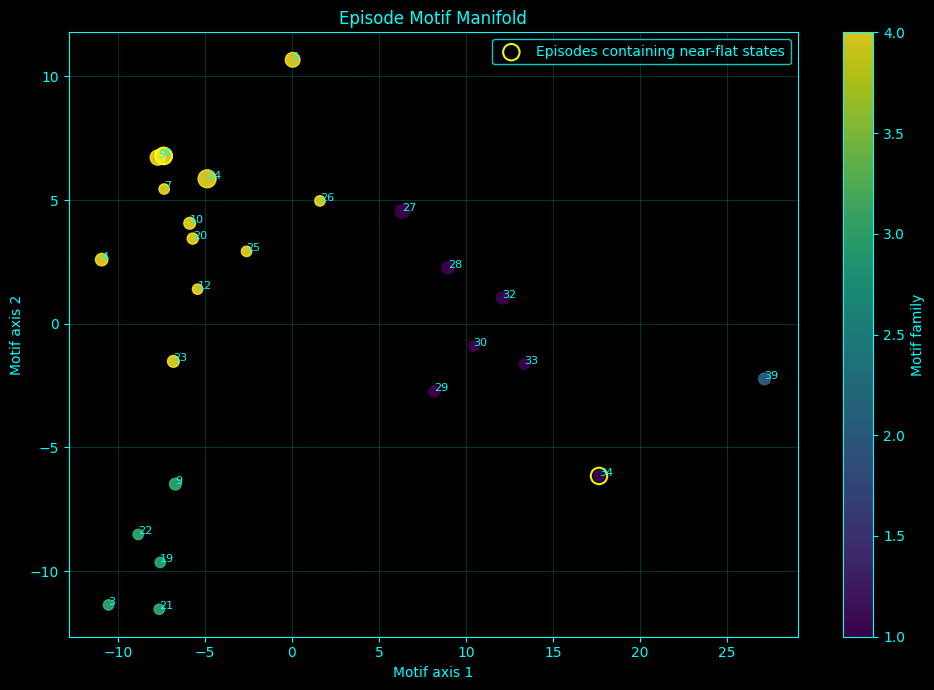

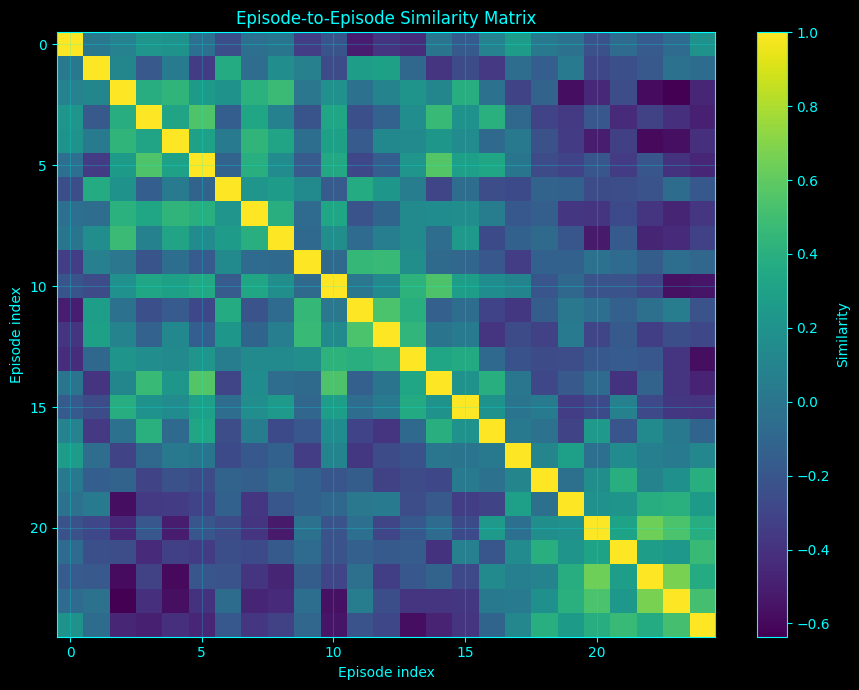

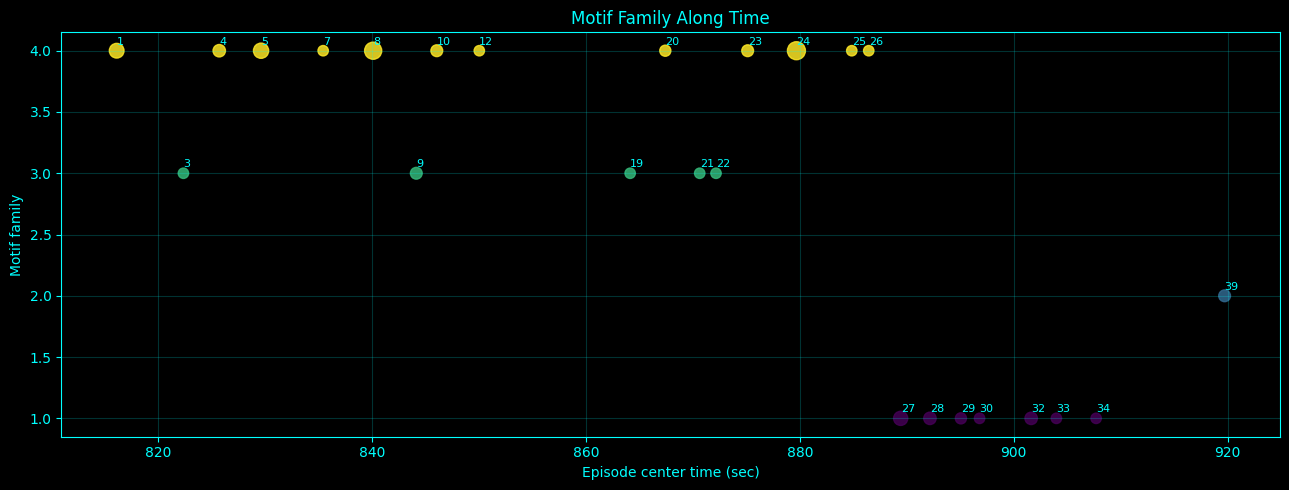

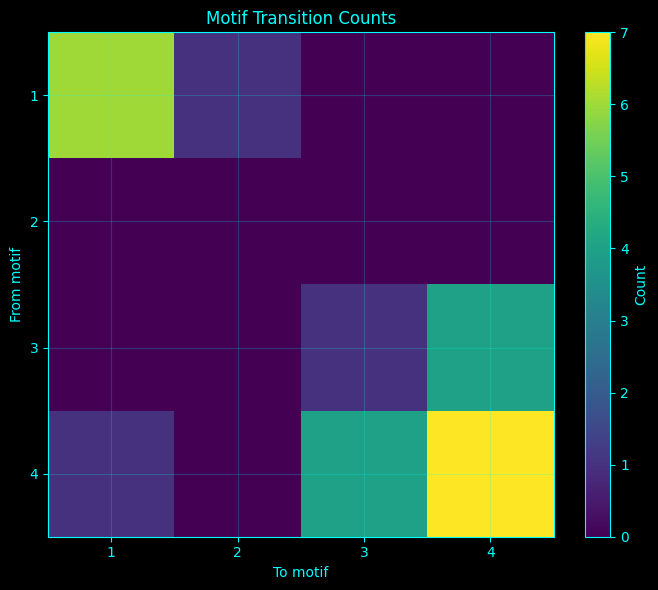

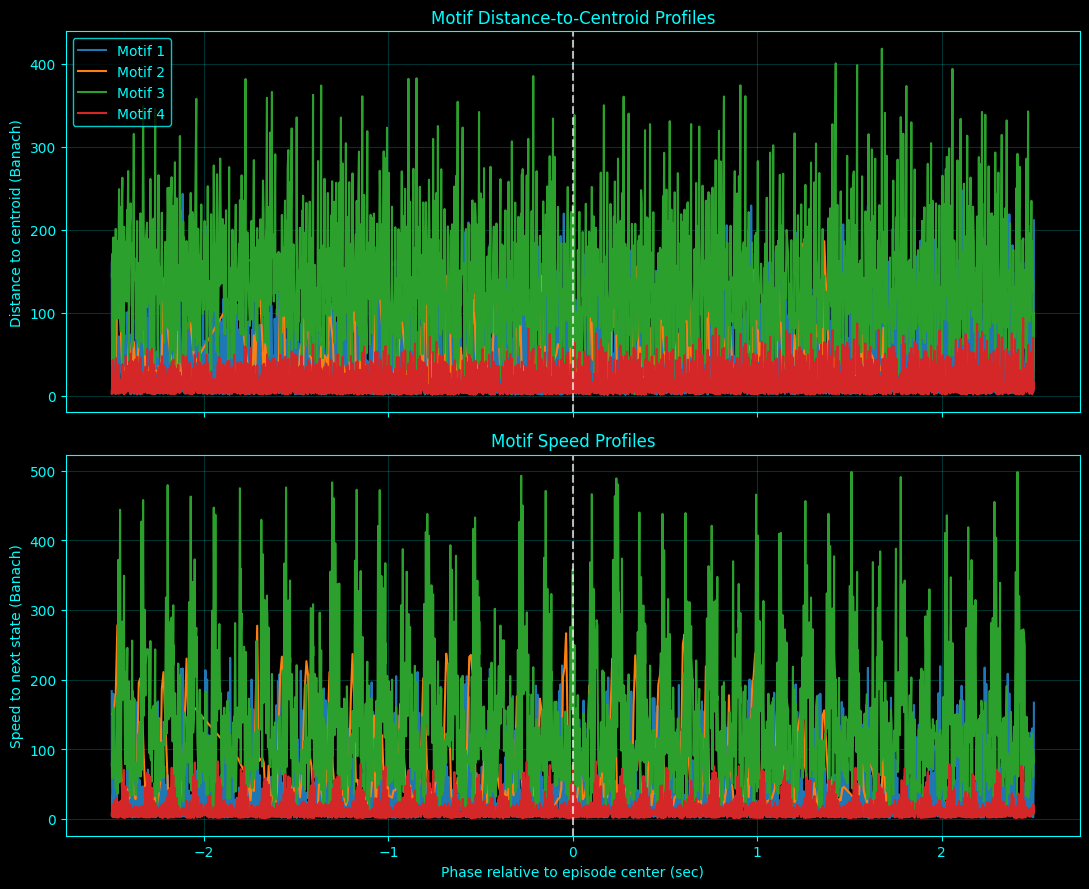

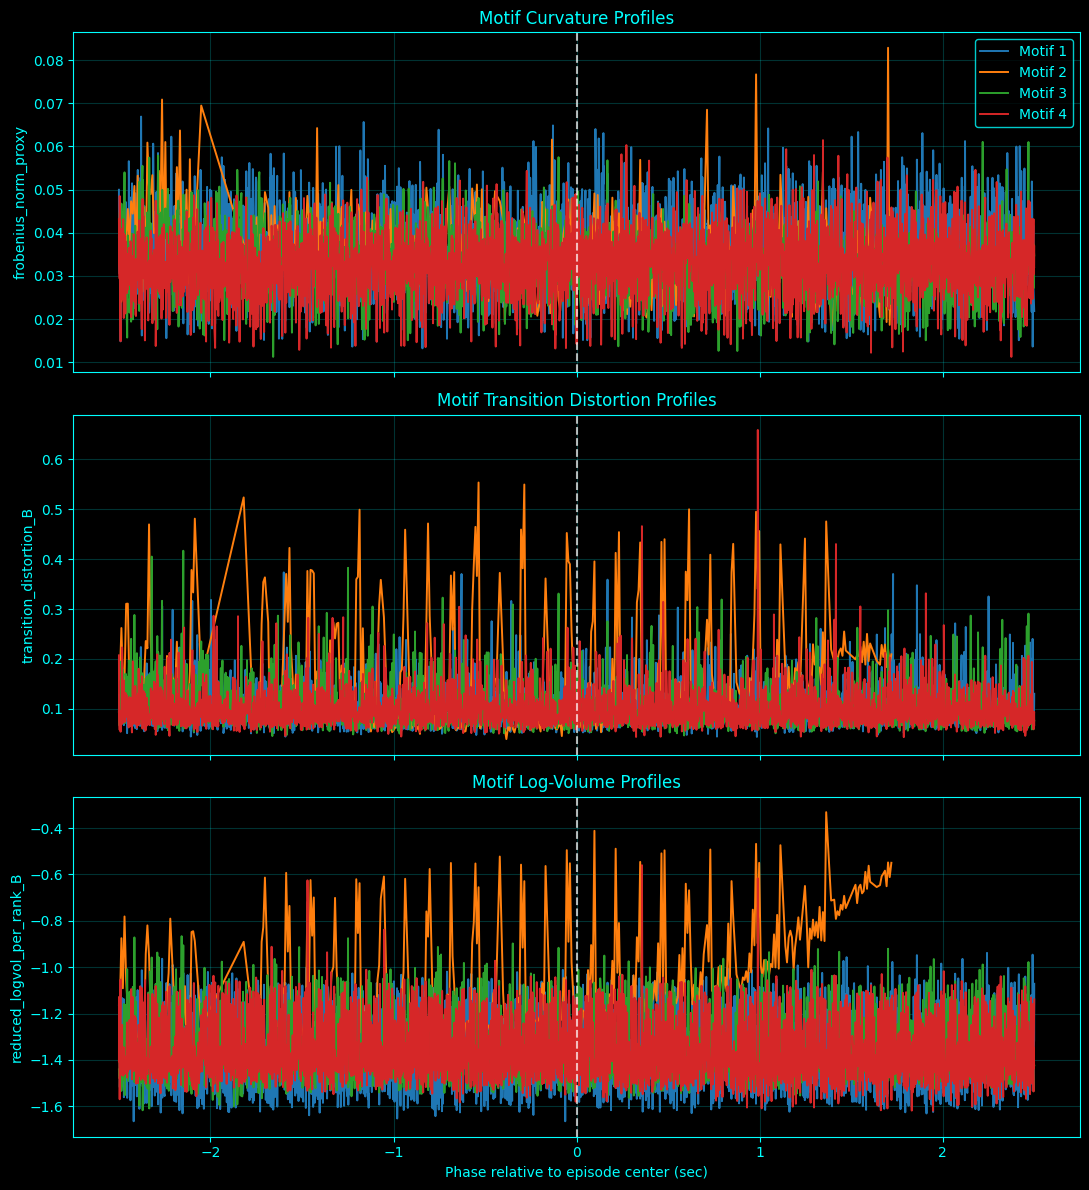

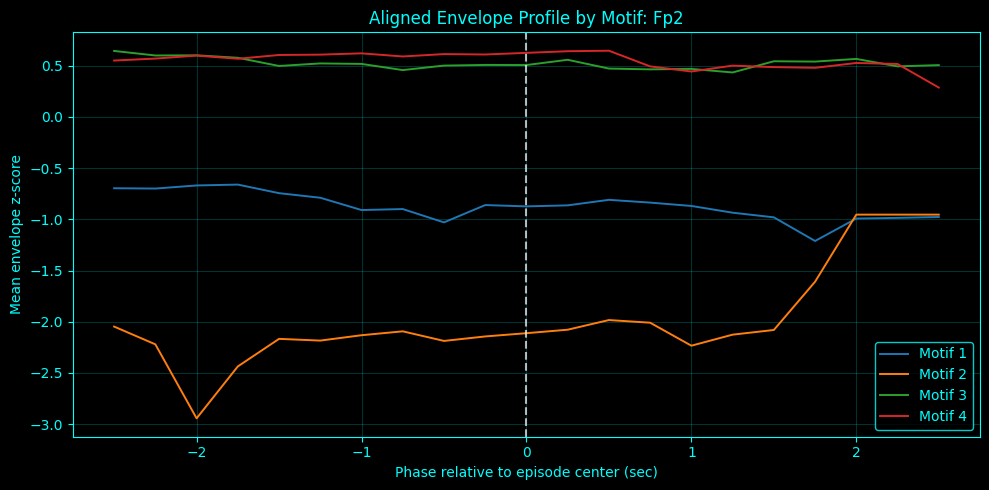

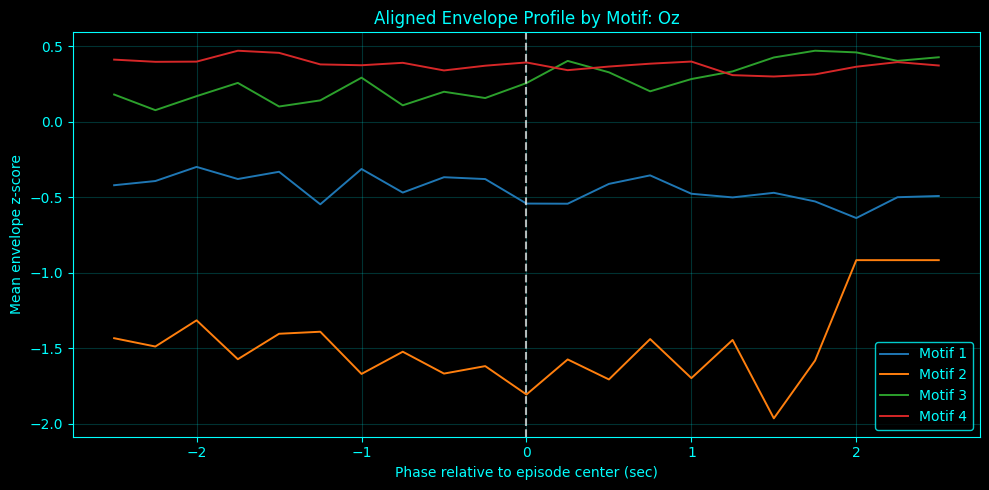

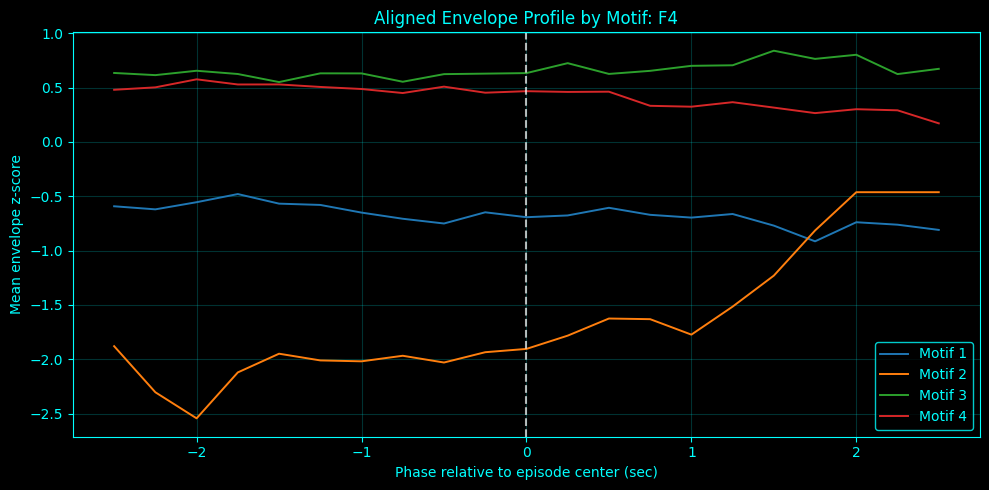

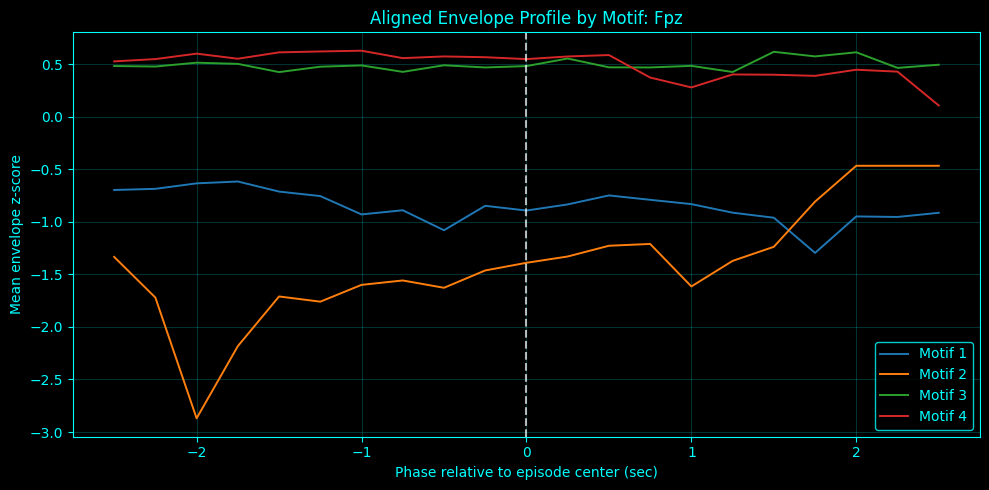

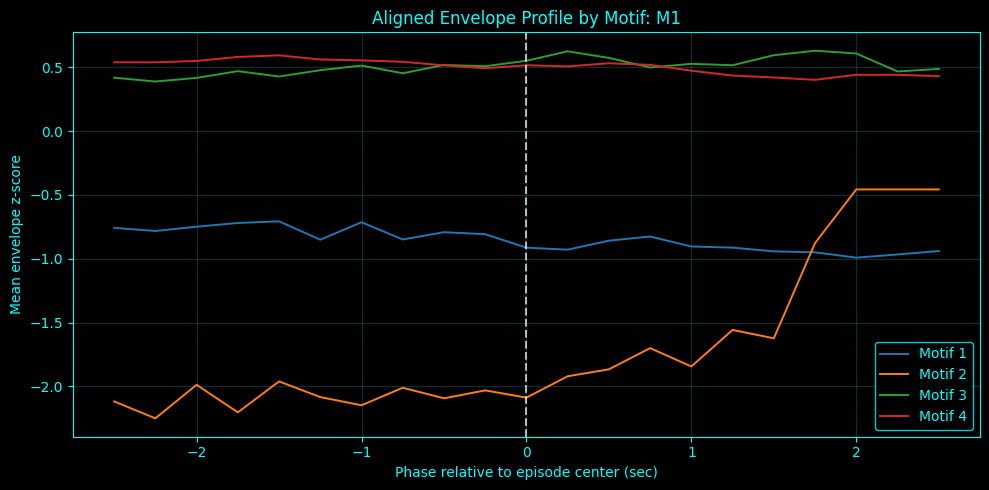

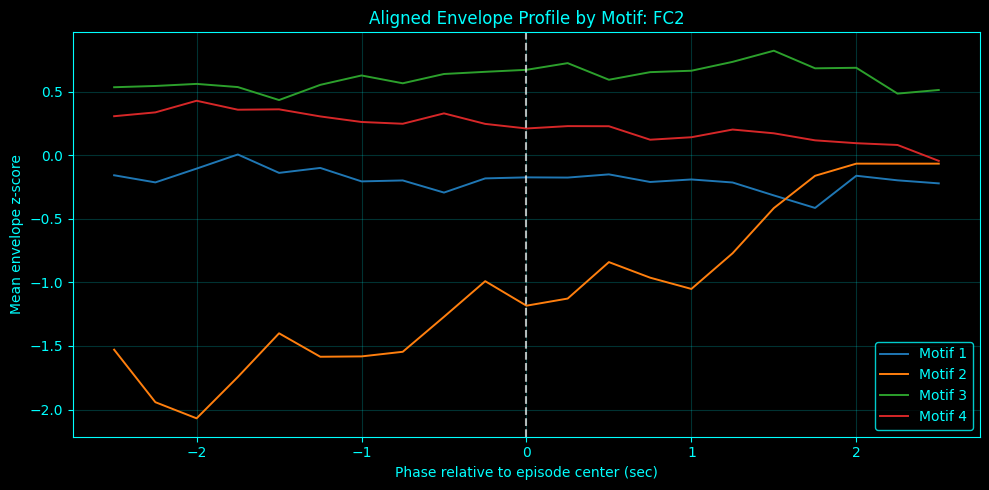


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/episode_motif_features.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/episode_similarity_matrix.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/motif_transition_counts.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/motif_phase_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/motif_channel_phase_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/episode_motif_manifold_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/episode_motif_manifold_v1/plots

Quick summary:
Motif counts:
motif_id
1     7
2     1
3     5
4    12

Episodes sorted by time:
 episode_id  center_time_sec  n_stable_states old_episode_shape  motif_id  has_near_flat  contraction_score  release_score  center

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")
atlas_dir = os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1")

episodes_csv = os.path.join(atlas_dir, "episode_corridor_atlas.csv")
corridor_csv = os.path.join(atlas_dir, "episode_centered_corridor_states.csv")
near_flat_context_csv = os.path.join(atlas_dir, "near_flat_episode_context.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

out_dir = os.path.join(base_dir, "results", "episode_motif_manifold_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

phase_window_sec = 2.5
phase_bin_sec = 0.25
top_k_channels = 6
env_smooth_sec = 0.150

# exploratory motif settings
n_motifs = 4
eps = 1e-12

ACCENT = "cyan"
BG = "black"

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def zscore_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    return (X - mu) / (sd + eps)

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def interp_profile(bin_centers, x, y):
    """
    Interpolate profile values y(x) onto bin_centers.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) == 0:
        return np.full(len(bin_centers), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(np.unique(x)) == 1:
        return np.full(len(bin_centers), y[0])

    return np.interp(bin_centers, x, y, left=y[0], right=y[-1])

def band_mean(bin_centers, profile, lo, hi):
    m = (bin_centers >= lo) & (bin_centers <= hi)
    return safe_mean(profile[m])

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
episodes_df = pd.read_csv(episodes_csv).sort_values("center_time_sec").reset_index(drop=True)
corridor_df = pd.read_csv(corridor_csv).sort_values(["episode_id", "phase_sec"]).reset_index(drop=True)

if os.path.exists(near_flat_context_csv):
    near_flat_context_df = pd.read_csv(near_flat_context_csv)
else:
    near_flat_context_df = pd.DataFrame()

channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
    "cohen_d_stable_vs_nonstable", ascending=False
).reset_index(drop=True)

if len(episodes_df) == 0:
    raise RuntimeError("No episodes found.")

phase_bins = np.arange(-phase_window_sec, phase_window_sec + phase_bin_sec, phase_bin_sec)

# top exploratory channels
top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]

print("Top channels used for motif manifold:", top_channels)

# -------------------------------------------------------
# LOAD EEG FOR PER-EPISODE CHANNEL PROFILES
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]
time_sec = start_time + np.arange(len(EEG_segment)) * dt

analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)

smooth_w = int(env_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([
    moving_average(env_z[:, ch], smooth_w) for ch in range(env_z.shape[1])
])

# -------------------------------------------------------
# BUILD PER-EPISODE MOTIF VECTORS
# -------------------------------------------------------
episode_feature_rows = []
episode_channel_rows = []

for _, ep in episodes_df.iterrows():
    episode_id = int(ep["episode_id"])
    center_t = float(ep["center_time_sec"])
    sub = corridor_df[corridor_df["episode_id"] == episode_id].copy()

    if len(sub) == 0:
        continue

    # geometric profiles
    dist_prof = interp_profile(phase_bins, sub["phase_sec"].values, sub["dist_to_centroid_B"].values)
    speed_prof = interp_profile(phase_bins, sub["phase_sec"].values, sub["speed_to_next_B"].values)
    frob_prof = interp_profile(phase_bins, sub["phase_sec"].values, sub["frobenius_norm_proxy"].values)
    lap_prof = interp_profile(phase_bins, sub["phase_sec"].values, np.abs(sub["laplacian_norm_proxy"].values))
    distor_prof = interp_profile(phase_bins, sub["phase_sec"].values, sub["transition_distortion_B"].values)
    logvol_prof = interp_profile(phase_bins, sub["phase_sec"].values, sub["reduced_logvol_per_rank_B"].values)

    # summary motif scores
    pre_dist = band_mean(phase_bins, dist_prof, -1.5, -0.5)
    ctr_dist = band_mean(phase_bins, dist_prof, -0.25, 0.25)
    post_dist = band_mean(phase_bins, dist_prof, 0.5, 1.5)

    pre_speed = band_mean(phase_bins, speed_prof, -1.5, -0.5)
    ctr_speed = band_mean(phase_bins, speed_prof, -0.25, 0.25)
    post_speed = band_mean(phase_bins, speed_prof, 0.5, 1.5)

    pre_logvol = band_mean(phase_bins, logvol_prof, -1.5, -0.5)
    ctr_logvol = band_mean(phase_bins, logvol_prof, -0.25, 0.25)
    post_logvol = band_mean(phase_bins, logvol_prof, 0.5, 1.5)

    contraction_score = (pre_dist - ctr_dist) / (abs(pre_dist) + eps)
    release_score = (post_dist - ctr_dist) / (abs(ctr_dist) + eps)
    center_slowing_score = (pre_speed + post_speed - 2.0 * ctr_speed) / (abs(pre_speed) + abs(post_speed) + eps)
    logvol_lift_score = (ctr_logvol - pre_logvol)
    post_logvol_shift = (post_logvol - ctr_logvol)

    # aligned channel profiles around center
    sample_mask = (
        (time_sec >= center_t - phase_window_sec) &
        (time_sec <= center_t + phase_window_sec)
    )
    phase_samples = time_sec[sample_mask] - center_t

    channel_feature_vector = []
    for ch_idx, ch_name in zip(top_channel_idx, top_channels):
        prof = interp_profile(phase_bins, phase_samples, env_z_smooth[sample_mask, ch_idx])
        channel_feature_vector.extend(prof.tolist())

        # keep long-form rows too
        for p, v in zip(phase_bins, prof):
            episode_channel_rows.append({
                "episode_id": episode_id,
                "episode_shape": ep["episode_shape"],
                "channel": ch_name,
                "phase_sec": float(p),
                "mean_env_z": float(v),
            })

    # flattened motif vector
    geom_vector = np.concatenate([
        dist_prof, speed_prof, frob_prof, lap_prof, distor_prof, logvol_prof
    ])

    feature_vector = np.concatenate([
        geom_vector,
        np.array([
            contraction_score,
            release_score,
            center_slowing_score,
            logvol_lift_score,
            post_logvol_shift
        ], dtype=float),
        np.array(channel_feature_vector, dtype=float)
    ])

    row = {
        "episode_id": episode_id,
        "start_time_sec": float(ep["start_time_sec"]),
        "end_time_sec": float(ep["end_time_sec"]),
        "center_time_sec": float(center_t),
        "duration_sec": float(ep["duration_sec"]),
        "n_stable_states": int(ep["n_stable_states"]),
        "n_near_flat_states": int(ep["n_near_flat_states"]),
        "dominant_signature": ep["dominant_signature"],
        "old_episode_shape": ep["episode_shape"],
        "contraction_score": float(contraction_score),
        "release_score": float(release_score),
        "center_slowing_score": float(center_slowing_score),
        "logvol_lift_score": float(logvol_lift_score),
        "post_logvol_shift": float(post_logvol_shift),
    }

    for j, v in enumerate(feature_vector):
        row[f"feat_{j:03d}"] = float(v)

    episode_feature_rows.append(row)

episode_feature_df = pd.DataFrame(episode_feature_rows).sort_values("center_time_sec").reset_index(drop=True)
episode_channel_df = pd.DataFrame(episode_channel_rows)

feat_cols = [c for c in episode_feature_df.columns if c.startswith("feat_")]
X = episode_feature_df[feat_cols].values
Xz = zscore_columns(X)

# -------------------------------------------------------
# SIMILARITY / EMBEDDING / CLUSTERING
# -------------------------------------------------------
# Correlation distance between episodes
dist_vec = pdist(Xz, metric="correlation")
dist_mat = squareform(dist_vec)
sim_mat = 1.0 - dist_mat

# Hierarchical clustering
Z = linkage(Xz, method="ward")
motif_labels = fcluster(Z, t=n_motifs, criterion="maxclust")
episode_feature_df["motif_id"] = motif_labels

# 2D motif manifold embedding via PCA on the episode feature matrix
motif_xy, motif_eigs, _ = pca_2d(Xz)
episode_feature_df["motif_x"] = motif_xy[:, 0]
episode_feature_df["motif_y"] = motif_xy[:, 1]

# mark near-flat episodes
near_flat_episode_ids = set(
    near_flat_context_df["episode_id"].dropna().astype(int).tolist()
) if len(near_flat_context_df) else set()
episode_feature_df["has_near_flat"] = episode_feature_df["episode_id"].isin(near_flat_episode_ids).astype(int)

# motif transition counts along time
episode_feature_df = episode_feature_df.sort_values("center_time_sec").reset_index(drop=True)
transition_rows = []
for i in range(len(episode_feature_df) - 1):
    a = int(episode_feature_df.loc[i, "motif_id"])
    b = int(episode_feature_df.loc[i + 1, "motif_id"])
    transition_rows.append({"from_motif": a, "to_motif": b})

transition_df = pd.DataFrame(transition_rows)
if len(transition_df) > 0:
    motif_transition_counts = transition_df.value_counts().reset_index(name="count")
else:
    motif_transition_counts = pd.DataFrame(columns=["from_motif", "to_motif", "count"])

# aggregated profiles by motif
motif_profiles = []

for motif_id in sorted(episode_feature_df["motif_id"].unique()):
    motif_episode_ids = episode_feature_df.loc[episode_feature_df["motif_id"] == motif_id, "episode_id"].tolist()
    sub = corridor_df[corridor_df["episode_id"].isin(motif_episode_ids)].copy()

    for p in sorted(sub["phase_sec"].unique()):
        phase_sub = sub[sub["phase_sec"] == p]
        motif_profiles.append({
            "motif_id": int(motif_id),
            "phase_sec": float(p),
            "dist_to_centroid_B": safe_mean(phase_sub["dist_to_centroid_B"].values),
            "speed_to_next_B": safe_mean(phase_sub["speed_to_next_B"].values),
            "frobenius_norm_proxy": safe_mean(phase_sub["frobenius_norm_proxy"].values),
            "abs_laplacian_norm_proxy": safe_mean(np.abs(phase_sub["laplacian_norm_proxy"].values)),
            "transition_distortion_B": safe_mean(phase_sub["transition_distortion_B"].values),
            "reduced_logvol_per_rank_B": safe_mean(phase_sub["reduced_logvol_per_rank_B"].values),
        })

motif_profile_df = pd.DataFrame(motif_profiles)

# aggregated aligned channel profiles by motif
motif_channel_profiles = []
for motif_id in sorted(episode_feature_df["motif_id"].unique()):
    motif_episode_ids = episode_feature_df.loc[episode_feature_df["motif_id"] == motif_id, "episode_id"].tolist()
    sub = episode_channel_df[episode_channel_df["episode_id"].isin(motif_episode_ids)].copy()
    if len(sub) == 0:
        continue

    grp = sub.groupby(["motif_id" if "motif_id" in sub.columns else "channel", "channel", "phase_sec"], as_index=False)

# attach motif ids to long-form channel rows
episode_to_motif = dict(zip(episode_feature_df["episode_id"], episode_feature_df["motif_id"]))
episode_channel_df["motif_id"] = episode_channel_df["episode_id"].map(episode_to_motif)

motif_channel_profile_df = episode_channel_df.groupby(
    ["motif_id", "channel", "phase_sec"], as_index=False
)["mean_env_z"].mean()

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
episode_feature_csv = os.path.join(out_dir, "episode_motif_features.csv")
similarity_csv = os.path.join(out_dir, "episode_similarity_matrix.csv")
transition_csv = os.path.join(out_dir, "motif_transition_counts.csv")
motif_profile_csv = os.path.join(out_dir, "motif_phase_profiles.csv")
motif_channel_csv = os.path.join(out_dir, "motif_channel_phase_profiles.csv")
summary_txt = os.path.join(out_dir, "episode_motif_manifold_summary.txt")

episode_feature_df.to_csv(episode_feature_csv, index=False)
pd.DataFrame(sim_mat, index=episode_feature_df["episode_id"], columns=episode_feature_df["episode_id"]).to_csv(similarity_csv)
motif_transition_counts.to_csv(transition_csv, index=False)
motif_profile_df.to_csv(motif_profile_csv, index=False)
motif_channel_profile_df.to_csv(motif_channel_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Episode Motif Manifold Summary\n")
    f.write("=============================\n\n")
    f.write(f"Episodes: {len(episode_feature_df)}\n")
    f.write(f"Motif families requested: {n_motifs}\n")
    f.write(f"Top channels used: {top_channels}\n\n")

    f.write("Motif counts:\n")
    f.write(episode_feature_df["motif_id"].value_counts().sort_index().to_string())
    f.write("\n\n")

    f.write("Episodes in motif order:\n")
    f.write(
        episode_feature_df[[
            "episode_id", "center_time_sec", "duration_sec", "n_stable_states",
            "old_episode_shape", "motif_id", "has_near_flat",
            "contraction_score", "release_score", "center_slowing_score",
            "logvol_lift_score", "post_logvol_shift"
        ]].to_string(index=False)
    )
    f.write("\n\n")

    if len(motif_transition_counts) > 0:
        f.write("Motif transition counts:\n")
        f.write(motif_transition_counts.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Episode motif manifold
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    episode_feature_df["motif_x"].values,
    episode_feature_df["motif_y"].values,
    c=episode_feature_df["motif_id"].values,
    s=40 + 8 * episode_feature_df["n_stable_states"].values,
    alpha=0.85
)

for _, row in episode_feature_df.iterrows():
    ax.text(row["motif_x"], row["motif_y"], str(int(row["episode_id"])), fontsize=8)

nf_mask = episode_feature_df["has_near_flat"].values.astype(bool)
if np.any(nf_mask):
    ax.scatter(
        episode_feature_df.loc[nf_mask, "motif_x"].values,
        episode_feature_df.loc[nf_mask, "motif_y"].values,
        s=140,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95,
        label="Episodes containing near-flat states"
    )
    ax.legend()

ax.set_title("Episode Motif Manifold")
ax.set_xlabel("Motif axis 1")
ax.set_ylabel("Motif axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Motif family")

plot1_path = os.path.join(plots_dir, "episode_motif_manifold.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Episode similarity matrix
fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(sim_mat, aspect="auto")
ax.set_title("Episode-to-Episode Similarity Matrix")
ax.set_xlabel("Episode index")
ax.set_ylabel("Episode index")

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Similarity")

plot2_path = os.path.join(plots_dir, "episode_similarity_matrix.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Motif family over time
fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
style_ax(ax)

ax.scatter(
    episode_feature_df["center_time_sec"].values,
    episode_feature_df["motif_id"].values,
    s=40 + 8 * episode_feature_df["n_stable_states"].values,
    c=episode_feature_df["motif_id"].values,
    alpha=0.85
)

for _, row in episode_feature_df.iterrows():
    ax.text(row["center_time_sec"], row["motif_id"] + 0.05, str(int(row["episode_id"])), fontsize=8)

ax.set_title("Motif Family Along Time")
ax.set_xlabel("Episode center time (sec)")
ax.set_ylabel("Motif family")

plot3_path = os.path.join(plots_dir, "motif_family_timeline.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Motif transition heatmap
motifs = sorted(episode_feature_df["motif_id"].unique())
motif_to_idx = {m: i for i, m in enumerate(motifs)}
T = np.zeros((len(motifs), len(motifs)), dtype=float)
for _, row in motif_transition_counts.iterrows():
    T[motif_to_idx[int(row["from_motif"])], motif_to_idx[int(row["to_motif"])]] = row["count"]

fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(T, aspect="auto")
ax.set_xticks(np.arange(len(motifs)))
ax.set_yticks(np.arange(len(motifs)))
ax.set_xticklabels(motifs)
ax.set_yticklabels(motifs)
ax.set_title("Motif Transition Counts")
ax.set_xlabel("To motif")
ax.set_ylabel("From motif")

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Count")

plot4_path = os.path.join(plots_dir, "motif_transition_counts.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Phase profiles by motif: distance and speed
fig, axes = plt.subplots(2, 1, figsize=(11, 9), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

for motif_id in motifs:
    sub = motif_profile_df[motif_profile_df["motif_id"] == motif_id]
    ax1.plot(sub["phase_sec"].values, sub["dist_to_centroid_B"].values, linewidth=1.5, label=f"Motif {motif_id}")
    ax2.plot(sub["phase_sec"].values, sub["speed_to_next_B"].values, linewidth=1.5, label=f"Motif {motif_id}")

ax1.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax2.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax1.set_title("Motif Distance-to-Centroid Profiles")
ax1.set_ylabel("Distance to centroid (Banach)")
ax2.set_title("Motif Speed Profiles")
ax2.set_xlabel("Phase relative to episode center (sec)")
ax2.set_ylabel("Speed to next state (Banach)")
ax1.legend()

plot5_path = os.path.join(plots_dir, "motif_distance_speed_profiles.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Phase profiles by motif: curvature/distortion/log-volume
fig, axes = plt.subplots(3, 1, figsize=(11, 12), facecolor=BG, sharex=True)
ax1, ax2, ax3 = axes
style_ax(ax1); style_ax(ax2); style_ax(ax3)

for motif_id in motifs:
    sub = motif_profile_df[motif_profile_df["motif_id"] == motif_id]
    ax1.plot(sub["phase_sec"].values, sub["frobenius_norm_proxy"].values, linewidth=1.4, label=f"Motif {motif_id}")
    ax2.plot(sub["phase_sec"].values, sub["transition_distortion_B"].values, linewidth=1.4, label=f"Motif {motif_id}")
    ax3.plot(sub["phase_sec"].values, sub["reduced_logvol_per_rank_B"].values, linewidth=1.4, label=f"Motif {motif_id}")

ax1.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax2.axvline(0.0, color="white", linestyle="--", alpha=0.7)
ax3.axvline(0.0, color="white", linestyle="--", alpha=0.7)

ax1.set_title("Motif Curvature Profiles")
ax1.set_ylabel("frobenius_norm_proxy")
ax2.set_title("Motif Transition Distortion Profiles")
ax2.set_ylabel("transition_distortion_B")
ax3.set_title("Motif Log-Volume Profiles")
ax3.set_xlabel("Phase relative to episode center (sec)")
ax3.set_ylabel("reduced_logvol_per_rank_B")
ax1.legend()

plot6_path = os.path.join(plots_dir, "motif_curvature_distortion_logvol_profiles.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top-channel aligned profiles by motif
for ch_name in top_channels:
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    for motif_id in motifs:
        sub = motif_channel_profile_df[
            (motif_channel_profile_df["channel"] == ch_name) &
            (motif_channel_profile_df["motif_id"] == motif_id)
        ]
        if len(sub) == 0:
            continue
        ax.plot(sub["phase_sec"].values, sub["mean_env_z"].values, linewidth=1.4, label=f"Motif {motif_id}")

    ax.axvline(0.0, color="white", linestyle="--", alpha=0.7)
    ax.set_title(f"Aligned Envelope Profile by Motif: {ch_name}")
    ax.set_xlabel("Phase relative to episode center (sec)")
    ax.set_ylabel("Mean envelope z-score")
    ax.legend()

    plot_path = os.path.join(plots_dir, f"channel_profile_by_motif_{ch_name}.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

print("\nSaved:")
print(episode_feature_csv)
print(similarity_csv)
print(transition_csv)
print(motif_profile_csv)
print(motif_channel_csv)
print(summary_txt)
print(plots_dir)

print("\nQuick summary:")
print("Motif counts:")
print(episode_feature_df["motif_id"].value_counts().sort_index().to_string())

print("\nEpisodes sorted by time:")
print(
    episode_feature_df[[
        "episode_id", "center_time_sec", "n_stable_states",
        "old_episode_shape", "motif_id", "has_near_flat",
        "contraction_score", "release_score", "center_slowing_score"
    ]].to_string(index=False)
)

if len(near_flat_context_df) > 0:
    print("\nNear-flat context:")
    print(near_flat_context_df.to_string(index=False))

Top channels: ['Fp2', 'Oz', 'F4', 'Fpz', 'M1', 'FC2']


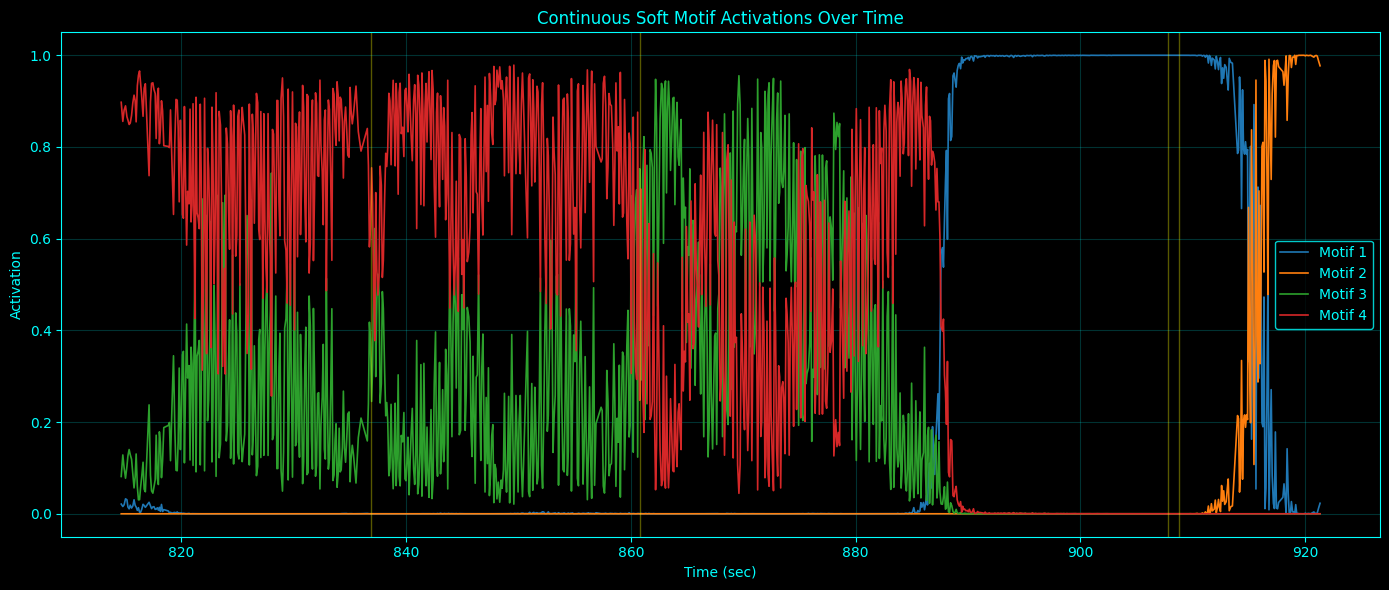

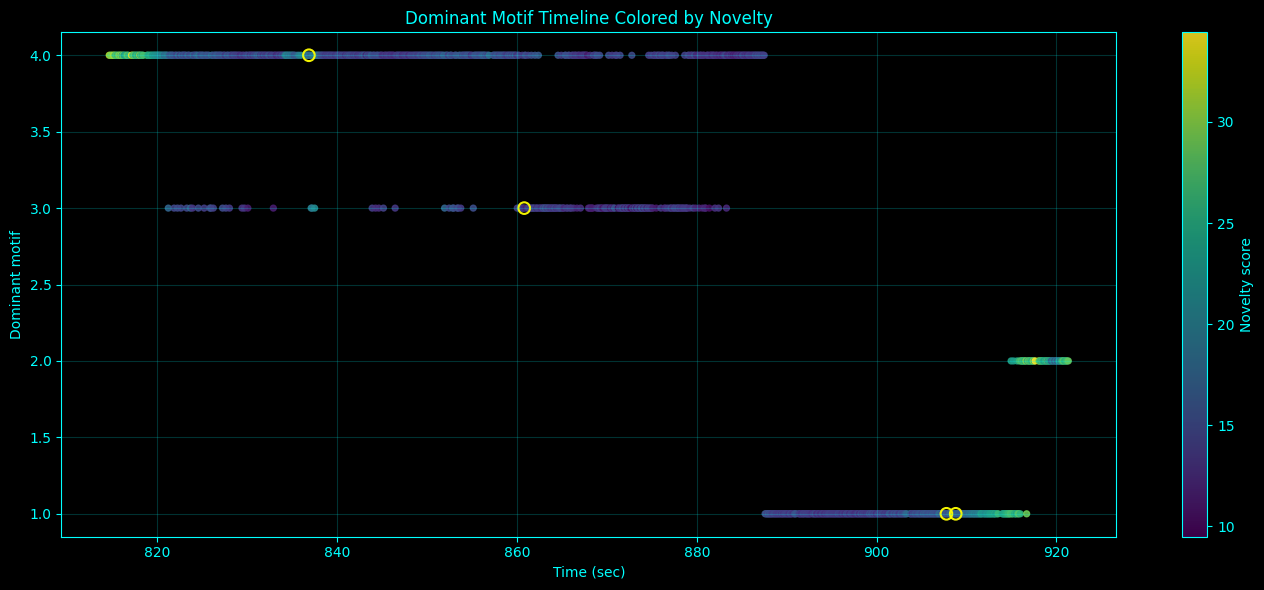

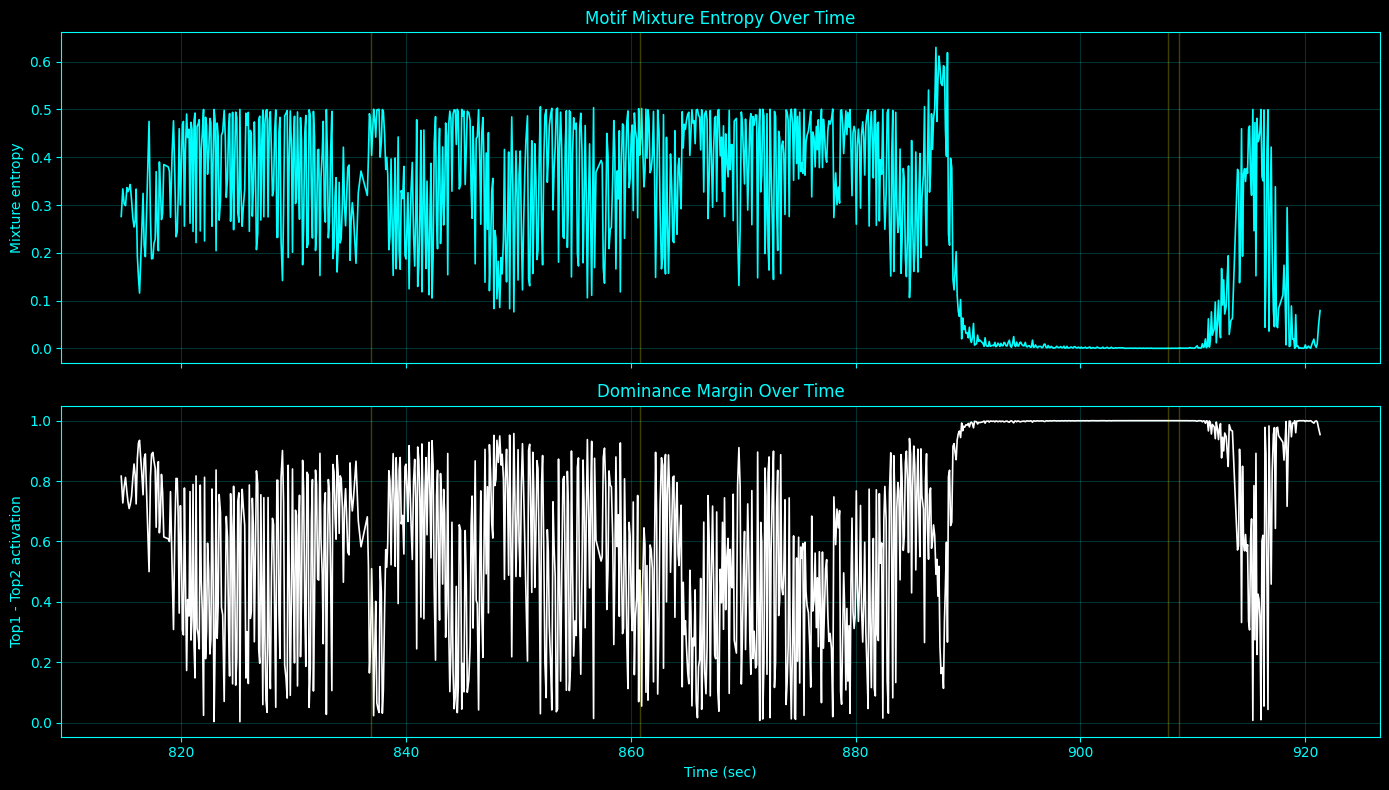

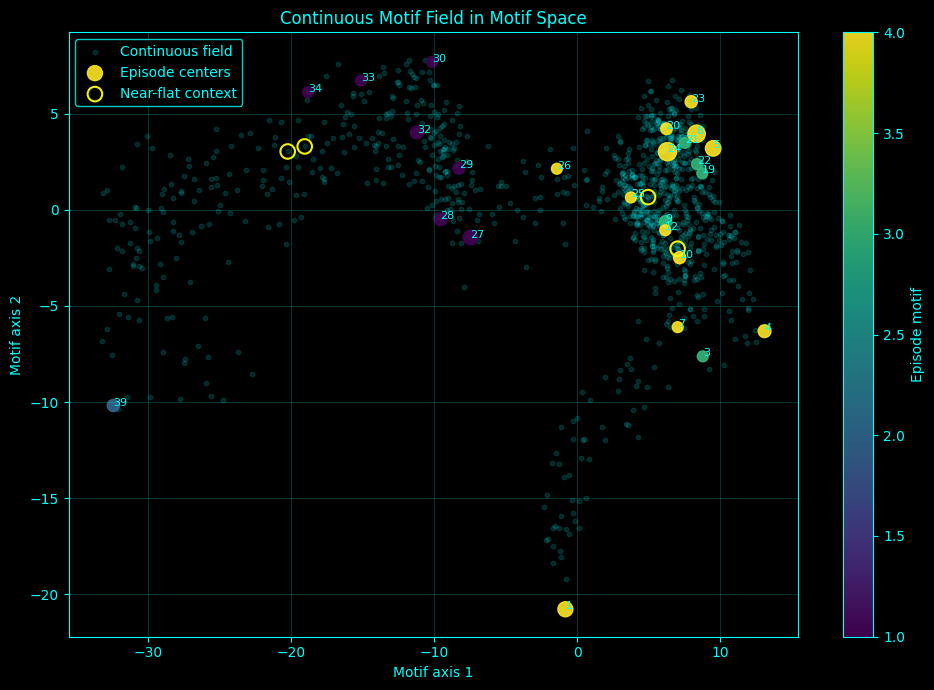

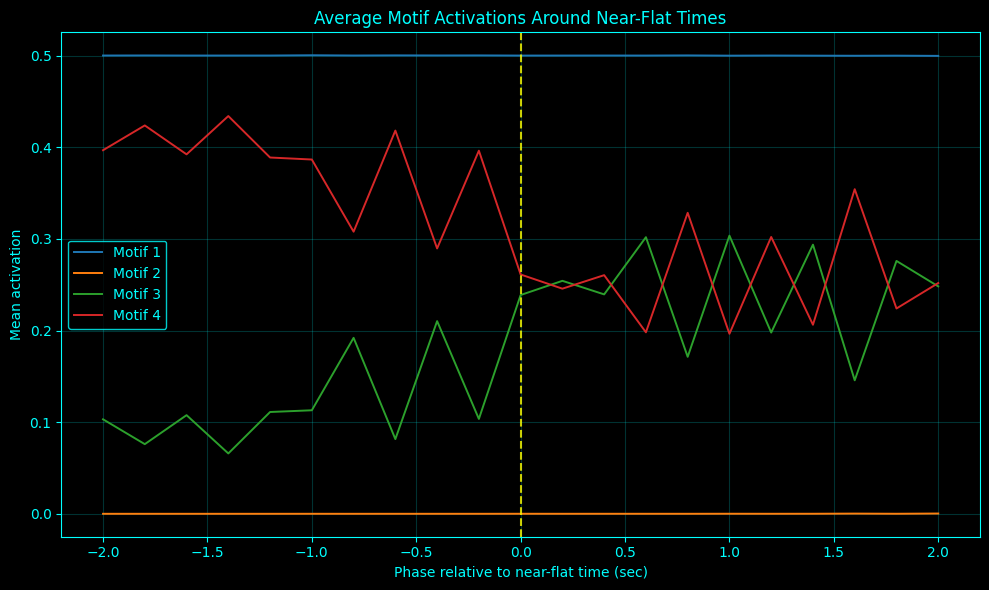


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/continuous_motif_field.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/motif_prototypes_from_window_descriptors.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/episode_center_window_descriptors.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/near_flat_soft_motif_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/near_flat_motif_precursor_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/continuous_motif_field_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/plots

Saved plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/continuous_motif_field_v1/plots/continuous_motif_activations.png
/home/a/projects/Complete-Neural-Signal-Analysis/res

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

motif_dir = os.path.join(base_dir, "results", "episode_motif_manifold_v1")
geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")

episode_feature_csv = os.path.join(motif_dir, "episode_motif_features.csv")
all_local_csv = os.path.join(geom_dir, "local_chart_curvature_all_states.csv")
near_flat_context_csv = os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1", "near_flat_episode_context.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

out_dir = os.path.join(base_dir, "results", "continuous_motif_field_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# sliding descriptor controls
field_stride = 10              # every 10th kept state center
phase_window_sec = 2.0
phase_bin_sec = 0.20
top_k_channels = 6
env_smooth_sec = 0.150

# soft assignment controls
softmax_temperature = 1.0

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def interp_profile(bin_centers, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) == 0:
        return np.full(len(bin_centers), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(np.unique(x)) == 1:
        return np.full(len(bin_centers), y[0])

    return np.interp(bin_centers, x, y, left=y[0], right=y[-1])

def zscore_with_ref(X, mu, sd):
    return (X - mu) / (sd + eps)

def softmax_negdist(d, temperature=1.0):
    d = np.asarray(d, dtype=float)
    z = -d / max(temperature, eps)
    z = z - np.max(z)
    p = np.exp(z)
    return p / (np.sum(p) + eps)

def entropy01(p):
    p = np.asarray(p, dtype=float)
    p = p / (np.sum(p) + eps)
    h = -np.sum(p * np.log(p + eps))
    return float(h / (np.log(len(p) + eps) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
episode_feature_df = pd.read_csv(episode_feature_csv).sort_values("center_time_sec").reset_index(drop=True)
all_local_df = pd.read_csv(all_local_csv).sort_values("time_sec").reset_index(drop=True)

if os.path.exists(near_flat_context_csv):
    near_flat_context_df = pd.read_csv(near_flat_context_csv)
else:
    near_flat_context_df = pd.DataFrame()

if os.path.exists(channel_contrast_csv):
    channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
        "cohen_d_stable_vs_nonstable", ascending=False
    ).reset_index(drop=True)
    top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
else:
    top_channels = ["Fp2", "Oz", "F4", "Fpz", "M1", "FC2"]

top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]
print("Top channels:", top_channels)

all_local_df["abs_laplacian_norm_proxy"] = np.abs(all_local_df["laplacian_norm_proxy"].values)

# -------------------------------------------------------
# LOAD EEG FOR CHANNEL DESCRIPTORS
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)

smooth_w = int(env_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([
    moving_average(env_z[:, ch], smooth_w) for ch in range(env_z.shape[1])
])

sample_time = start_time + np.arange(len(EEG_segment)) * dt

# -------------------------------------------------------
# BUILD COMPARABLE WINDOW DESCRIPTORS
# -------------------------------------------------------
phase_bins = np.arange(-phase_window_sec, phase_window_sec + phase_bin_sec, phase_bin_sec)

state_metric_cols = [
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
]

def build_window_descriptor(center_t):
    # state-level profiles
    sub = all_local_df[
        (all_local_df["time_sec"] >= center_t - phase_window_sec) &
        (all_local_df["time_sec"] <= center_t + phase_window_sec)
    ].copy()

    if len(sub) < 5:
        return None

    phase_state = sub["time_sec"].values - center_t

    desc_parts = []
    summary_parts = []

    for col in state_metric_cols:
        prof = interp_profile(phase_bins, phase_state, sub[col].values)
        desc_parts.append(prof)

        pre = safe_mean(prof[(phase_bins >= -1.5) & (phase_bins <= -0.5)])
        ctr = safe_mean(prof[(phase_bins >= -0.25) & (phase_bins <= 0.25)])
        post = safe_mean(prof[(phase_bins >= 0.5) & (phase_bins <= 1.5)])

        summary_parts.extend([
            pre,
            ctr,
            post,
            ctr - pre,
            post - ctr
        ])

    # channel profiles
    sample_mask = (
        (sample_time >= center_t - phase_window_sec) &
        (sample_time <= center_t + phase_window_sec)
    )

    if not np.any(sample_mask):
        return None

    phase_sample = sample_time[sample_mask] - center_t
    for ch_idx in top_channel_idx:
        prof = interp_profile(phase_bins, phase_sample, env_z_smooth[sample_mask, ch_idx])
        desc_parts.append(prof)

        pre = safe_mean(prof[(phase_bins >= -1.5) & (phase_bins <= -0.5)])
        ctr = safe_mean(prof[(phase_bins >= -0.25) & (phase_bins <= 0.25)])
        post = safe_mean(prof[(phase_bins >= 0.5) & (phase_bins <= 1.5)])

        summary_parts.extend([
            pre,
            ctr,
            post,
            ctr - pre,
            post - ctr
        ])

    descriptor = np.concatenate(desc_parts + [np.asarray(summary_parts, dtype=float)])
    return descriptor

# -------------------------------------------------------
# EPISODE-CENTER DESCRIPTORS FOR MOTIF PROTOTYPES
# -------------------------------------------------------
ep_desc_rows = []

for _, row in episode_feature_df.iterrows():
    center_t = float(row["center_time_sec"])
    d = build_window_descriptor(center_t)
    if d is None:
        continue

    out = {
        "episode_id": int(row["episode_id"]),
        "center_time_sec": center_t,
        "motif_id": int(row["motif_id"]),
        "has_near_flat": int(row["has_near_flat"]),
        "n_stable_states": int(row["n_stable_states"]),
    }
    for i, v in enumerate(d):
        out[f"d_{i:03d}"] = float(v)
    ep_desc_rows.append(out)

ep_desc_df = pd.DataFrame(ep_desc_rows).sort_values("center_time_sec").reset_index(drop=True)

desc_cols = [c for c in ep_desc_df.columns if c.startswith("d_")]
X_ep = ep_desc_df[desc_cols].values

mu = np.nanmean(X_ep, axis=0, keepdims=True)
sd = np.nanstd(X_ep, axis=0, keepdims=True)
X_ep_z = zscore_with_ref(X_ep, mu, sd)

motifs = sorted(ep_desc_df["motif_id"].unique())
prototype_rows = []

for motif_id in motifs:
    sub = X_ep_z[ep_desc_df["motif_id"].values == motif_id]
    centroid = np.nanmean(sub, axis=0)
    row = {"motif_id": int(motif_id)}
    for i, v in enumerate(centroid):
        row[f"c_{i:03d}"] = float(v)
    prototype_rows.append(row)

prototype_df = pd.DataFrame(prototype_rows)
C = prototype_df[[c for c in prototype_df.columns if c.startswith("c_")]].values

# -------------------------------------------------------
# CONTINUOUS MOTIF FIELD
# -------------------------------------------------------
center_times = all_local_df["time_sec"].values[::field_stride]
field_rows = []

for center_t in center_times:
    d = build_window_descriptor(center_t)
    if d is None:
        continue

    dz = zscore_with_ref(d[None, :], mu, sd)[0]
    dist_to_centroids = np.linalg.norm(C - dz[None, :], axis=1)
    probs = softmax_negdist(dist_to_centroids, temperature=softmax_temperature)

    dominant_idx = int(np.argmax(probs))
    dominant_motif = int(motifs[dominant_idx])

    sorted_probs = np.sort(probs)[::-1]
    margin = float(sorted_probs[0] - sorted_probs[1]) if len(sorted_probs) > 1 else 1.0

    row = {
        "center_time_sec": float(center_t),
        "dominant_motif": dominant_motif,
        "novelty_score": float(np.min(dist_to_centroids)),
        "mixture_entropy": entropy01(probs),
        "dominance_margin": margin,
    }

    for motif_id, p, distv in zip(motifs, probs, dist_to_centroids):
        row[f"motif_{motif_id}_activation"] = float(p)
        row[f"motif_{motif_id}_distance"] = float(distv)

    field_rows.append(row)

field_df = pd.DataFrame(field_rows).sort_values("center_time_sec").reset_index(drop=True)

# attach motif-space embedding of prototypes + field points
Y_ep, _, V2 = pca_2d(X_ep_z)
ep_desc_df["motif_x"] = Y_ep[:, 0]
ep_desc_df["motif_y"] = Y_ep[:, 1]

field_desc = []
for center_t in field_df["center_time_sec"].values:
    d = build_window_descriptor(center_t)
    dz = zscore_with_ref(d[None, :], mu, sd)[0]
    field_desc.append(dz)
field_desc = np.vstack(field_desc)

field_xy = (field_desc - np.mean(X_ep_z, axis=0, keepdims=True)) @ V2
field_df["motif_x"] = field_xy[:, 0]
field_df["motif_y"] = field_xy[:, 1]

# -------------------------------------------------------
# NEAR-FLAT CONTEXT IN SOFT MOTIF FIELD
# -------------------------------------------------------
near_flat_rows = []

if len(near_flat_context_df) > 0:
    for _, row in near_flat_context_df.iterrows():
        t = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t)))
        fr = field_df.iloc[idx]

        out = {
            "time_sec": t,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "mixture_entropy": float(fr["mixture_entropy"]),
            "dominance_margin": float(fr["dominance_margin"]),
            "motif_x": float(fr["motif_x"]),
            "motif_y": float(fr["motif_y"]),
        }
        for motif_id in motifs:
            out[f"motif_{motif_id}_activation"] = float(fr[f"motif_{motif_id}_activation"])
        near_flat_rows.append(out)

near_flat_field_df = pd.DataFrame(near_flat_rows)

# -------------------------------------------------------
# AVERAGE PRECURSOR PROFILES AROUND NEAR-FLAT STATES
# -------------------------------------------------------
precursor_rows = []
precursor_window_sec = 2.0
precursor_bins = np.arange(-precursor_window_sec, precursor_window_sec + phase_bin_sec, phase_bin_sec)

if len(near_flat_field_df) > 0:
    for motif_id in motifs:
        aligned_profiles = []

        for t in near_flat_field_df["time_sec"].values:
            phase = field_df["center_time_sec"].values - t
            prof = interp_profile(
                precursor_bins,
                phase,
                field_df[f"motif_{motif_id}_activation"].values
            )
            aligned_profiles.append(prof)

        aligned_profiles = np.vstack(aligned_profiles)
        mean_prof = np.nanmean(aligned_profiles, axis=0)

        for p, v in zip(precursor_bins, mean_prof):
            precursor_rows.append({
                "motif_id": int(motif_id),
                "phase_sec": float(p),
                "mean_activation": float(v),
            })

precursor_df = pd.DataFrame(precursor_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_csv = os.path.join(out_dir, "continuous_motif_field.csv")
prototype_csv = os.path.join(out_dir, "motif_prototypes_from_window_descriptors.csv")
episode_desc_csv = os.path.join(out_dir, "episode_center_window_descriptors.csv")
near_flat_field_csv = os.path.join(out_dir, "near_flat_soft_motif_context.csv")
precursor_csv = os.path.join(out_dir, "near_flat_motif_precursor_profiles.csv")
summary_txt = os.path.join(out_dir, "continuous_motif_field_summary.txt")

field_df.to_csv(field_csv, index=False)
prototype_df.to_csv(prototype_csv, index=False)
ep_desc_df.to_csv(episode_desc_csv, index=False)
near_flat_field_df.to_csv(near_flat_field_csv, index=False)
precursor_df.to_csv(precursor_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Continuous Soft Motif Field Summary\n")
    f.write("=================================\n\n")
    f.write(f"Episode motif features: {episode_feature_csv}\n")
    f.write(f"State geometry: {all_local_csv}\n")
    f.write(f"Top channels: {top_channels}\n")
    f.write(f"Phase window sec: {phase_window_sec}\n")
    f.write(f"Phase bin sec: {phase_bin_sec}\n")
    f.write(f"Field stride: {field_stride}\n\n")

    f.write("Motif occupancy in continuous field:\n")
    f.write(field_df["dominant_motif"].value_counts().sort_index().to_string())
    f.write("\n\n")

    f.write("Top 20 novelty windows:\n")
    novelty_top = field_df.sort_values("novelty_score", ascending=False).head(20)
    f.write(novelty_top[[
        "center_time_sec", "dominant_motif", "novelty_score",
        "mixture_entropy", "dominance_margin"
    ]].to_string(index=False))
    f.write("\n\n")

    if len(near_flat_field_df) > 0:
        f.write("Near-flat soft motif context:\n")
        f.write(near_flat_field_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Continuous motif activations over time
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

for motif_id in motifs:
    ax.plot(
        field_df["center_time_sec"].values,
        field_df[f"motif_{motif_id}_activation"].values,
        linewidth=1.2,
        label=f"Motif {motif_id}"
    )

if len(near_flat_field_df) > 0:
    for t in near_flat_field_df["time_sec"].values:
        ax.axvline(t, color="yellow", alpha=0.35, linewidth=1.0)

ax.set_title("Continuous Soft Motif Activations Over Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Activation")
ax.legend()

plot1_path = os.path.join(plots_dir, "continuous_motif_activations.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Dominant motif timeline with novelty overlay
fig, ax1 = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax1)

sc = ax1.scatter(
    field_df["center_time_sec"].values,
    field_df["dominant_motif"].values,
    c=field_df["novelty_score"].values,
    s=18,
    alpha=0.85
)
ax1.set_title("Dominant Motif Timeline Colored by Novelty")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Dominant motif")

if len(near_flat_field_df) > 0:
    ax1.scatter(
        near_flat_field_df["time_sec"].values,
        near_flat_field_df["dominant_motif"].values,
        s=70,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

cbar = plt.colorbar(sc, ax=ax1)
style_cbar(cbar, "Novelty score")

plot2_path = os.path.join(plots_dir, "dominant_motif_timeline_novelty.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Mixture entropy and dominance margin over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(
    field_df["center_time_sec"].values,
    field_df["mixture_entropy"].values,
    color=ACCENT,
    linewidth=1.2
)
ax1.set_title("Motif Mixture Entropy Over Time")
ax1.set_ylabel("Mixture entropy")

ax2.plot(
    field_df["center_time_sec"].values,
    field_df["dominance_margin"].values,
    color="white",
    linewidth=1.2
)
ax2.set_title("Dominance Margin Over Time")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Top1 - Top2 activation")

if len(near_flat_field_df) > 0:
    for t in near_flat_field_df["time_sec"].values:
        ax1.axvline(t, color="yellow", alpha=0.25, linewidth=1.0)
        ax2.axvline(t, color="yellow", alpha=0.25, linewidth=1.0)

plot3_path = os.path.join(plots_dir, "mixture_entropy_and_margin.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Motif-field manifold
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

ax.scatter(
    field_df["motif_x"].values,
    field_df["motif_y"].values,
    s=10,
    alpha=0.14,
    color=ACCENT,
    label="Continuous field"
)

sc = ax.scatter(
    ep_desc_df["motif_x"].values,
    ep_desc_df["motif_y"].values,
    c=ep_desc_df["motif_id"].values,
    s=45 + 8 * ep_desc_df["n_stable_states"].values,
    alpha=0.9,
    label="Episode centers"
)

for _, row in ep_desc_df.iterrows():
    ax.text(row["motif_x"], row["motif_y"], str(int(row["episode_id"])), fontsize=8)

if len(near_flat_field_df) > 0:
    ax.scatter(
        near_flat_field_df["motif_x"].values,
        near_flat_field_df["motif_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95,
        label="Near-flat context"
    )

ax.set_title("Continuous Motif Field in Motif Space")
ax.set_xlabel("Motif axis 1")
ax.set_ylabel("Motif axis 2")
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Episode motif")

plot4_path = os.path.join(plots_dir, "continuous_motif_field_manifold.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Near-flat precursor activations
if len(precursor_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
    style_ax(ax)

    for motif_id in motifs:
        sub = precursor_df[precursor_df["motif_id"] == motif_id]
        ax.plot(
            sub["phase_sec"].values,
            sub["mean_activation"].values,
            linewidth=1.4,
            label=f"Motif {motif_id}"
        )

    ax.axvline(0.0, color="yellow", linestyle="--", alpha=0.8)
    ax.set_title("Average Motif Activations Around Near-Flat Times")
    ax.set_xlabel("Phase relative to near-flat time (sec)")
    ax.set_ylabel("Mean activation")
    ax.legend()

    plot5_path = os.path.join(plots_dir, "nearflat_motif_precursors.png")
    plt.tight_layout()
    plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plot5_path = None

print("\nSaved:")
print(field_csv)
print(prototype_csv)
print(episode_desc_csv)
print(near_flat_field_csv)
print(precursor_csv)
print(summary_txt)
print(plots_dir)

print("\nSaved plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
if plot5_path is not None:
    print(plot5_path)

print("\nQuick summary:")
print("Motif occupancy in continuous field:")
print(field_df["dominant_motif"].value_counts().sort_index().to_string())

print("\nTop 15 novelty windows:")
print(
    field_df.sort_values("novelty_score", ascending=False).head(15)[[
        "center_time_sec", "dominant_motif", "novelty_score",
        "mixture_entropy", "dominance_margin"
    ]].to_string(index=False)
)

if len(near_flat_field_df) > 0:
    print("\nNear-flat soft motif context:")
    print(near_flat_field_df.to_string(index=False))

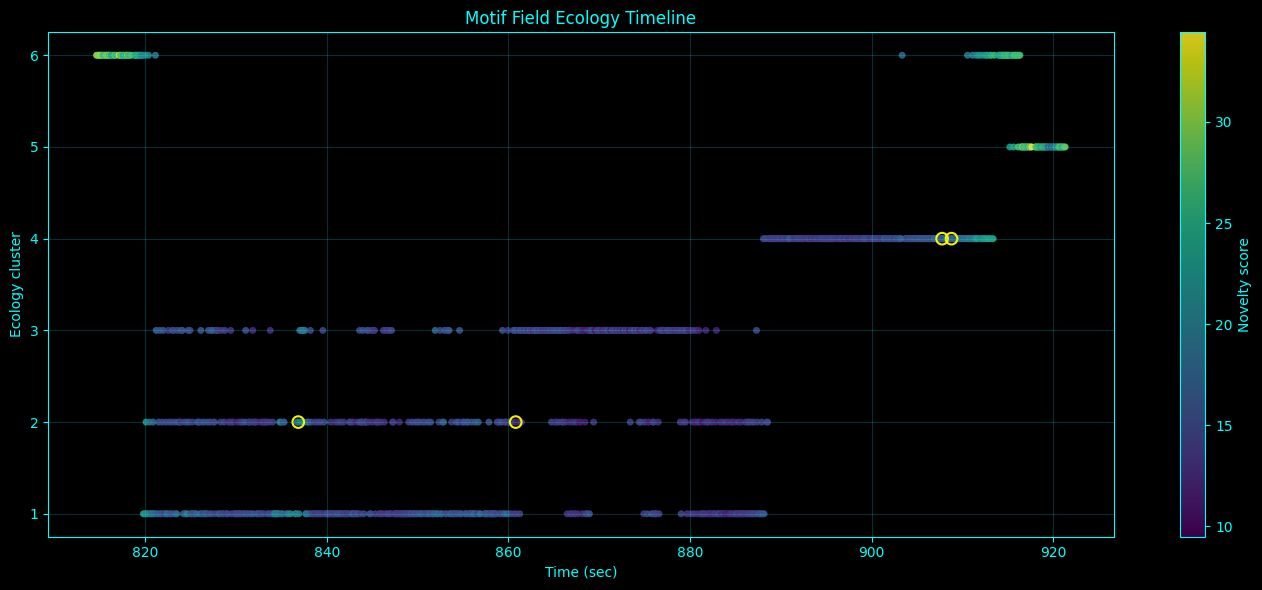

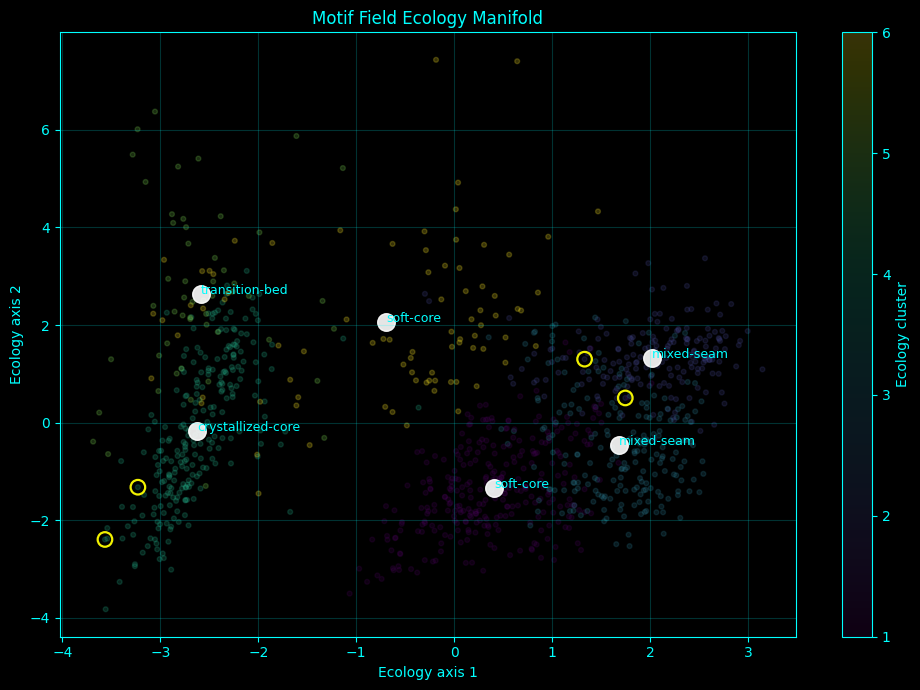

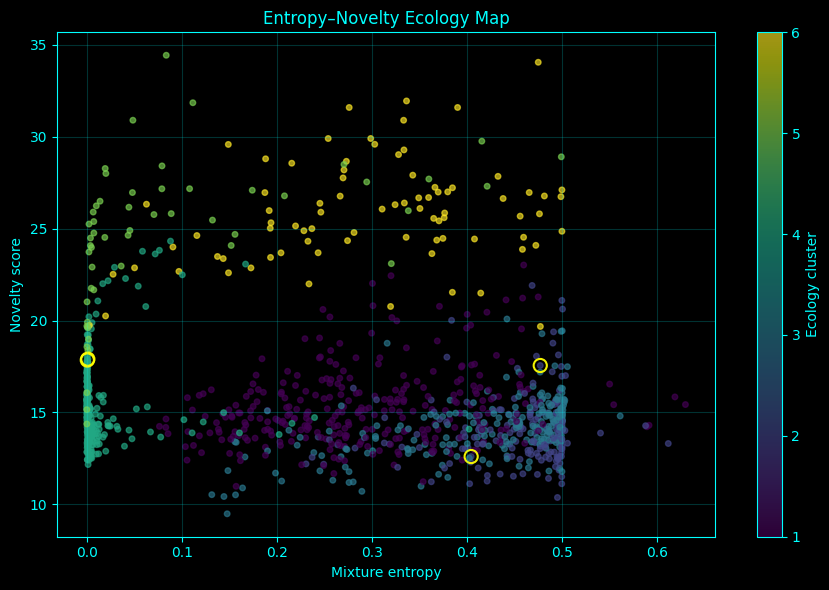

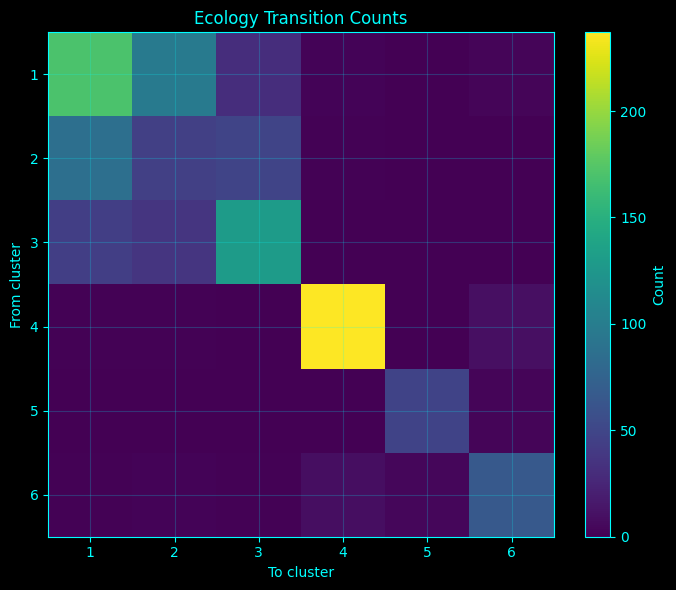

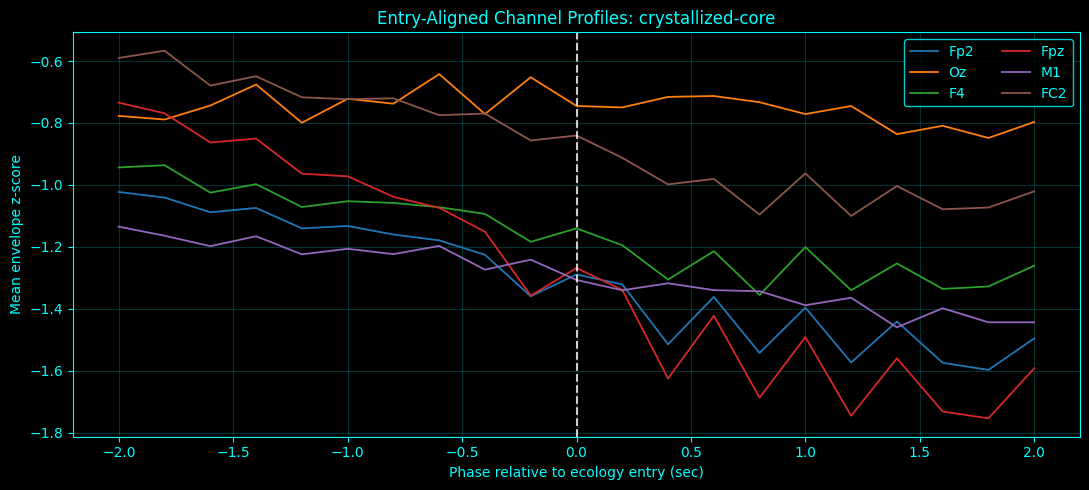

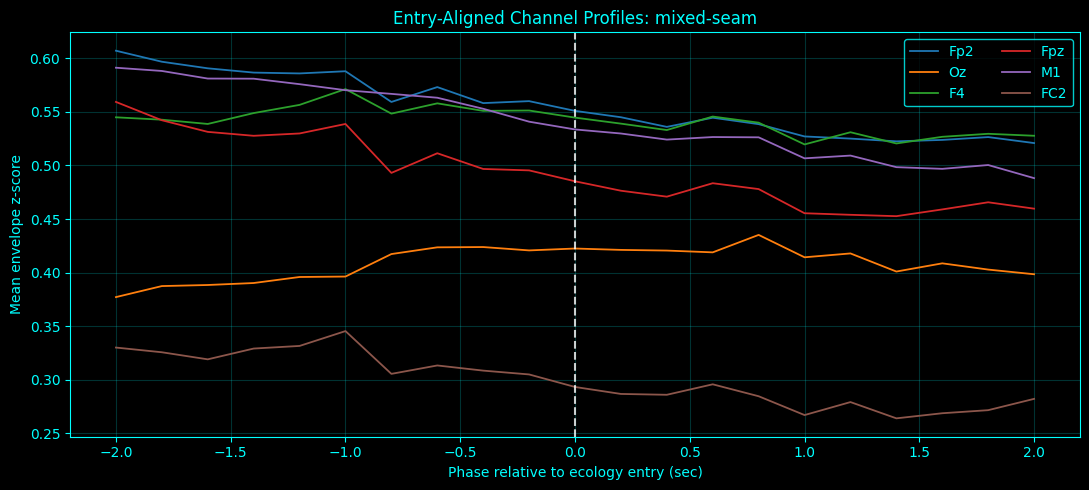

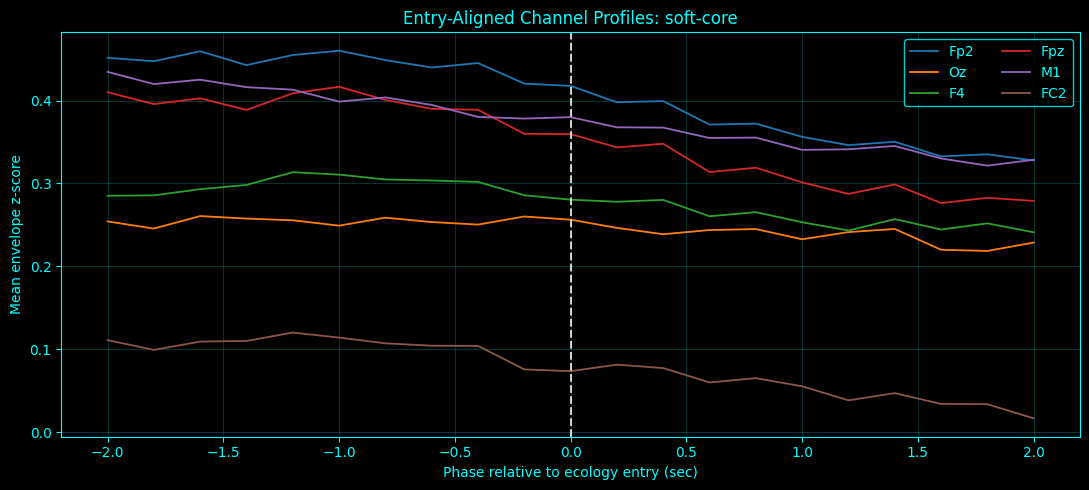

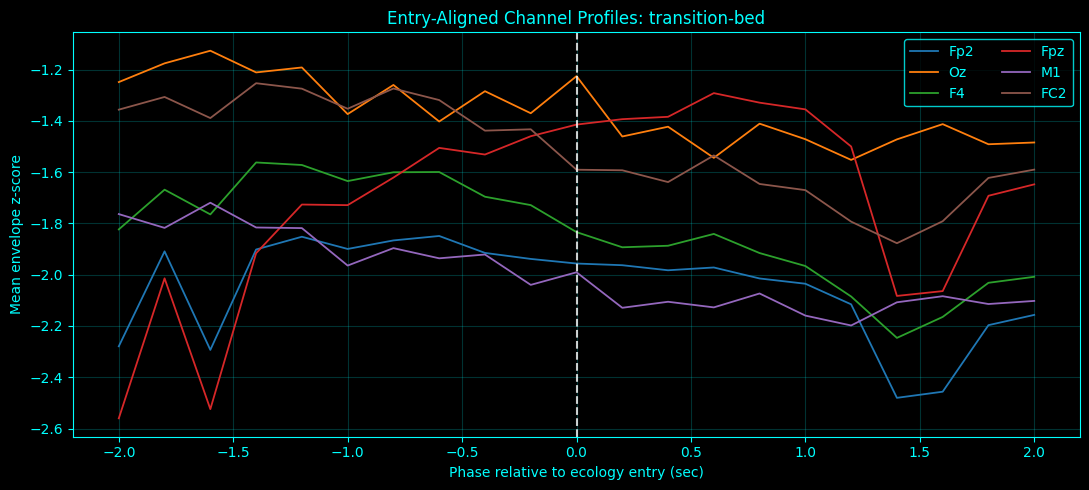


Saved:
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/motif_field_with_ecology_labels.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_cluster_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_segments.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/near_flat_ecology_context.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_entry_channel_profiles.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/ecology_transition_counts.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/motif_field_ecology_summary.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/motif_field_ecology_atlas_v1/plots

Ecology cluster summary:
 ecology_cluster  count  dominant_motif_mode  novelty_score_

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

field_dir = os.path.join(base_dir, "results", "continuous_motif_field_v1")
geom_dir = os.path.join(base_dir, "results", "local_banach_curvature_bootstrap_v1")
temporal_dir = os.path.join(base_dir, "results", "stable_curvature_temporal_episodes_v1")

field_csv = os.path.join(field_dir, "continuous_motif_field.csv")
near_flat_field_csv = os.path.join(field_dir, "near_flat_soft_motif_context.csv")
all_local_csv = os.path.join(geom_dir, "local_chart_curvature_all_states.csv")
channel_contrast_csv = os.path.join(temporal_dir, "stable_vs_nonstable_channel_envelope_contrast.csv")

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "motif_field_ecology_atlas_v1")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# ecology discovery controls
n_ecology_states = 6
entry_window_sec = 2.0
entry_bin_sec = 0.20
top_k_channels = 6
env_smooth_sec = 0.150

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for tick_label in cbar.ax.get_yticklabels():
        tick_label.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    w = max(int(w), 1)
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(x, kernel, mode="same")

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x, ddof=1)) if len(x) > 1 else np.nan

def zscore_cols(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    return (X - mu) / (sd + eps), mu, sd

def interp_profile(bin_centers, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) == 0:
        return np.full(len(bin_centers), np.nan)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if len(np.unique(x)) == 1:
        return np.full(len(bin_centers), y[0])

    return np.interp(bin_centers, x, y, left=y[0], right=y[-1])

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def contiguous_segments(times, labels, gap_sec=0.5):
    times = np.asarray(times, dtype=float)
    labels = np.asarray(labels)
    if len(times) == 0:
        return []

    segments = []
    start_i = 0

    for i in range(1, len(times)):
        broken = (labels[i] != labels[i - 1]) or ((times[i] - times[i - 1]) > gap_sec)
        if broken:
            segments.append((start_i, i - 1))
            start_i = i

    segments.append((start_i, len(times) - 1))
    return segments

# -------------------------------------------------------
# heuristic naming layer on top of unsupervised clusters
# -------------------------------------------------------
def ecology_name(row, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75):
    novelty = row["novelty_score_mean"]
    entropy = row["mixture_entropy_mean"]
    margin = row["dominance_margin_mean"]

    if novelty >= novelty_q90 and entropy < entropy_q75 and margin >= margin_q75:
        return "novel-island"
    if entropy >= entropy_q75 and margin <= margin_q25:
        return "mixed-seam"
    if novelty >= novelty_q75 and entropy >= entropy_q75:
        return "rupture-front"
    if entropy < entropy_q75 and margin >= margin_q75 and novelty < novelty_q75:
        return "crystallized-core"
    if entropy < entropy_q75 and margin < margin_q75:
        return "soft-core"
    return "transition-bed"

novelty_q75 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.75)
novelty_q90 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.90)
entropy_q75 = np.quantile(cluster_summary_df["mixture_entropy_mean"], 0.75)
margin_q25 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.25)
margin_q75 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.75)

cluster_summary_df["ecology_name"] = cluster_summary_df.apply(
    lambda r: ecology_name(r, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75),
    axis=1
)

cluster_to_name = dict(zip(cluster_summary_df["ecology_cluster"], cluster_summary_df["ecology_name"]))
field_df["ecology_name"] = field_df["ecology_cluster"].map(cluster_to_name)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
field_df = pd.read_csv(field_csv).sort_values("center_time_sec").reset_index(drop=True)
all_local_df = pd.read_csv(all_local_csv).sort_values("time_sec").reset_index(drop=True)

if os.path.exists(near_flat_field_csv):
    near_flat_field_df = pd.read_csv(near_flat_field_csv)
else:
    near_flat_field_df = pd.DataFrame()

if os.path.exists(channel_contrast_csv):
    channel_contrast_df = pd.read_csv(channel_contrast_csv).sort_values(
        "cohen_d_stable_vs_nonstable", ascending=False
    ).reset_index(drop=True)
    top_channels = channel_contrast_df["channel"].head(top_k_channels).tolist()
else:
    top_channels = ["Fp2", "Oz", "F4", "Fpz", "M1", "FC2"]

top_channel_idx = [eeg_channel_names.index(ch) for ch in top_channels]

# geometry fields
all_local_df["abs_laplacian_norm_proxy"] = np.abs(all_local_df["laplacian_norm_proxy"].values)

# nearest-time merge from local geometry into field windows
geom_merge_cols = [
    "time_sec",
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
]
geom_df = all_local_df[geom_merge_cols].copy().sort_values("time_sec").reset_index(drop=True)

field_df = pd.merge_asof(
    field_df.sort_values("center_time_sec"),
    geom_df,
    left_on="center_time_sec",
    right_on="time_sec",
    direction="nearest"
).drop(columns=["time_sec"])

# -------------------------------------------------------
# ECOLOGY FEATURE MATRIX
# -------------------------------------------------------
motif_activation_cols = [c for c in field_df.columns if c.endswith("_activation")]
feature_cols = [
    "novelty_score",
    "mixture_entropy",
    "dominance_margin",
    "frobenius_norm_proxy",
    "abs_laplacian_norm_proxy",
    "transition_distortion_B",
    "reduced_logvol_per_rank_B",
    "mean_banach_neighbor_radius",
    "fit_r2",
] + motif_activation_cols

X = field_df[feature_cols].values
Xz, mu, sd = zscore_cols(X)

# unsupervised ecology discovery
Z = linkage(Xz, method="ward")
cluster_ids = fcluster(Z, t=n_ecology_states, criterion="maxclust")
field_df["ecology_cluster"] = cluster_ids

# summarize clusters
cluster_rows = []
for cid in sorted(field_df["ecology_cluster"].unique()):
    sub = field_df[field_df["ecology_cluster"] == cid]
    dominant_motif_mode = int(sub["dominant_motif"].mode().iloc[0])

    cluster_rows.append({
        "ecology_cluster": int(cid),
        "count": int(len(sub)),
        "dominant_motif_mode": dominant_motif_mode,
        "novelty_score_mean": safe_mean(sub["novelty_score"].values),
        "mixture_entropy_mean": safe_mean(sub["mixture_entropy"].values),
        "dominance_margin_mean": safe_mean(sub["dominance_margin"].values),
        "frobenius_norm_proxy_mean": safe_mean(sub["frobenius_norm_proxy"].values),
        "abs_laplacian_norm_proxy_mean": safe_mean(sub["abs_laplacian_norm_proxy"].values),
        "transition_distortion_B_mean": safe_mean(sub["transition_distortion_B"].values),
        "reduced_logvol_per_rank_B_mean": safe_mean(sub["reduced_logvol_per_rank_B"].values),
        "mean_banach_neighbor_radius_mean": safe_mean(sub["mean_banach_neighbor_radius"].values),
        "fit_r2_mean": safe_mean(sub["fit_r2"].values),
    })

cluster_summary_df = pd.DataFrame(cluster_rows).sort_values("ecology_cluster").reset_index(drop=True)

# heuristic naming layer on top of unsupervised clusters
novelty_q75 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.75)
novelty_q90 = np.quantile(cluster_summary_df["novelty_score_mean"], 0.90)
entropy_q75 = np.quantile(cluster_summary_df["mixture_entropy_mean"], 0.75)
margin_q25 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.25)
margin_q75 = np.quantile(cluster_summary_df["dominance_margin_mean"], 0.75)

cluster_summary_df["ecology_name"] = cluster_summary_df.apply(
    lambda r: ecology_name(r, novelty_q75, novelty_q90, entropy_q75, margin_q25, margin_q75),
    axis=1
)

cluster_to_name = dict(zip(cluster_summary_df["ecology_cluster"], cluster_summary_df["ecology_name"]))
field_df["ecology_name"] = field_df["ecology_cluster"].map(cluster_to_name)

# -------------------------------------------------------
# CONTIGUOUS ECOLOGY SEGMENTS
# -------------------------------------------------------
segments = contiguous_segments(
    field_df["center_time_sec"].values,
    field_df["ecology_cluster"].values,
    gap_sec=0.5
)

segment_rows = []
for seg_id, (i0, i1) in enumerate(segments, start=1):
    sub = field_df.iloc[i0:i1 + 1]
    segment_rows.append({
        "segment_id": seg_id,
        "start_time_sec": float(sub["center_time_sec"].iloc[0]),
        "end_time_sec": float(sub["center_time_sec"].iloc[-1]),
        "duration_sec": float(sub["center_time_sec"].iloc[-1] - sub["center_time_sec"].iloc[0]),
        "n_windows": int(len(sub)),
        "ecology_cluster": int(sub["ecology_cluster"].mode().iloc[0]),
        "ecology_name": sub["ecology_name"].mode().iloc[0],
        "dominant_motif_mode": int(sub["dominant_motif"].mode().iloc[0]),
        "novelty_mean": safe_mean(sub["novelty_score"].values),
        "entropy_mean": safe_mean(sub["mixture_entropy"].values),
        "margin_mean": safe_mean(sub["dominance_margin"].values),
    })

segment_df = pd.DataFrame(segment_rows).sort_values("start_time_sec").reset_index(drop=True)

# -------------------------------------------------------
# NEAR-FLAT ECOLOGY CONTEXT
# -------------------------------------------------------
near_flat_ecology_rows = []

if len(near_flat_field_df) > 0:
    for _, row in near_flat_field_df.iterrows():
        t = float(row["time_sec"])
        idx = int(np.argmin(np.abs(field_df["center_time_sec"].values - t)))
        fr = field_df.iloc[idx]

        near_flat_ecology_rows.append({
            "time_sec": t,
            "nearest_field_time_sec": float(fr["center_time_sec"]),
            "ecology_cluster": int(fr["ecology_cluster"]),
            "ecology_name": fr["ecology_name"],
            "dominant_motif": int(fr["dominant_motif"]),
            "novelty_score": float(fr["novelty_score"]),
            "mixture_entropy": float(fr["mixture_entropy"]),
            "dominance_margin": float(fr["dominance_margin"]),
            "motif_1_activation": float(fr.get("motif_1_activation", np.nan)),
            "motif_2_activation": float(fr.get("motif_2_activation", np.nan)),
            "motif_3_activation": float(fr.get("motif_3_activation", np.nan)),
            "motif_4_activation": float(fr.get("motif_4_activation", np.nan)),
        })

near_flat_ecology_df = pd.DataFrame(near_flat_ecology_rows)

# -------------------------------------------------------
# EEG ENTRY PROFILES BY ECOLOGY TYPE
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]
analytic = hilbert(EEG_segment, axis=0)
envelope = np.abs(analytic)
env_z = (envelope - np.mean(envelope, axis=0, keepdims=True)) / (np.std(envelope, axis=0, keepdims=True) + eps)

smooth_w = int(env_smooth_sec * sampling_rate)
env_z_smooth = np.column_stack([
    moving_average(env_z[:, ch], smooth_w) for ch in range(env_z.shape[1])
])

sample_time = start_time + np.arange(len(EEG_segment)) * dt
entry_bins = np.arange(-entry_window_sec, entry_window_sec + entry_bin_sec, entry_bin_sec)

entry_rows = []

for eco_name in sorted(field_df["ecology_name"].unique()):
    eco_seg = segment_df[segment_df["ecology_name"] == eco_name]
    if len(eco_seg) == 0:
        continue

    for ch_idx, ch_name in zip(top_channel_idx, top_channels):
        aligned_profiles = []

        for _, seg in eco_seg.iterrows():
            t0 = float(seg["start_time_sec"])
            mask = (sample_time >= t0 - entry_window_sec) & (sample_time <= t0 + entry_window_sec)
            if not np.any(mask):
                continue

            phase = sample_time[mask] - t0
            prof = interp_profile(entry_bins, phase, env_z_smooth[mask, ch_idx])
            aligned_profiles.append(prof)

        if len(aligned_profiles) == 0:
            continue

        aligned_profiles = np.vstack(aligned_profiles)
        mean_prof = np.nanmean(aligned_profiles, axis=0)

        for p, v in zip(entry_bins, mean_prof):
            entry_rows.append({
                "ecology_name": eco_name,
                "channel": ch_name,
                "phase_sec": float(p),
                "mean_env_z": float(v),
            })

entry_profile_df = pd.DataFrame(entry_rows)

# -------------------------------------------------------
# ECOLOGY MANIFOLD EMBEDDING
# -------------------------------------------------------
Y, eigs, _ = pca_2d(Xz)
field_df["eco_x"] = Y[:, 0]
field_df["eco_y"] = Y[:, 1]

cluster_centers = []
for cid in sorted(field_df["ecology_cluster"].unique()):
    sub = field_df[field_df["ecology_cluster"] == cid]
    cluster_centers.append({
        "ecology_cluster": int(cid),
        "ecology_name": sub["ecology_name"].iloc[0],
        "eco_x": float(np.mean(sub["eco_x"])),
        "eco_y": float(np.mean(sub["eco_y"])),
    })
cluster_center_df = pd.DataFrame(cluster_centers)

# -------------------------------------------------------
# TRANSITION COUNTS BETWEEN ECOLOGY STATES
# -------------------------------------------------------
transition_rows = []
for i in range(len(field_df) - 1):
    a = field_df["ecology_cluster"].iloc[i]
    b = field_df["ecology_cluster"].iloc[i + 1]
    transition_rows.append({"from_cluster": int(a), "to_cluster": int(b)})

transition_df = pd.DataFrame(transition_rows)
if len(transition_df) > 0:
    transition_count_df = transition_df.value_counts().reset_index(name="count")
else:
    transition_count_df = pd.DataFrame(columns=["from_cluster", "to_cluster", "count"])

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
field_out_csv = os.path.join(out_dir, "motif_field_with_ecology_labels.csv")
cluster_csv = os.path.join(out_dir, "ecology_cluster_summary.csv")
segment_csv = os.path.join(out_dir, "ecology_segments.csv")
near_flat_csv = os.path.join(out_dir, "near_flat_ecology_context.csv")
entry_csv = os.path.join(out_dir, "ecology_entry_channel_profiles.csv")
transition_csv = os.path.join(out_dir, "ecology_transition_counts.csv")
summary_txt = os.path.join(out_dir, "motif_field_ecology_summary.txt")

field_df.to_csv(field_out_csv, index=False)
cluster_summary_df.to_csv(cluster_csv, index=False)
segment_df.to_csv(segment_csv, index=False)
near_flat_ecology_df.to_csv(near_flat_csv, index=False)
entry_profile_df.to_csv(entry_csv, index=False)
transition_count_df.to_csv(transition_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Motif Field Ecology Atlas Summary\n")
    f.write("================================\n\n")
    f.write(f"n_ecology_states = {n_ecology_states}\n")
    f.write(f"Top channels = {top_channels}\n\n")

    f.write("Ecology cluster summary:\n")
    f.write(cluster_summary_df.to_string(index=False))
    f.write("\n\n")

    f.write("Top 20 longest ecology segments:\n")
    f.write(segment_df.sort_values('duration_sec', ascending=False).head(20).to_string(index=False))
    f.write("\n\n")

    if len(near_flat_ecology_df) > 0:
        f.write("Near-flat ecology context:\n")
        f.write(near_flat_ecology_df.to_string(index=False))
        f.write("\n")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Ecology timeline
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["center_time_sec"].values,
    field_df["ecology_cluster"].values,
    c=field_df["novelty_score"].values,
    s=16,
    alpha=0.85
)
ax.set_title("Motif Field Ecology Timeline")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Ecology cluster")

if len(near_flat_ecology_df) > 0:
    ax.scatter(
        near_flat_ecology_df["time_sec"].values,
        near_flat_ecology_df["ecology_cluster"].values,
        s=70,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Novelty score")

plot1_path = os.path.join(plots_dir, "ecology_timeline.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Ecology manifold
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["eco_x"].values,
    field_df["eco_y"].values,
    c=field_df["ecology_cluster"].values,
    s=12,
    alpha=0.22
)

for _, row in cluster_center_df.iterrows():
    ax.scatter(row["eco_x"], row["eco_y"], s=160, color="white", alpha=0.9)
    ax.text(row["eco_x"], row["eco_y"], row["ecology_name"], fontsize=9)

if len(near_flat_ecology_df) > 0:
    nf_merge = pd.merge_asof(
        near_flat_ecology_df.sort_values("nearest_field_time_sec"),
        field_df[["center_time_sec", "eco_x", "eco_y"]].sort_values("center_time_sec"),
        left_on="nearest_field_time_sec",
        right_on="center_time_sec",
        direction="nearest"
    )
    ax.scatter(
        nf_merge["eco_x"].values,
        nf_merge["eco_y"].values,
        s=110,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.6,
        alpha=0.95
    )

ax.set_title("Motif Field Ecology Manifold")
ax.set_xlabel("Ecology axis 1")
ax.set_ylabel("Ecology axis 2")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Ecology cluster")

plot2_path = os.path.join(plots_dir, "ecology_manifold.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Entropy vs novelty colored by ecology
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    field_df["mixture_entropy"].values,
    field_df["novelty_score"].values,
    c=field_df["ecology_cluster"].values,
    s=16,
    alpha=0.65
)

if len(near_flat_ecology_df) > 0:
    ax.scatter(
        near_flat_ecology_df["mixture_entropy"].values,
        near_flat_ecology_df["novelty_score"].values,
        s=90,
        facecolors="none",
        edgecolors="yellow",
        linewidths=1.5,
        alpha=0.95
    )

ax.set_title("Entropy–Novelty Ecology Map")
ax.set_xlabel("Mixture entropy")
ax.set_ylabel("Novelty score")

cbar = plt.colorbar(sc, ax=ax)
style_cbar(cbar, "Ecology cluster")

plot3_path = os.path.join(plots_dir, "entropy_novelty_ecology_map.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Ecology transition heatmap
clusters = sorted(field_df["ecology_cluster"].unique())
cluster_to_idx = {c: i for i, c in enumerate(clusters)}
T = np.zeros((len(clusters), len(clusters)), dtype=float)
for _, row in transition_count_df.iterrows():
    T[cluster_to_idx[int(row["from_cluster"])], cluster_to_idx[int(row["to_cluster"])]] = row["count"]

fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(T, aspect="auto")
ax.set_xticks(np.arange(len(clusters)))
ax.set_yticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters)
ax.set_yticklabels(clusters)
ax.set_title("Ecology Transition Counts")
ax.set_xlabel("To cluster")
ax.set_ylabel("From cluster")

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Count")

plot4_path = os.path.join(plots_dir, "ecology_transition_counts.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Entry channel profiles by ecology
for eco_name in sorted(entry_profile_df["ecology_name"].unique()):
    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    sub_all = entry_profile_df[entry_profile_df["ecology_name"] == eco_name]
    for ch_name in top_channels:
        sub = sub_all[sub_all["channel"] == ch_name]
        if len(sub) == 0:
            continue
        ax.plot(
            sub["phase_sec"].values,
            sub["mean_env_z"].values,
            linewidth=1.3,
            label=ch_name
        )

    ax.axvline(0.0, color="white", linestyle="--", alpha=0.8)
    ax.set_title(f"Entry-Aligned Channel Profiles: {eco_name}")
    ax.set_xlabel("Phase relative to ecology entry (sec)")
    ax.set_ylabel("Mean envelope z-score")
    ax.legend(ncol=2)

    plot_path = os.path.join(plots_dir, f"entry_profiles_{eco_name}.png")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

print("\nSaved:")
print(field_out_csv)
print(cluster_csv)
print(segment_csv)
print(near_flat_csv)
print(entry_csv)
print(transition_csv)
print(summary_txt)
print(plots_dir)

print("\nEcology cluster summary:")
print(cluster_summary_df.to_string(index=False))

print("\nTop 15 longest ecology segments:")
print(segment_df.sort_values("duration_sec", ascending=False).head(15).to_string(index=False))

if len(near_flat_ecology_df) > 0:
    print("\nNear-flat ecology context:")
    print(near_flat_ecology_df.to_string(index=False))